# <span style=' color:red'>FINAL YEAR PROJECT TRIAL 3</span>

## <span style=' color:orange'>Importing all Packages</span>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random 

In [4]:
# Global seeds
np.random.seed(42)
random.seed(42) 


#This establishes a baseline for reproducibility. 
#However, it's crucial to also continue using random_state within specific functions and classes (like train_test_split and your model initializations) even after setting the global seeds."



In [5]:
import sklearn
sklearn.__version__

'1.5.1'

## <span style=' color:orange'>Reading and Exploring the DataFrame</span>

In [7]:
orginal_df=pd.read_csv('stroke_dataset.csv')
df=orginal_df.copy() 

In [8]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [9]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [10]:
df.tail(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5100,68398,Male,82.0,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0
5101,36901,Female,45.0,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
5102,45010,Female,57.0,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0
5103,22127,Female,18.0,0,0,No,Private,Urban,82.85,46.9,Unknown,0
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [11]:
df.info() #Initial data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [12]:
df.shape

(5110, 12)

In [13]:
df.size

61320

In [14]:
df.describe()

#Standard deviation measures how spread out the values are from the mean. 
#A low std means most values are close to the mean; a high std means more variability.

#70 mg/dL- 100mg/dL :normal fasting blood glucose concentration 
#Up to 140 mg/dL 2 hours after eating.

#18.5 - 24.9 –  healthy range
#25 - 29.9 –  overweight
#30 -39.9 –  obesity.

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


LIMITATION -GLUCOSE LEVEL

✅ 1. Acknowledge the Ambiguity Clearly
Mention in your methodology or data limitations section that the dataset doesn’t clarify whether the glucose values are fasting or postprandial. For example:

"The dataset utilized for this study provides average glucose levels for each patient; however, it does not specify whether these measurements were taken under fasting conditions or postprandial (after eating). This introduces an inherent limitation in interpreting the precise clinical significance of this feature."

✅ 2. Explain the Implication
Glucose levels vary significantly depending on timing, so include a note about how that uncertainty might affect predictions:

"Fasting and postprandial glucose levels differ in their diagnostic value for conditions like diabetes and stroke risk. The inability to distinguish between these measurements may introduce variability in the predictive power of the glucose feature."

✅ 3. Support Your Decision with Reasoning
You can justify that your model still offers value regardless of the type — especially if you treat avg_glucose_level as a biomarker indicating abnormal glucose metabolism.

"Despite the limitation, elevated glucose levels—regardless of measurement context—can still reflect underlying metabolic risks, which are relevant in stroke prediction. Therefore, the model remains useful in flagging potential high-risk individuals."

✅ 4. Optional: Suggest Future Work
A strong move is to suggest that future studies collect explicit glucose timing data:

"Future studies should consider distinguishing fasting and postprandial glucose measurements to further refine the model's predictive accuracy and clinical applicability."

In [16]:
df.duplicated().any()

False

In [17]:
df.isnull().sum()  #Only the bmi has null values

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

## <span style=' color:orange'>Data Preprocessing</span>

 #### <span style=' color:gold'>Boxplot & IQR Method (Interquartile Range)</span>


In [20]:
continuous_features = ['age', 'avg_glucose_level','bmi']

In [21]:
continuous_features

['age', 'avg_glucose_level', 'bmi']

In [22]:
df[continuous_features]

,age,avg_glucose_level,bmi
0,67.0,228.69,36.6
1,61.0,202.21,NaN
2,80.0,105.92,32.5
3,49.0,171.23,34.4
4,79.0,174.12,24.0
...,...,...,...
5105,80.0,83.75,NaN
5106,81.0,125.20,40.0
5107,35.0,82.99,30.6
5108,51.0,166.29,25.6


In [23]:
Q1 = df[continuous_features].quantile(0.25)  # First quartile (25th percentile)
Q3 = df[continuous_features].quantile(0.75)  # Third quartile (75th percentile)
IQR = Q3 - Q1  # Interquartile Range

In [24]:
# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [25]:
# Find outliers
outliers = ((df[continuous_features] < lower_bound) | (df[continuous_features] > upper_bound)).any(axis=0)

outliers  

# avg_glucose_level and bmi columns have outliers

age                  False
avg_glucose_level     True
bmi                   True
dtype: bool

In [26]:
outliers = ((df[continuous_features] < lower_bound) | (df[continuous_features] > upper_bound)).any(axis=1)


outliers

#709 rows have at least one outlier

0        True
1        True
2       False
3        True
4        True
        ...  
5105    False
5106    False
5107    False
5108    False
5109    False
Length: 5110, dtype: bool

In [27]:
outliers=df[outliers]
outliers

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5061,38009,Male,41.0,0,0,Yes,Private,Urban,223.78,32.3,never smoked,0
5062,11184,Female,82.0,0,0,Yes,Self-employed,Rural,211.58,36.9,never smoked,0
5063,68967,Male,39.0,0,0,Yes,Private,Urban,179.38,27.7,Unknown,0
5064,66684,Male,70.0,0,0,Yes,Self-employed,Rural,193.88,24.3,Unknown,0


In [28]:
# For each continuous feature, count how many outliers are present

for feature in continuous_features:
    outlier_count = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    print(f"Number of outliers in {feature}: {outlier_count}")


Number of outliers in age: 0
Number of outliers in avg_glucose_level: 627
Number of outliers in bmi: 110


In [29]:
outliers_in_glucose_bmi = ((df['avg_glucose_level'] < lower_bound['avg_glucose_level']) | 
                           (df['avg_glucose_level'] > upper_bound['avg_glucose_level'])) & \
                          ((df['bmi'] < lower_bound['bmi']) | 
                           (df['bmi'] > upper_bound['bmi']))

outliers_in_glucose_bmi_rows = df[outliers_in_glucose_bmi]
print(f"Number of rows with outliers in both avg_glucose_level and bmi: {outliers_in_glucose_bmi_rows.shape[0]}")


Number of rows with outliers in both avg_glucose_level and bmi: 28


In [30]:
# Correct filtering of rows where ALL continuous features are within the bounds
df_filtered = df[
    ((df[continuous_features] >= lower_bound) & (df[continuous_features] <= upper_bound)).all(axis=1)
]

print(f"Original Data: {df.shape[0]} rows")
print(f"Filtered Data (no outliers in any column): {df_filtered.shape[0]} rows")


Original Data: 5110 rows
Filtered Data (no outliers in any column): 4261 rows


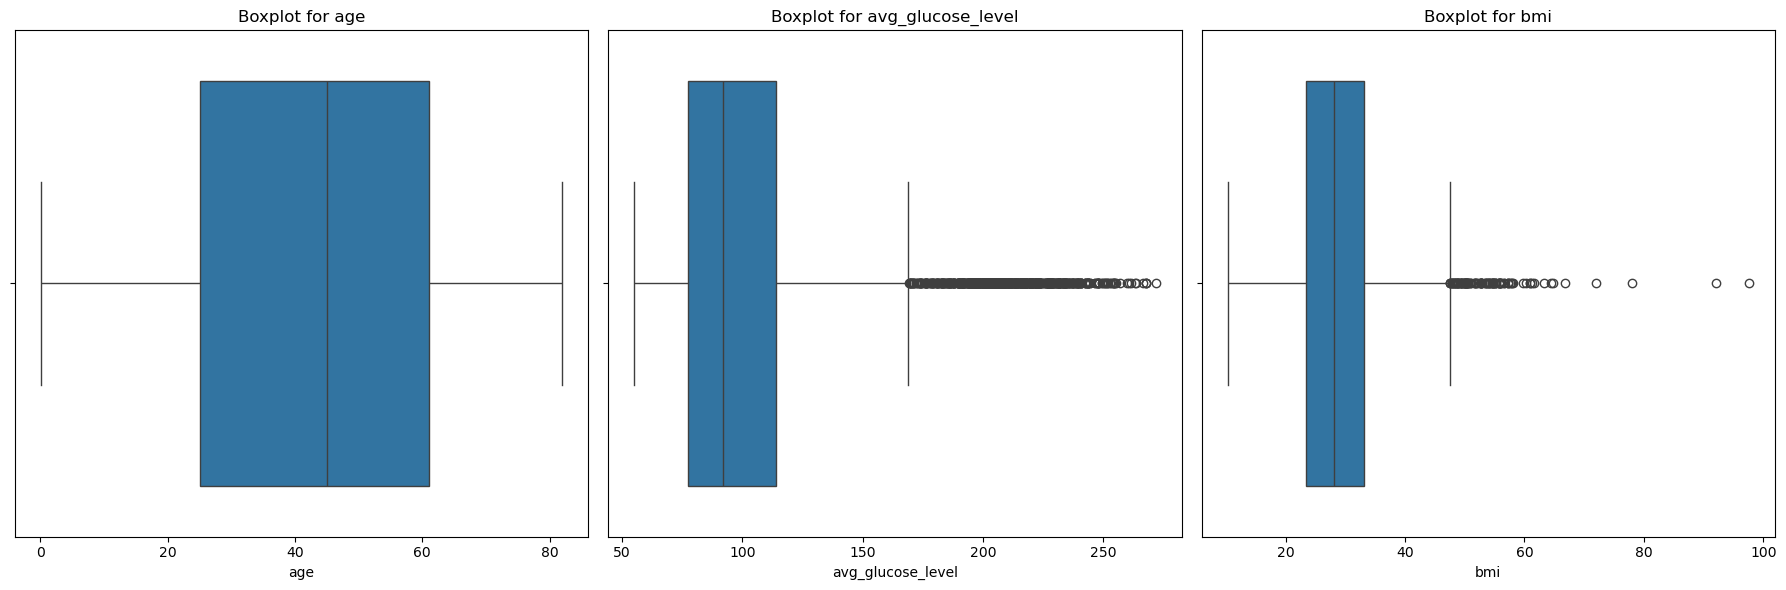

In [31]:
import seaborn as sns


# Create a boxplot for each continuous feature
fig, axes = plt.subplots(1, len(continuous_features), figsize=(18, 6))

for i, feature in enumerate(continuous_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot for {feature}')
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.savefig("boxplots_all_features.svg")
plt.show()

### <span style = 'color:gold'> MultiVariate Analysis (Age,bmi and glucose levels) </span>

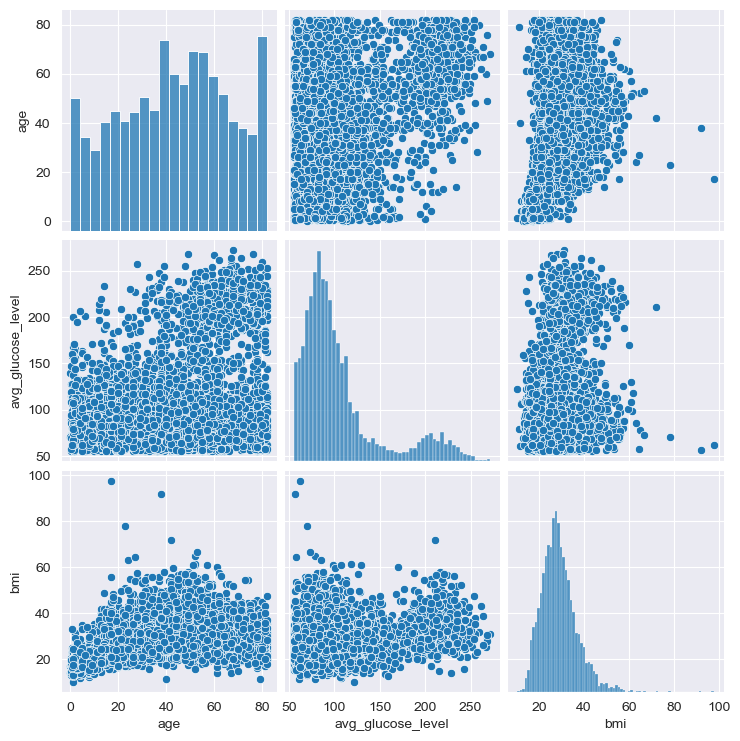

In [33]:
# Pairplot for continuous features
sns.set_style('darkgrid')
sns.pairplot(df[continuous_features])
plt.savefig("pairplot.svg")

plt.show()


#shows that the features are not really lineraly related
#Age vs. glucose level: Shows a slight positive correlation, with glucose levels becoming more variable with increasing age
#Age vs. BMI: Shows a weak relationship with BMI values mostly concentrated between 20-40 across all ages
#Glucose level vs. BMI: Shows no strong correlation, with points spread fairly evenly



Age distribution: The histogram shows ages mostly between 20-80 years, with a concentration in middle to older age groups. There don't appear to be any extreme outliers in age, though there are relatively few very young or very old individuals in the dataset.

Average glucose level:

The distribution shows a bimodal pattern with a main peak around 80-100 mg/dL (normal range) and a smaller secondary peak around 200-225 mg/dL (diabetic range)
In the scatter plots, you can see a few potential outliers with glucose values above 250 mg/dL
These extreme values are sparse but appear legitimate as they follow the overall pattern of the data


BMI (Body Mass Index):

The main distribution ranges from about 15-40, which covers underweight to severely obese classifications
There appear to be a few potential outliers with BMI values around 60-100, which are visible in the scatter plots as points far from the main cluster
These extremely high BMI values are quite rare in the dataset


Relationships between variables:

The scatter plots show that the relationships between these variables generally follow expected patterns without many bivariate outliers
The age vs. glucose plot shows increasing variability with age, which is clinically expected
The distributions appear relatively clean with defined boundaries, suggesting significant outliers may have already been addressed



Since you mentioned you created this after checking for outliers, it appears you've likely already removed extreme values that didn't make clinical sense. The remaining extreme values (particularly in glucose and BMI) are likely legitimate data points representing real patients with unusual but possible measurements, rather than data entry errors or measurement issues.
For a stroke prediction model, these extreme but legitimate values could be important to retain, as they might represent high-risk individuals. The visualization suggests your data cleaning has preserved the natural variability in the population while likely removing truly problematic outliers.

### <span style=' color:gold'>Z-score Method (Standard Deviation)</span>


In [36]:
from scipy.stats import zscore

# Calculate z-scores for each continuous feature
z_scores = zscore(df[continuous_features])

# Add z-scores to the DataFrame with appropriate column names
df_z = df.copy()
df_z[[f'{col}_zscore' for col in continuous_features]] = z_scores

# Find rows where any of the z-scores is > 3 or < -3
outlier_mask = (df_z[[f'{col}_zscore' for col in continuous_features]].abs() > 3).any(axis=1)
outliers = df_z[outlier_mask]

print(f"Number of outlier rows: {outliers.shape[0]}")
print(outliers[['id'] + [f'{col}_zscore' for col in continuous_features]])


Number of outlier rows: 49
         id  age_zscore  avg_glucose_level_zscore  bmi_zscore
33    54401    1.626390                  3.237084         NaN
45    19824    1.449481                  3.035225         NaN
122   13491    1.626390                  3.389692         NaN
123   44033    0.564933                  3.161773         NaN
135   71279    1.228344                  3.471187         NaN
193   69112    1.095662                  3.657145         NaN
196   58267    1.184116                  3.011814         NaN
220   20463    1.670617                  3.196668         NaN
243   40460    1.095662                  3.122019         NaN
256   41413    1.405253                  3.034120         NaN
303   18518    1.007207                  3.006955         NaN
330   59368    1.537935                  3.033458         NaN
386   63732    1.184116                  3.212348         NaN
552   68275    0.388024                  3.125995         NaN
755   33585    0.918752                  3.

The NaN values in the bmi_zscore column suggest my dataset has missing BMI values. The Z-score calculation can't produce a score for missing values.

Which method is better for your model?
For stroke prediction:

The Z-score approach (49 outliers) is likely more appropriate as it preserves clinically relevant extreme values
The IQR method (709 outliers) may be removing too much legitimate data, particularly patients with diabetes or other conditions that naturally push values outside the "normal" range

Those "outliers" in glucose levels around 200+ mg/dL are actually meaningful data points that could strongly indicate diabetes, which is a key risk factor for stroke. Similarly, extreme age or BMI values could be important predictors.
For a medical model like stroke prediction, you generally want to be cautious about removing too many outliers that might represent the very high-risk patients your model needs to identify.

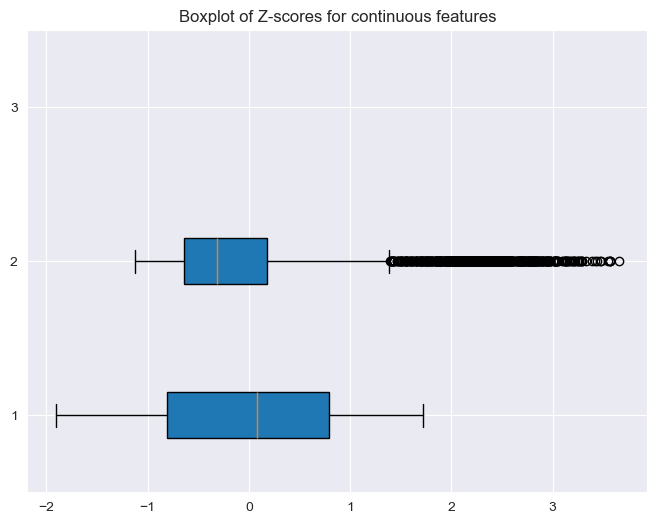

In [39]:

# Plot the z-scores
plt.figure(figsize=(8, 6))
plt.boxplot(z_scores, vert=False, patch_artist=True)
plt.title('Boxplot of Z-scores for continuous features')
plt.show()


### <span style=' color:gold'>Conversion to the appropriate datatypes</span>


In [41]:
df.select_dtypes(include='object')

,gender,ever_married,work_type,Residence_type,smoking_status
0,Male,Yes,Private,Urban,formerly smoked
1,Female,Yes,Self-employed,Rural,never smoked
2,Male,Yes,Private,Rural,never smoked
3,Female,Yes,Private,Urban,smokes
4,Female,Yes,Self-employed,Rural,never smoked
...,...,...,...,...,...
5105,Female,Yes,Private,Urban,never smoked
5106,Female,Yes,Self-employed,Urban,never smoked
5107,Female,Yes,Self-employed,Rural,never smoked
5108,Male,Yes,Private,Rural,formerly smoked


In [42]:
for col in df.select_dtypes(include='object').columns:
    df[col]= df[col].astype('category')

In [43]:
df.select_dtypes(include='object') #All objects have been converted to categories -why is this important?

""
0
1
2
3
4
...
5105
5106
5107
5108


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 5110 non-null   int64   
 1   gender             5110 non-null   category
 2   age                5110 non-null   float64 
 3   hypertension       5110 non-null   int64   
 4   heart_disease      5110 non-null   int64   
 5   ever_married       5110 non-null   category
 6   work_type          5110 non-null   category
 7   Residence_type     5110 non-null   category
 8   avg_glucose_level  5110 non-null   float64 
 9   bmi                4909 non-null   float64 
 10  smoking_status     5110 non-null   category
 11  stroke             5110 non-null   int64   
dtypes: category(5), float64(3), int64(4)
memory usage: 305.3 KB


In [45]:
df['gender'].dtype 

CategoricalDtype(categories=['Female', 'Male', 'Other'], ordered=False, categories_dtype=object)

In [46]:
df['age']=df['age'].astype('int64') #converting age to integer - it showed as a float

In [47]:
df['age'].dtype

dtype('int64')

In [48]:
df.info() #after conversions 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 5110 non-null   int64   
 1   gender             5110 non-null   category
 2   age                5110 non-null   int64   
 3   hypertension       5110 non-null   int64   
 4   heart_disease      5110 non-null   int64   
 5   ever_married       5110 non-null   category
 6   work_type          5110 non-null   category
 7   Residence_type     5110 non-null   category
 8   avg_glucose_level  5110 non-null   float64 
 9   bmi                4909 non-null   float64 
 10  smoking_status     5110 non-null   category
 11  stroke             5110 non-null   int64   
dtypes: category(5), float64(2), int64(5)
memory usage: 305.3 KB


In [49]:
(df['age'] < 1).sum() 

43

In [50]:
df[df['age']<1]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
363,7559,Female,0,0,0,No,children,Urban,83.82,24.9,Unknown,0
376,22706,Female,0,0,0,No,children,Rural,88.11,15.5,Unknown,0
564,61511,Female,0,0,0,No,children,Rural,73.71,16.2,Unknown,0
982,54747,Male,0,0,0,No,children,Rural,157.57,19.2,Unknown,0
996,53279,Male,0,0,0,No,children,Rural,118.87,16.3,Unknown,0
1093,66772,Female,0,0,0,No,children,Rural,55.86,16.0,Unknown,0
1206,68908,Female,0,0,0,No,children,Urban,66.36,23.0,Unknown,0
1317,30084,Male,0,0,0,No,children,Rural,98.67,17.5,Unknown,0
1600,40544,Male,0,0,0,No,children,Urban,109.56,14.3,Unknown,0
1614,47350,Female,0,0,0,No,children,Urban,139.67,14.1,Unknown,0


In [51]:
(df['age']<18).sum()

856

In [52]:
df[df['age']<18]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
162,69768,Female,1,0,0,No,children,Urban,70.37,NaN,Unknown,1
245,49669,Female,14,0,0,No,children,Rural,57.93,30.9,Unknown,1
249,30669,Male,3,0,0,No,children,Rural,95.12,18.0,Unknown,0
251,16523,Female,8,0,0,No,Private,Urban,110.89,17.6,Unknown,0
253,46136,Male,14,0,0,No,Never_worked,Rural,161.28,19.1,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...
5089,56714,Female,0,0,0,No,children,Rural,62.13,16.8,Unknown,0
5094,28048,Male,13,0,0,No,children,Urban,82.38,24.3,Unknown,0
5095,68598,Male,1,0,0,No,children,Rural,79.15,17.4,Unknown,0
5098,579,Male,9,0,0,No,children,Urban,71.88,17.5,Unknown,0


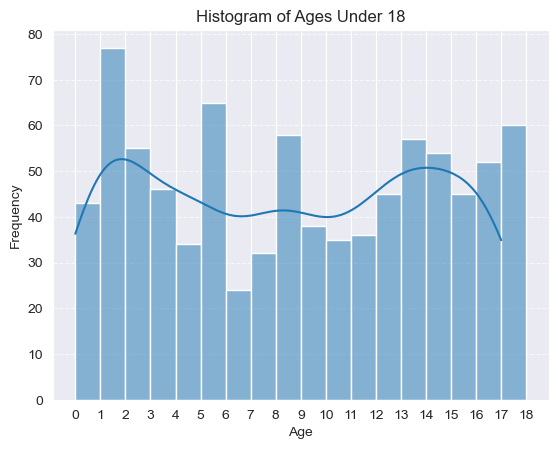

In [53]:
import seaborn as sns


# Filter the DataFrame
under_18 = df[df['age'] < 18]

# Plot the histogram
sns.histplot(under_18['age'], bins=range(0, 19), kde=True)

plt.title('Histogram of Ages Under 18')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.xticks(range(0, 19))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("hist-ages less than 18.svg")


plt.show()


In [54]:
df[df['age']<1].shape

(43, 12)

In [55]:
df = df[df['age'] >= 18]  # Keep only rows where age is 18 or above
df=df.reset_index(drop=True)

In [56]:
df['age'].describe()

count    4254.000000
mean       50.202163
std        17.829035
min        18.000000
25%        36.000000
50%        50.500000
75%        64.000000
max        82.000000
Name: age, dtype: float64

In [57]:
df['age'].dtype

dtype('int64')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4254 entries, 0 to 4253
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 4254 non-null   int64   
 1   gender             4254 non-null   category
 2   age                4254 non-null   int64   
 3   hypertension       4254 non-null   int64   
 4   heart_disease      4254 non-null   int64   
 5   ever_married       4254 non-null   category
 6   work_type          4254 non-null   category
 7   Residence_type     4254 non-null   category
 8   avg_glucose_level  4254 non-null   float64 
 9   bmi                4073 non-null   float64 
 10  smoking_status     4254 non-null   category
 11  stroke             4254 non-null   int64   
dtypes: category(5), float64(2), int64(5)
memory usage: 254.3 KB


In [59]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4249,18234,Female,80,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
4250,44873,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
4251,19723,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
4252,37544,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [60]:
df.size


51048

<span style=' color:gold'>Dropping irrelevant columns</span>

In [62]:
df=df.drop('id', axis=1)

In [63]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4249,Female,80,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
4250,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
4251,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
4252,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# <span style=' color:red'>UNIVARIATE ANALYSIS</span>

### <span style=' color:gold'>Gender</span>

In [66]:
df['gender'].describe

<bound method NDFrame.describe of 0         Male
1       Female
2         Male
3       Female
4       Female
         ...  
4249    Female
4250    Female
4251    Female
4252      Male
4253    Female
Name: gender, Length: 4254, dtype: category
Categories (3, object): ['Female', 'Male', 'Other']>

In [67]:
df['gender'].value_counts()

gender
Female    2576
Male      1677
Other        1
Name: count, dtype: int64

In [68]:
df['gender'].value_counts(normalize=True)

gender
Female    0.605548
Male      0.394217
Other     0.000235
Name: proportion, dtype: float64

In [69]:
gender_percentage =df['gender'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)
gender_percentage

gender
Female    60.55%
Male      39.42%
Other      0.02%
Name: proportion, dtype: object

#### <span style=' color:yellow'>Visualizing gender proportions</span>

In [71]:
gender_counts=df['gender'].value_counts()
gender_counts

gender
Female    2576
Male      1677
Other        1
Name: count, dtype: int64

In [72]:
df['gender'] =df['gender'].replace({'Other':np.nan})

C:\Users\USER\AppData\Local\Temp\ipykernel_14964\1779962374.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['gender'] =df['gender'].replace({'Other':np.nan})


In [73]:
df['gender'].isnull().sum()

1

In [74]:

df['gender']= df['gender'].fillna(df['gender'].mode()[0])

In [75]:
df['gender'].isnull().sum()

0

In [76]:
gender_counts2=df['gender'].value_counts()

In [77]:
gender_counts2

gender
Female    2577
Male      1677
Name: count, dtype: int64

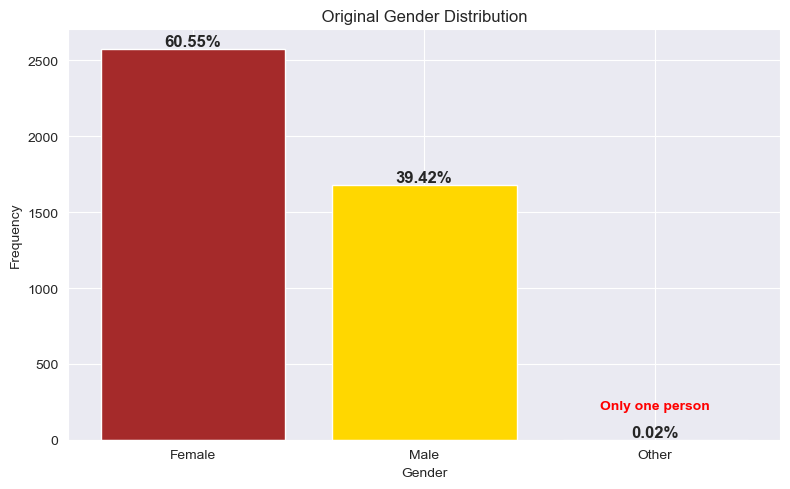

In [78]:


# Calculate total count and percentages
total_count = gender_counts.sum()
percentages = (gender_counts / total_count) * 100

colors=['brown','gold']

plt.figure(figsize=(8, 5))  

# Plot histogram with customized bar width
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors)


plt.title(' Original Gender Distribution ')
plt.xlabel('Gender')
plt.ylabel('Frequency')

# Add percentages as text on top of the bars

for i, bar in enumerate(bars):
    height = bar.get_height()  # Get height of each bar
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center text on the bar
        height + 20,  # Slightly above the top of the bar
        f"{percentages.iloc[i]:.2f}%",  
        ha='center', fontsize=12, fontweight='bold'
    )

# Add custom text for the "Other" bar

if 'Other' in gender_counts.index:
    idx = gender_counts.index.get_loc('Other')
    plt.text(bars[idx].get_x() + bars[idx].get_width() / 2,  # Center on the "Other" bar
             bars[idx].get_height() + 200,  # Place text higher up
             'Only one person', color='red', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()  
plt.show()  # Display the plot



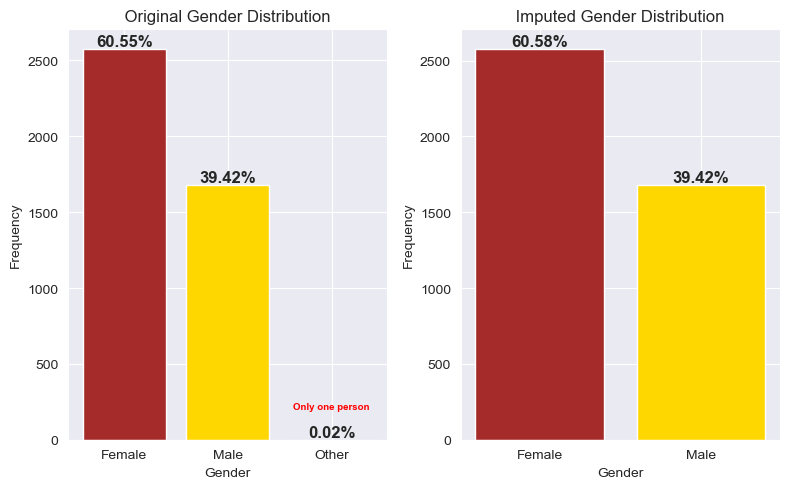

In [79]:
plt.figure(figsize=(8, 5))  


plt.subplot(1,2,1)

# Calculate total count and percentages
total_count = gender_counts.sum()
percentages = (gender_counts / total_count) * 100
colors=['brown','gold']



# Plot histogram with customized bar width
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors)


plt.title(' Original Gender Distribution ')
plt.xlabel('Gender')
plt.ylabel('Frequency')

# Add percentages as text on top of the bars

for i, bar in enumerate(bars):
    height = bar.get_height()  # Get height of each bar
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center text on the bar
        height + 20,  # Slightly above the top of the bar
        f"{percentages.iloc[i]:.2f}%",  
        ha='center', fontsize=12, fontweight='bold'
    )

# Add custom text for the "Other" bar

if 'Other' in gender_counts.index:
    idx = gender_counts.index.get_loc('Other')
    plt.text(bars[idx].get_x() + bars[idx].get_width() / 2,  # Center on the "Other" bar
             bars[idx].get_height() + 200,  # Place text higher up
             'Only one person', color='red', ha='center', fontsize=7, fontweight='bold')



plt.subplot(1,2,2)

# Calculate total count and percentages
total_count = gender_counts2.sum()
percentages = (gender_counts2 / total_count) * 100


# Plot histogram with customized bar width
bars = plt.bar(gender_counts2.index, gender_counts2.values, color= colors)


plt.title(' Imputed Gender Distribution ')
plt.xlabel('Gender')
plt.ylabel('Frequency')

# Add percentages as text on top of the bars

for i, bar in enumerate(bars):
    height = bar.get_height()  # Get height of each bar
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center text on the bar
        height + 20,  # Slightly above the top of the bar
        f"{percentages.iloc[i]:.2f}%",  
        ha='center', fontsize=12, fontweight='bold'
    )


plt.tight_layout()  

plt.savefig("Gender.svg")

plt.show()  

#### <span style=' color:yellow'>Age column</span>

In [81]:

df['age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: age
Non-Null Count  Dtype
--------------  -----
4254 non-null   int64
dtypes: int64(1)
memory usage: 33.4 KB


In [82]:
df['age'].describe()

count    4254.000000
mean       50.202163
std        17.829035
min        18.000000
25%        36.000000
50%        50.500000
75%        64.000000
max        82.000000
Name: age, dtype: float64

In [83]:
df['age'].value_counts() 

age
78    102
57     95
52     90
54     87
51     86
     ... 
22     45
70     45
72     45
77     42
74     40
Name: count, Length: 65, dtype: int64

In [84]:
df['age'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)

age
78    2.40%
57    2.23%
52    2.12%
54    2.05%
51    2.02%
      ...  
22    1.06%
70    1.06%
72    1.06%
77    0.99%
74    0.94%
Name: proportion, Length: 65, dtype: object

In [85]:
age_counts=df['age'].value_counts()
age_counts

age
78    102
57     95
52     90
54     87
51     86
     ... 
22     45
70     45
72     45
77     42
74     40
Name: count, Length: 65, dtype: int64

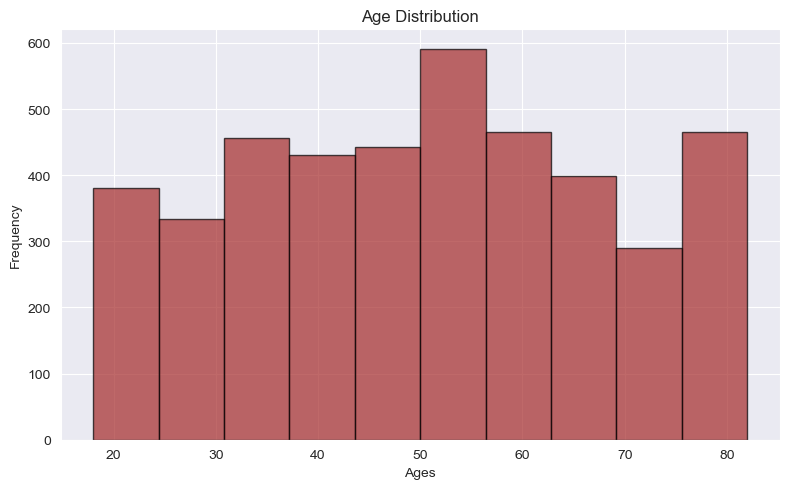

In [86]:
plt.figure(figsize=( 8,5))

plt.hist(df['age'], bins=10, color='brown', edgecolor='black', alpha=0.7)   #alpha sets opacity of the bars . 1- fully opaque, and 0-transparent
plt.title('Age Distribution')
plt.xlabel('Ages')
plt.ylabel('Frequency')

plt.tight_layout()

plt.show()


#### <span style=' color:yellow'>Hyptertension column</span>

In [88]:
df['hypertension'].describe()

count    4254.000000
mean        0.116831
std         0.321257
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: hypertension, dtype: float64

In [89]:
df['hypertension'].dtype

dtype('int64')

In [90]:
df['hypertension'].value_counts()

hypertension
0    3757
1     497
Name: count, dtype: int64

In [91]:
df['hypertension'].value_counts(normalize=True)

hypertension
0    0.883169
1    0.116831
Name: proportion, dtype: float64

In [92]:
hypertension_percentage=df['hypertension'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)
hypertension_percentage

hypertension
0    88.32%
1    11.68%
Name: proportion, dtype: object

In [93]:
hypertension_counts=df['hypertension'].value_counts()
hypertension_counts


hypertension
0    3757
1     497
Name: count, dtype: int64

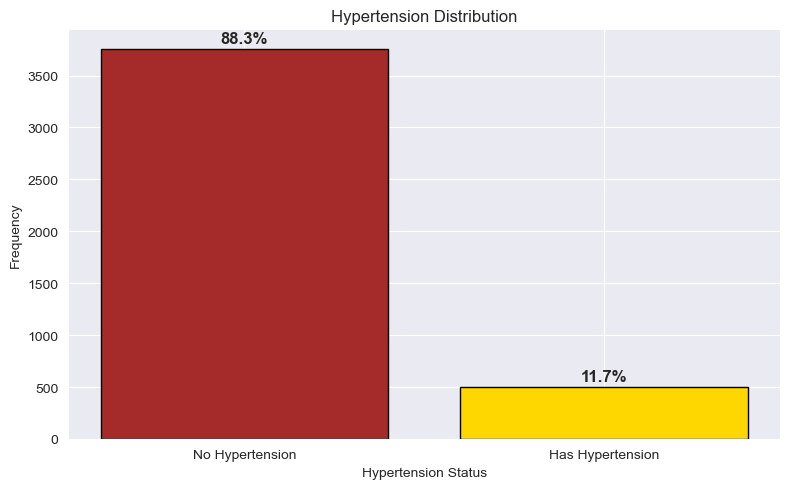

In [94]:
plt.figure(figsize=(8,5))

bars = plt.bar(hypertension_counts.index, hypertension_counts, color=['brown', 'gold'], edgecolor='black')

plt.xlabel('Hypertension Status')
plt.xticks([0, 1], labels=['No Hypertension', 'Has Hypertension'])
plt.ylabel('Frequency')
plt.title('Hypertension Distribution')



# Add percentages on top of bars
total_count = hypertension_counts.sum()
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 
             height + 60,  
             f"{(hypertension_counts.iloc[i] / total_count) * 100:.1f}%", 
             ha='center', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()



#### <span style=' color:yellow'>Heart disease column</span>

In [96]:
df['heart_disease'].describe()

count    4254.000000
mean        0.064645
std         0.245927
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: heart_disease, dtype: float64

In [97]:
df['heart_disease'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: heart_disease
Non-Null Count  Dtype
--------------  -----
4254 non-null   int64
dtypes: int64(1)
memory usage: 33.4 KB


In [98]:
heart_disease_counts=df['heart_disease'].value_counts()
heart_disease_counts

heart_disease
0    3979
1     275
Name: count, dtype: int64

In [99]:
df['heart_disease'].value_counts(normalize=True)

heart_disease
0    0.935355
1    0.064645
Name: proportion, dtype: float64

In [100]:
df['heart_disease'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)

heart_disease
0    93.54%
1     6.46%
Name: proportion, dtype: object

In [101]:
heart_disease_counts=df['heart_disease'].value_counts()
heart_disease_counts

heart_disease
0    3979
1     275
Name: count, dtype: int64

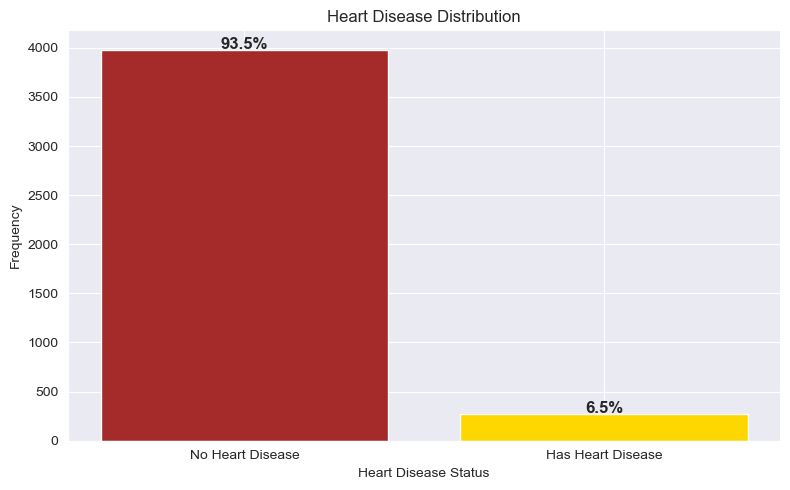

In [102]:


plt.figure(figsize=(8, 5))

# Define colors for bars
colors = ['brown', 'gold']

# Create bar chart
bars = plt.bar(heart_disease_counts.index, heart_disease_counts, color=colors)

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease Status')
plt.ylabel('Frequency')

plt.xticks([0, 1], labels=['No Heart Disease', 'Has Heart Disease'])

# Calculate total count for percentage calculation
total_count = heart_disease_counts.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 5,  
             f"{(heart_disease_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()  


            
        

#### <span style=' color:yellow'>ever_married column</span>

In [104]:
df['ever_married'].describe()

count     4254
unique       2
top        Yes
freq      3353
Name: ever_married, dtype: object

In [105]:
df['ever_married'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: ever_married
Non-Null Count  Dtype   
--------------  -----   
4254 non-null   category
dtypes: category(1)
memory usage: 4.4 KB


In [106]:
marriage_counts =df['ever_married'].value_counts()
marriage_counts

ever_married
Yes    3353
No      901
Name: count, dtype: int64

In [107]:
df['ever_married'].value_counts(normalize=True)

ever_married
Yes    0.788199
No     0.211801
Name: proportion, dtype: float64

In [108]:
df['ever_married'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)

ever_married
Yes    78.82%
No     21.18%
Name: proportion, dtype: object

In [109]:



ever_married_counts= df['ever_married'].value_counts()
ever_married_counts

ever_married
Yes    3353
No      901
Name: count, dtype: int64

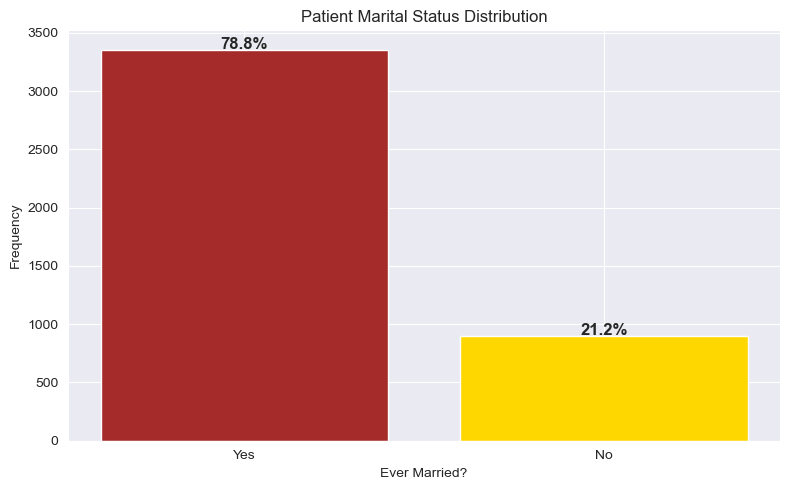

In [110]:
plt.figure(figsize=(8,5))



bars=plt.bar(ever_married_counts.index,ever_married_counts,color=colors)

plt.title('Patient Marital Status Distribution')
plt.xlabel('Ever Married?')
plt.ylabel('Frequency')

plt.tight_layout()

           
total_count = ever_married_counts.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 10,  
             f"{(ever_married_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.show()
          
       

#### <span style=' color:yellow'>Worktype column</span>

In [112]:
df['work_type'].describe()

count        4254
unique          4
top       Private
freq         2791
Name: work_type, dtype: object

In [113]:
df['work_type'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: work_type
Non-Null Count  Dtype   
--------------  -----   
4254 non-null   category
dtypes: category(1)
memory usage: 4.5 KB


In [114]:
worktypes=df['work_type'].value_counts()
worktypes

work_type
Private          2791
Self-employed     807
Govt_job          651
Never_worked        5
children            0
Name: count, dtype: int64

In [115]:
worktypes=df['work_type'].value_counts() # didn't work - write a code to remove the 'children' category
worktypes

work_type
Private          2791
Self-employed     807
Govt_job          651
Never_worked        5
children            0
Name: count, dtype: int64

In [116]:
df['work_type'].value_counts(normalize=True)

work_type
Private          0.656088
Self-employed    0.189704
Govt_job         0.153032
Never_worked     0.001175
children         0.000000
Name: proportion, dtype: float64

In [117]:
df['work_type'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)

work_type
Private          65.61%
Self-employed    18.97%
Govt_job         15.30%
Never_worked      0.12%
children          0.00%
Name: proportion, dtype: object

In [118]:
worktype_counts= df['work_type'].value_counts()
worktype_counts

work_type
Private          2791
Self-employed     807
Govt_job          651
Never_worked        5
children            0
Name: count, dtype: int64

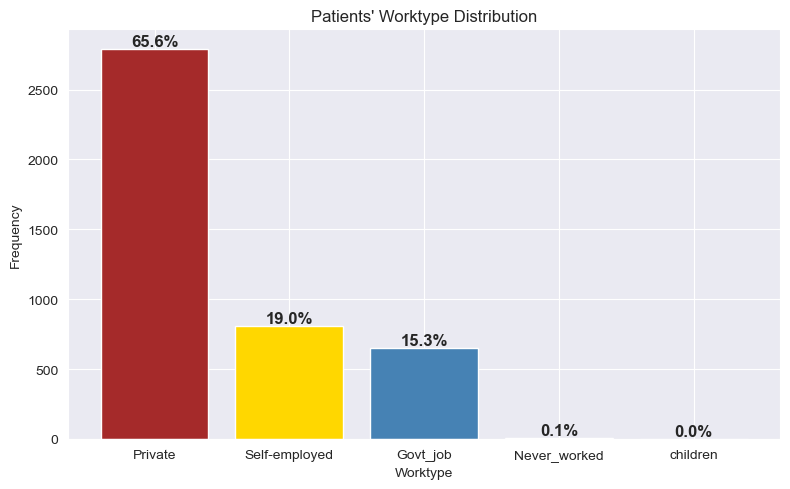

In [119]:
plt.figure(figsize=(8,5))

colors=['brown','gold','steelblue','purple']

bars=plt.bar(worktype_counts.index,worktypes,color=colors)

plt.title("Patients' Worktype Distribution")
plt.xlabel('Worktype')
plt.ylabel('Frequency')

plt.tight_layout()

           
total_count = worktype_counts.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(worktype_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.show()
          

#### <span style=' color:yellow'>residence type column</span>

In [121]:
df['Residence_type'].describe()

count      4254
unique        2
top       Urban
freq       2169
Name: Residence_type, dtype: object

In [122]:
df['Residence_type'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: Residence_type
Non-Null Count  Dtype   
--------------  -----   
4254 non-null   category
dtypes: category(1)
memory usage: 4.4 KB


In [123]:
df['Residence_type'].value_counts()

Residence_type
Urban    2169
Rural    2085
Name: count, dtype: int64

In [124]:
df['Residence_type'].value_counts(normalize=True)

Residence_type
Urban    0.509873
Rural    0.490127
Name: proportion, dtype: float64

In [125]:
df['Residence_type'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)

Residence_type
Urban    50.99%
Rural    49.01%
Name: proportion, dtype: object

In [126]:
residencetype= df['Residence_type'].value_counts()
residencetype


Residence_type
Urban    2169
Rural    2085
Name: count, dtype: int64

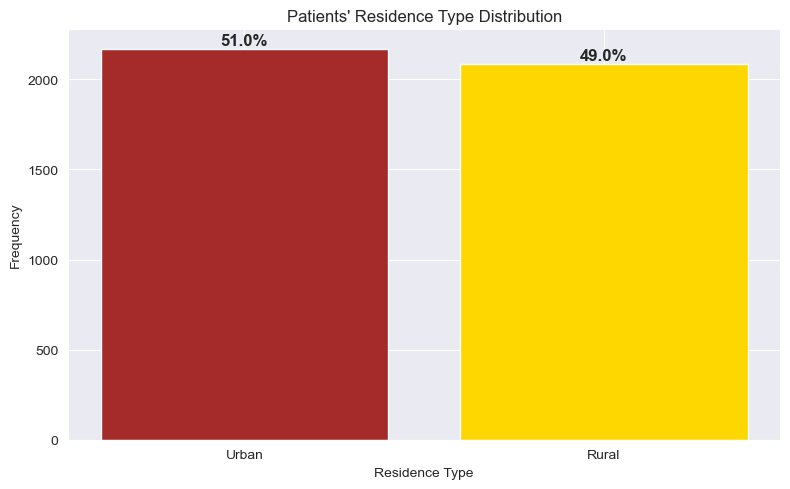

In [127]:
plt.figure(figsize=(8,5))

colors=['brown','gold']

bars=plt.bar(residencetype.index,residencetype,color=colors)

plt.title("Patients' Residence Type Distribution")
plt.xlabel('Residence Type')
plt.ylabel('Frequency')

plt.tight_layout()




total_count = residencetype.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(residencetype.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.show()
          

#### 
<span style=' color:yellow'>avg_glucose_level column</span>

In [129]:
df['avg_glucose_level'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: avg_glucose_level
Non-Null Count  Dtype  
--------------  -----  
4254 non-null   float64
dtypes: float64(1)
memory usage: 33.4 KB


In [130]:
df['avg_glucose_level'].describe()

count    4254.000000
mean      108.514394
std        47.769400
min        55.120000
25%        77.482500
50%        92.465000
75%       116.135000
max       271.740000
Name: avg_glucose_level, dtype: float64

In [131]:
glucose_counts =df['avg_glucose_level'].value_counts()
glucose_counts

avg_glucose_level
73.00     5
91.68     5
89.68     4
83.16     4
86.06     4
         ..
103.35    1
123.65    1
99.30     1
144.20    1
85.28     1
Name: count, Length: 3489, dtype: int64

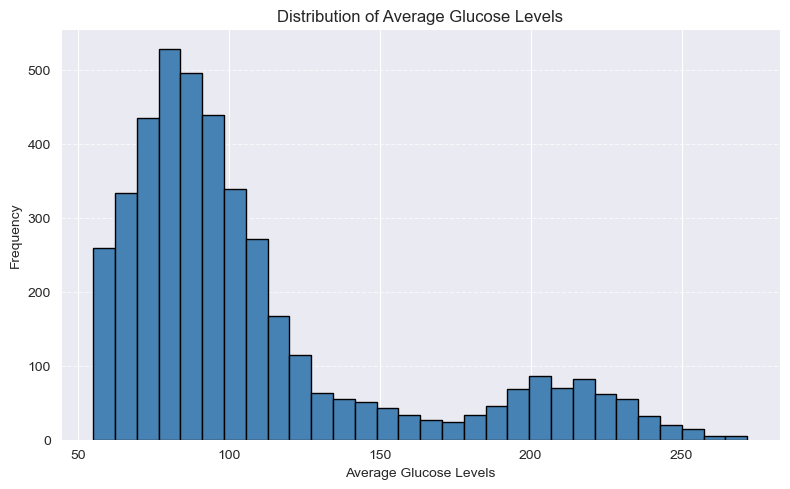

In [132]:

plt.figure(figsize=(8,5))

plt.hist(df['avg_glucose_level'], bins=30, color='steelblue', edgecolor='black')

plt.title('Distribution of Average Glucose Levels')
plt.xlabel('Average Glucose Levels')
plt.ylabel('Frequency')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#### <span style=' color:yellow'>bmi column</span>

In [134]:
df['bmi'].describe() #min is 11.3 and max is 92

count    4073.000000
mean       30.432752
std         7.235143
min        11.300000
25%        25.400000
50%        29.200000
75%        34.200000
max        92.000000
Name: bmi, dtype: float64

In [135]:
bmi_counts =df['bmi'].value_counts()
bmi_counts

bmi
28.7    37
27.7    36
28.4    36
26.7    35
27.0    34
        ..
54.0     1
44.1     1
51.5     1
71.9     1
54.1     1
Name: count, Length: 380, dtype: int64

In [136]:
df[df['bmi']==11.3] 

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2802,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.3,Unknown,0


In [137]:
df[df['bmi']==92] 

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3531,Male,38,1,0,Yes,Private,Rural,56.9,92.0,never smoked,0


In [138]:
df[df['bmi']<18.5]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
229,Female,81,0,0,Yes,Self-employed,Rural,81.95,16.9,never smoked,1
250,Female,52,0,0,Yes,Private,Urban,77.59,17.7,formerly smoked,0
584,Female,43,0,0,Yes,Self-employed,Urban,98.09,17.3,never smoked,0
633,Female,66,0,0,Yes,Private,Urban,102.07,16.7,smokes,0
853,Female,30,0,0,No,Private,Rural,73.69,17.3,never smoked,0
1023,Female,49,0,0,Yes,Private,Urban,67.55,17.6,formerly smoked,0
1198,Female,64,0,0,No,Govt_job,Rural,108.10,17.9,never smoked,0
1249,Female,24,0,0,No,Private,Rural,120.77,16.9,never smoked,0
1252,Female,78,0,0,Yes,Private,Rural,154.75,17.6,never smoked,0
1397,Female,20,0,0,No,Private,Urban,73.83,16.6,Unknown,0


In [139]:
df[df['bmi'] < 18.5].shape[0]


38

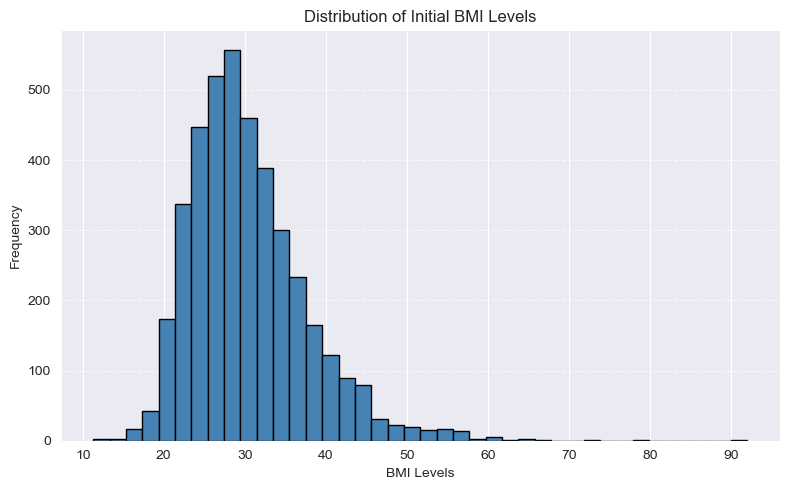

In [140]:

plt.figure(figsize=(8,5))

plt.hist(df['bmi'], bins=40, color='steelblue', edgecolor='black')

plt.title('Distribution of Initial BMI Levels')
plt.xlabel('BMI Levels')
plt.ylabel('Frequency')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#### <span style=' color:yellow'>SMOKING column</span>

In [142]:
df['smoking_status'].describe()

count             4254
unique               4
top       never smoked
freq              1752
Name: smoking_status, dtype: object

In [143]:
df['smoking_status'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: smoking_status
Non-Null Count  Dtype   
--------------  -----   
4254 non-null   category
dtypes: category(1)
memory usage: 4.5 KB


In [144]:
df['smoking_status'].value_counts() 

smoking_status
never smoked       1752
Unknown             862
formerly smoked     860
smokes              780
Name: count, dtype: int64

In [145]:
original_smoking=df['smoking_status'].value_counts() 
original_smoking

smoking_status
never smoked       1752
Unknown             862
formerly smoked     860
smokes              780
Name: count, dtype: int64

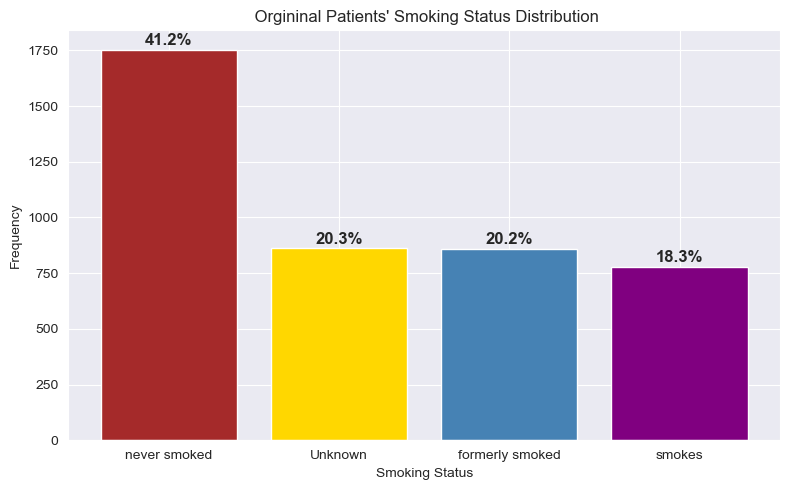

In [146]:
plt.figure(figsize=(8,5))

colors=['brown','gold','steelblue','purple']

bars=plt.bar(original_smoking.index,original_smoking,color=colors)

plt.title(" Orgininal Patients' Smoking Status Distribution")
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')

plt.tight_layout()




total_count = original_smoking.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(original_smoking.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.show()
          

In [147]:
df[df['smoking_status']== 'Unknown']

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
8,Female,59,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,Female,78,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1
13,Male,78,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,Male,57,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
23,Male,82,0,1,Yes,Private,Rural,208.30,32.5,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...
4237,Female,64,1,0,Yes,Self-employed,Urban,76.89,30.2,Unknown,0
4243,Male,68,0,0,Yes,Self-employed,Urban,91.68,40.8,Unknown,0
4246,Female,45,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
4248,Female,18,0,0,No,Private,Urban,82.85,46.9,Unknown,0


In [148]:
df['smoking_status'] =df['smoking_status'].replace({'Unknown':np.nan})

C:\Users\USER\AppData\Local\Temp\ipykernel_14964\2806469962.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['smoking_status'] =df['smoking_status'].replace({'Unknown':np.nan})


In [149]:
df['smoking_status'].isnull().sum()


862

### <span style=' color:yellow'>Predicting unknown smoking status</span>

In [151]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [152]:
X = df[["age", "work_type", "smoking_status"]].copy() #always make a copy during such manipulations

In [153]:
X

,age,work_type,smoking_status
0,67,Private,formerly smoked
1,61,Self-employed,never smoked
2,80,Private,never smoked
3,49,Private,smokes
4,79,Self-employed,never smoked
...,...,...,...
4249,80,Private,never smoked
4250,81,Self-employed,never smoked
4251,35,Self-employed,never smoked
4252,51,Private,formerly smoked


In [154]:
X.isnull().sum()

age                 0
work_type           0
smoking_status    862
dtype: int64

In [155]:
X['work_type'].dtype

CategoricalDtype(categories=['Govt_job', 'Never_worked', 'Private', 'Self-employed',
                  'children'],
, ordered=False, categories_dtype=object)

In [156]:
X["work_type"] = X["work_type"].cat.codes  #.cat.codes is a quick way to convert categorical to numerical values 

In [157]:
X['work_type'].value_counts()

work_type
2    2791
3     807
0     651
1       5
Name: count, dtype: int64

In [158]:
X

,age,work_type,smoking_status
0,67,2,formerly smoked
1,61,3,never smoked
2,80,2,never smoked
3,49,2,smokes
4,79,3,never smoked
...,...,...,...
4249,80,2,never smoked
4250,81,3,never smoked
4251,35,3,never smoked
4252,51,2,formerly smoked


In [159]:



missing = X[X["smoking_status"].isna()]

In [160]:
missing

,age,work_type,smoking_status
8,59,2,NaN
9,78,2,NaN
13,78,2,NaN
19,57,0,NaN
23,82,2,NaN
...,...,...,...
4237,64,3,NaN
4243,68,3,NaN
4246,45,2,NaN
4248,18,2,NaN


In [161]:
missing.shape

(862, 3)

In [162]:
#Manual Label Encoding

X['smoking_status']=X['smoking_status'].replace({"never smoked": 0,"formerly smoked": 1, "smokes": 2})

C:\Users\USER\AppData\Local\Temp\ipykernel_14964\556992377.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['smoking_status']=X['smoking_status'].replace({"never smoked": 0,"formerly smoked": 1, "smokes": 2})
C:\Users\USER\AppData\Local\Temp\ipykernel_14964\556992377.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X['smoking_status']=X['smoking_status'].replace({"never smoked": 0,"formerly smoked": 1, "smokes": 2})


In [163]:
X= X.dropna() 


In [164]:
X

,age,work_type,smoking_status
0,67,2,1
1,61,3,0
2,80,2,0
3,49,2,2
4,79,3,0
...,...,...,...
4247,57,2,0
4249,80,2,0
4250,81,3,0
4251,35,3,0


In [165]:
y = X.pop("smoking_status")

In [166]:
X.isnull().sum()

age          0
work_type    0
dtype: int64

In [167]:
y

0       1
1       0
2       0
3       2
4       0
       ..
4247    0
4249    0
4250    0
4251    0
4252    1
Name: smoking_status, Length: 3392, dtype: category
Categories (3, int64): [1, 0, 2]

In [168]:
# Train Decision Tree pipeline
DT_smoking_pipe = Pipeline(
    steps=[
    ("dt", DecisionTreeClassifier(max_depth=5, random_state=42))  
])
DT_smoking_pipe.fit(X, y)

Pipeline(steps=[('dt', DecisionTreeClassifier(max_depth=5, random_state=42))])

In [169]:
predicted_values = DT_smoking_pipe.predict(missing[["age", "work_type"]])

In [170]:
predicted_values

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [171]:
reverse_mapping = {0: "never smoked", 1: "formerly smoked", 2: "smokes"}


In [172]:
predicted_labels = [reverse_mapping[val] for val in predicted_values]

In [173]:
df.loc[missing.index, "smoking_status"] = predicted_labels #he loc function ensures that only those specific rows in the "smoking_status" column are updated.

print("Missing smoking statuses successfully filled!")

Missing smoking statuses successfully filled!


In [174]:
smoking_counts=df['smoking_status'].value_counts()
smoking_counts

smoking_status
never smoked       2598
formerly smoked     876
smokes              780
Name: count, dtype: int64

In [175]:
smoking=df['smoking_status'].value_counts(normalize=True)

In [176]:
smoking

smoking_status
never smoked       0.610719
formerly smoked    0.205924
smokes             0.183357
Name: proportion, dtype: float64

In [177]:
smoking.mul(100).map('{:.2f}'.format)

smoking_status
never smoked       61.07
formerly smoked    20.59
smokes             18.34
Name: proportion, dtype: object

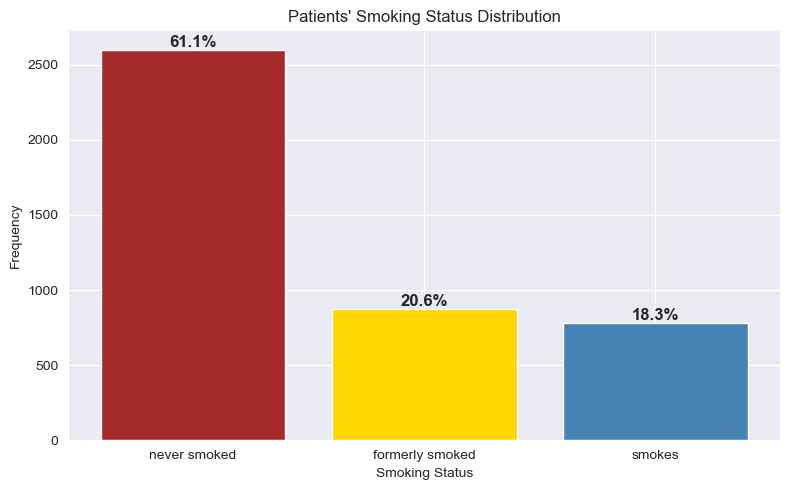

In [178]:
plt.figure(figsize=(8,5))



bars=plt.bar(smoking_counts.index,smoking_counts,color=colors)

plt.title("Patients' Smoking Status Distribution")
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')

plt.tight_layout()




total_count = smoking_counts.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(smoking_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.show()
          

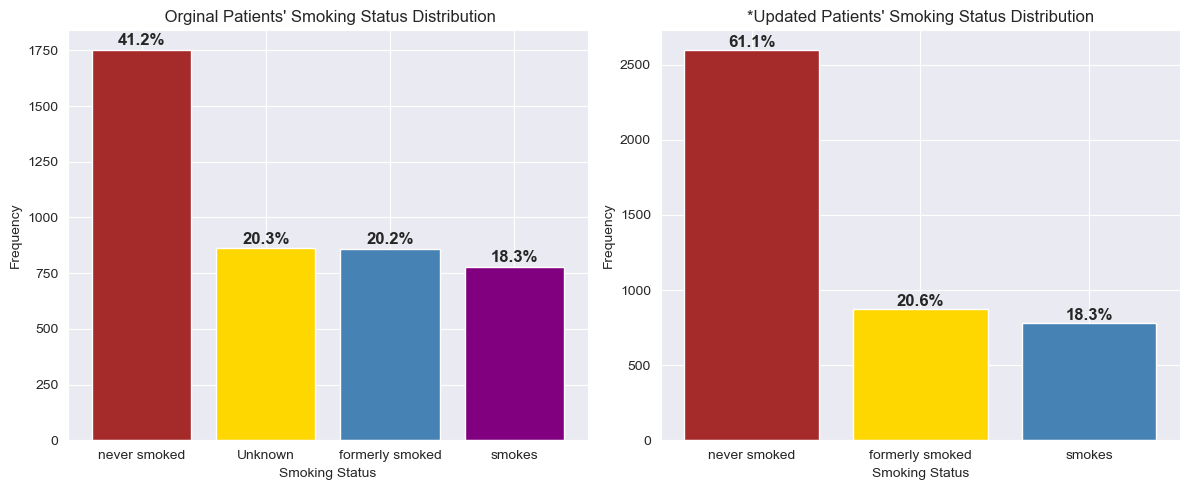

In [179]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)



bars=plt.bar(original_smoking.index,original_smoking,color=colors)

plt.title(" Orginal Patients' Smoking Status Distribution")
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')



total_count = original_smoking.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(original_smoking.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.subplot(1,2,2)




bars=plt.bar(smoking_counts.index,smoking_counts,color=colors)

plt.title("*Updated Patients' Smoking Status Distribution")
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')



total_count = smoking_counts.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(smoking_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("smoking.svg")

plt.show()


#### <span style=' color:yellow'>stroke column</span>

In [181]:
df['stroke'].describe()

count    4254.000000
mean        0.058063
std         0.233890
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: stroke, dtype: float64

In [182]:

df['stroke'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: stroke
Non-Null Count  Dtype
--------------  -----
4254 non-null   int64
dtypes: int64(1)
memory usage: 33.4 KB


In [183]:
stroke_counts=df['stroke'].value_counts()
stroke_counts

stroke
0    4007
1     247
Name: count, dtype: int64

In [184]:
df['stroke'].value_counts(normalize=True)

stroke
0    0.941937
1    0.058063
Name: proportion, dtype: float64

In [185]:
df['stroke'].value_counts(normalize=True).mul(100).map('{:.2f}%'.format)

stroke
0    94.19%
1     5.81%
Name: proportion, dtype: object

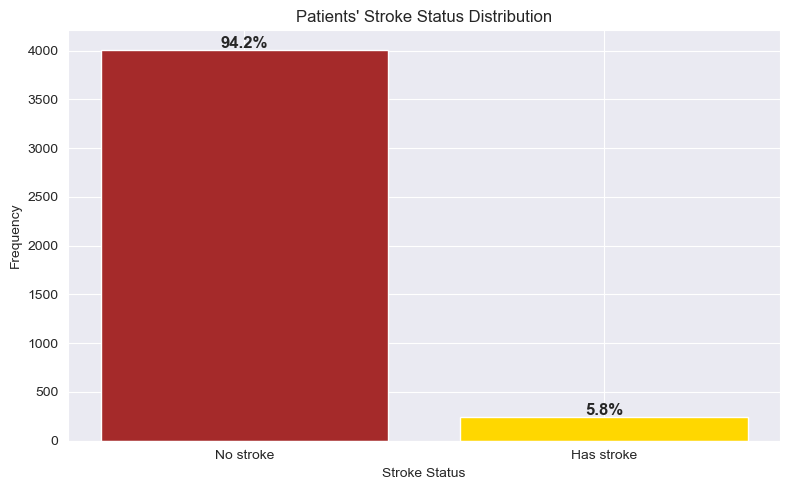

In [186]:
plt.figure(figsize=(8,5))



bars=plt.bar(stroke_counts.index,stroke_counts,color=colors)

plt.title("Patients' Stroke Status Distribution")
plt.xlabel('Stroke Status')
plt.ylabel('Frequency')

plt.xticks([0,1],labels=['No stroke','Has stroke'])





total_count = stroke_counts.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(stroke_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### <span style=' color:yellow'> Predicting missing bmi </span>

In [188]:
df['bmi'].describe() #min is 11.3 and mas is 92

count    4073.000000
mean       30.432752
std         7.235143
min        11.300000
25%        25.400000
50%        29.200000
75%        34.200000
max        92.000000
Name: bmi, dtype: float64

In [189]:
df['bmi'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4254 entries, 0 to 4253
Series name: bmi
Non-Null Count  Dtype  
--------------  -----  
4073 non-null   float64
dtypes: float64(1)
memory usage: 33.4 KB


In [190]:
bmi_counts =df['bmi'].value_counts()
bmi_counts

bmi
28.7    37
27.7    36
28.4    36
26.7    35
27.0    34
        ..
54.0     1
44.1     1
51.5     1
71.9     1
54.1     1
Name: count, Length: 380, dtype: int64

In [191]:
df['bmi'].isnull().sum()

181

In [192]:
df[df['bmi'].isnull()]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,Female,59,0,0,Yes,Private,Rural,76.15,NaN,never smoked,1
13,Male,78,0,1,Yes,Private,Urban,219.84,NaN,never smoked,1
19,Male,57,0,1,No,Govt_job,Urban,217.08,NaN,never smoked,1
27,Male,58,0,0,Yes,Private,Rural,189.84,NaN,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4194,Male,41,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
4203,Male,40,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
4241,Female,45,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
4244,Male,40,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


In [193]:
from sklearn.tree import DecisionTreeRegressor #Regressor models for predicting numerical data
from sklearn.pipeline import Pipeline #Pipelines allows us to do both preprocessing and modelling in a very structured way

In [194]:
X = df[["gender", "age", "bmi"]].copy() #its imp to copy -to ensure you don't alter the 
#original dataset

In [195]:
X

,gender,age,bmi
0,Male,67,36.6
1,Female,61,NaN
2,Male,80,32.5
3,Female,49,34.4
4,Female,79,24.0
...,...,...,...
4249,Female,80,NaN
4250,Female,81,40.0
4251,Female,35,30.6
4252,Male,51,25.6


In [196]:
X["gender"] = X["gender"].map({"Male": 0, "Female": 1})

#Gender is a categorical column so it needs to be encoded for any further analysis
# There are 2 other ways i could have done this(one hot encoding and categotical bossting),but i choose label encoding
#label encoding ,beacuse the model im using (DT) is non-linear, will not assume any ordinal rel,
#OHE is used when linear models like logistic and linear regressions and SVM are used 
#catboost was taking too long to execute !

In [197]:
# Locating the  missing BMI values
missing = X[X["bmi"].isna()]

In [198]:
missing

,gender,age,bmi
1,1,61,NaN
8,1,59,NaN
13,0,78,NaN
19,0,57,NaN
27,0,58,NaN
...,...,...,...
4194,0,41,NaN
4203,0,40,NaN
4241,1,45,NaN
4244,0,40,NaN


In [199]:
X = X.dropna() #this drops all rows in X(gender,age,bmi) where bmi is missing

y = X.pop("bmi") #removes bmi from X and assign it to y (target)


In [200]:
X

,gender,age
0,0,67
2,0,80
3,1,49
4,1,79
5,0,81
...,...,...
4248,1,18
4250,1,81
4251,1,35
4252,0,51


In [201]:
X.isnull().sum()

gender    0
age       0
dtype: int64

In [202]:
y.isnull().sum()

0

In [203]:
y

0       36.6
2       32.5
3       34.4
4       24.0
5       29.0
        ... 
4248    46.9
4250    40.0
4251    30.6
4252    25.6
4253    26.2
Name: bmi, Length: 4073, dtype: float64

In [204]:
DT_bmi_pipe = Pipeline(steps=[
    ("dt", DecisionTreeRegressor(max_depth=5, random_state=42))  # No need to scale for trees
])
DT_bmi_pipe.fit(X, y)

Pipeline(steps=[('dt', DecisionTreeRegressor(max_depth=5, random_state=42))])

In [205]:
# Predict and fill missing BMI values
df.loc[missing.index, "bmi"] = DT_bmi_pipe.predict(missing[["gender", "age"]])


In [206]:
df['bmi'].isnull().sum() #wow! no more missing values!

0

In [207]:
df.isnull().any()

gender               False
age                  False
hypertension         False
heart_disease        False
ever_married         False
work_type            False
Residence_type       False
avg_glucose_level    False
bmi                  False
smoking_status       False
stroke               False
dtype: bool

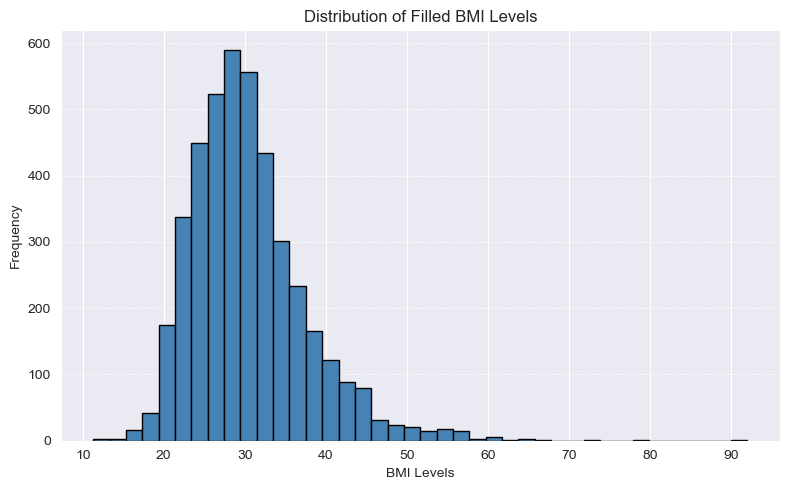

In [208]:

plt.figure(figsize=(8,5))

plt.hist(df['bmi'], bins=40, color='steelblue', edgecolor='black')

plt.title('Distribution of Filled BMI Levels')
plt.xlabel('BMI Levels')
plt.ylabel('Frequency')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [209]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,31.341304,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4249,Female,80,1,0,Yes,Private,Urban,83.75,28.281319,never smoked,0
4250,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
4251,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
4252,Male,51,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [210]:
df.isnull().any()

gender               False
age                  False
hypertension         False
heart_disease        False
ever_married         False
work_type            False
Residence_type       False
avg_glucose_level    False
bmi                  False
smoking_status       False
stroke               False
dtype: bool

# <span style=' color:yellow'> ALL UNIVARIATE GRAPHS</span>

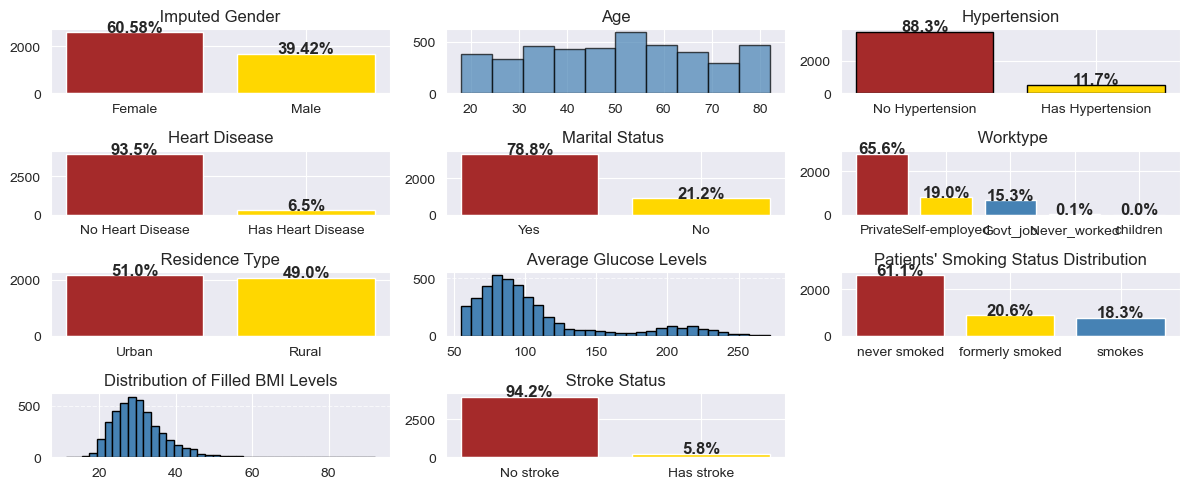

In [212]:
plt.figure(figsize=(12,5))


plt.subplot(4,3,1)

# Plot histogram with customized bar width
bars = plt.bar(gender_counts2.index, gender_counts2.values, color= colors)
plt.title(' Imputed Gender ')
# Add percentages as text on top of the bars
for i, bar in enumerate(bars):
    height = bar.get_height()  # Get height of each bar
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center text on the bar
        height + 20,  # Slightly above the top of the bar
        f"{percentages.iloc[i]:.2f}%",  
        ha='center', fontsize=12, fontweight='bold'
    )



plt.subplot(4,3,2)
plt.hist(df['age'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)   #alpha sets opacity of the bars . 1- fully opaque, and 0-transparent
plt.title('Age')


plt.subplot(4,3,3)
bars = plt.bar(hypertension_counts.index, hypertension_counts, color=colors, edgecolor='black')
plt.xticks([0, 1], labels=['No Hypertension', 'Has Hypertension'])
plt.title('Hypertension')
# Add percentages on top of bars
total_count = hypertension_counts.sum()
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 
             height + 60,  
             f"{(hypertension_counts.iloc[i] / total_count) * 100:.1f}%", 
             ha='center', fontsize=12, fontweight='bold')



plt.subplot(4,3,4)
# Define colors for bars

# Create bar chart
bars = plt.bar(heart_disease_counts.index, heart_disease_counts, color=colors)
plt.title('Heart Disease')
plt.xticks([0, 1], labels=['No Heart Disease', 'Has Heart Disease'])
# Calculate total count for percentage calculation
total_count = heart_disease_counts.sum()
# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 5,  
             f"{(heart_disease_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.subplot(4,3,5)

bars=plt.bar(ever_married_counts.index,ever_married_counts,color=colors)
plt.title('Marital Status ')
total_count = ever_married_counts.sum()
# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 5,  
             f"{(ever_married_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.subplot(4,3,6)

bars=plt.bar(worktype_counts.index,worktypes,color=colors)
plt.title(" Worktype")
total_count = worktype_counts.sum()
# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(worktype_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.subplot(4,3,7)

bars=plt.bar(residencetype.index,residencetype,color=colors)
plt.title(" Residence Type ")
total_count = residencetype.sum()
# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(residencetype.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.subplot(4,3,8)
plt.hist(df['avg_glucose_level'], bins=30, color='steelblue', edgecolor='black')
plt.title(' Average Glucose Levels')
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.subplot(4,3,9)

bars=plt.bar(smoking_counts.index,smoking_counts,color=colors)
plt.title("Patients' Smoking Status Distribution")
total_count = smoking_counts.sum()
# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(smoking_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')
    

plt.subplot(4,3,11)

bars=plt.bar(stroke_counts.index,stroke_counts,color=colors)
plt.title(" Stroke Status ")
plt.xticks([0,1],labels=['No stroke','Has stroke'])
total_count = stroke_counts.sum()
# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(stroke_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')


plt.subplot(4,3,10)
plt.hist(df['bmi'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Filled BMI Levels')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()



plt.savefig('Different Feature Graphs.svg')
            
plt.show()






# <span style=' color:yellow'> EXTENSIVE BIVARIATE AND MULTIVARIATE ANALYSIS</span>

In [214]:
custom_palette=['brown','gold']

C:\Users\USER\AppData\Local\Temp\ipykernel_14964\2603312429.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_stroke_counts = df.groupby(['gender', 'stroke']).size().unstack(fill_value=0)
C:\Users\USER\AppData\Local\Temp\ipykernel_14964\2603312429.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marital_stroke_counts = df.groupby(['ever_married', 'stroke']).size().unstack(fill_value=0)
C:\Users\USER\AppData\Local\Temp\ipykernel_14964\2603312429.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retai

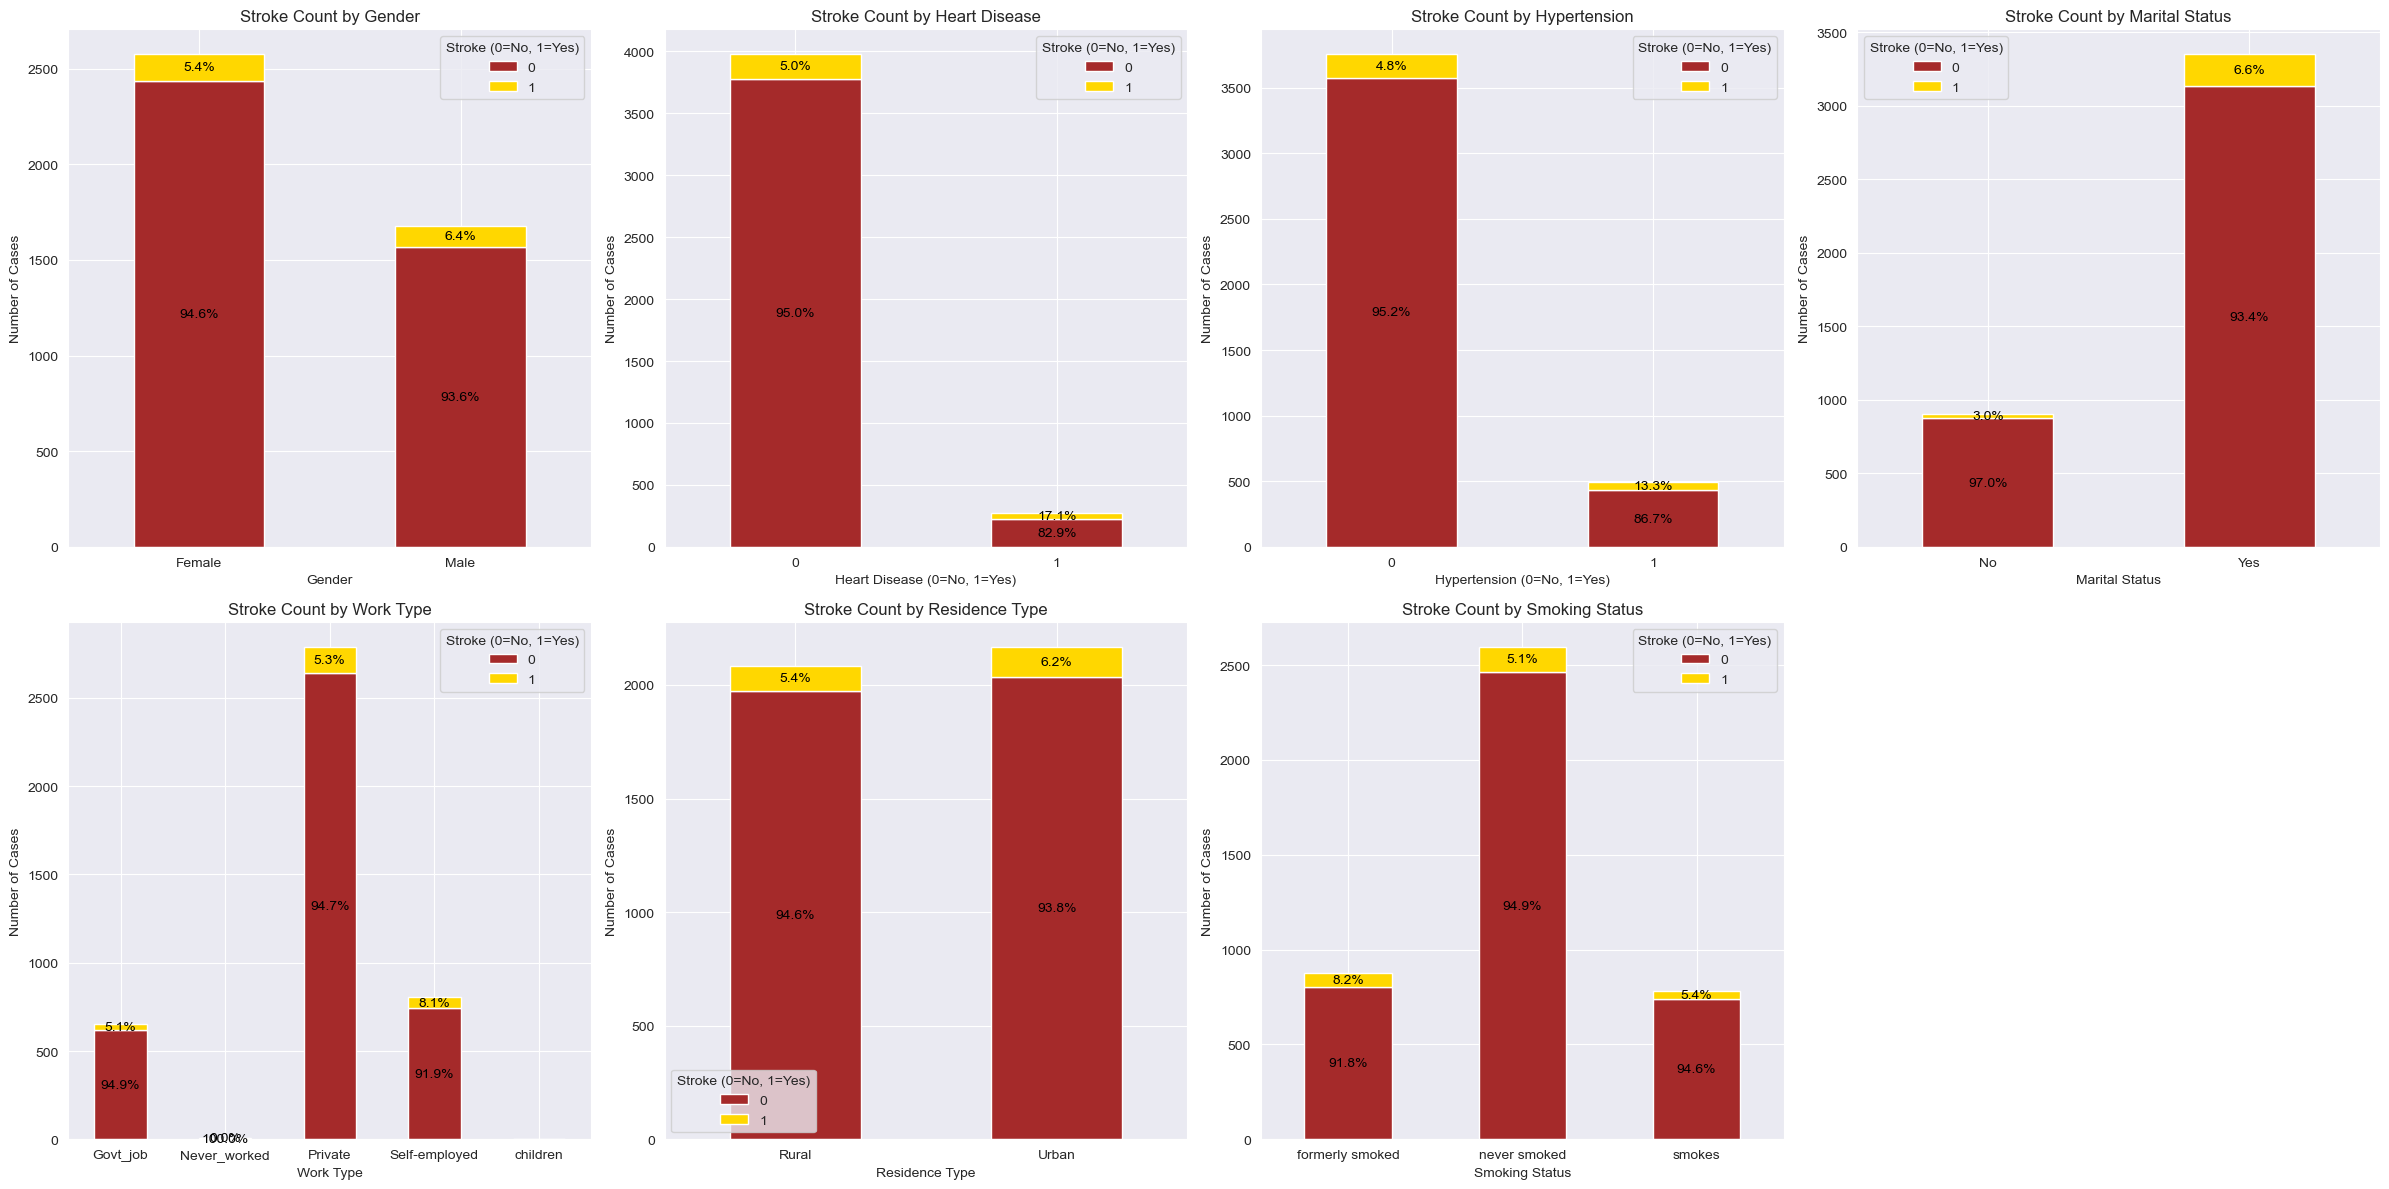

In [215]:
# Create the figure and axes
fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # 2 rows, 4 columns, increased figure size for more subplots
axes = axes.flatten() # Flatten the axes array to simplify indexing


# --- Plot 1: Stroke Count by Gender ---
gender_stroke_counts = df.groupby(['gender', 'stroke']).size().unstack(fill_value=0)
ax1 = gender_stroke_counts.plot(kind='bar', stacked=True, ax=axes[0], color=custom_palette)
ax1.set_title('Stroke Count by Gender')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Number of Cases')
ax1.tick_params(axis='x', rotation=0)
ax1.legend(title='Stroke (0=No, 1=Yes)')

# Add percentage labels for each segment
for i, gender in enumerate(gender_stroke_counts.index):
    total = gender_stroke_counts.loc[gender].sum()
    stroke_count = gender_stroke_counts.loc[gender, 1]
    no_stroke_count = gender_stroke_counts.loc[gender, 0]
    
    # Calculate percentages
    stroke_pct = (stroke_count / total) * 100
    no_stroke_pct = (no_stroke_count / total) * 100
    
    # Position for the "No Stroke" (0) label
    y_pos_0 = no_stroke_count / 2
    ax1.text(i, y_pos_0, f'{no_stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')
    
    # Position for the "Stroke" (1) label
    y_pos_1 = no_stroke_count + (stroke_count / 2)
    ax1.text(i, y_pos_1, f'{stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')


# --- Plot 2: Stroke Count by Heart Disease ---
heart_disease_stroke_counts = df.groupby(['heart_disease', 'stroke']).size().unstack(fill_value=0)
ax2 = heart_disease_stroke_counts.plot(kind='bar', stacked=True, ax=axes[1], color=custom_palette)
ax2.set_title('Stroke Count by Heart Disease')
ax2.set_xlabel('Heart Disease (0=No, 1=Yes)')
ax2.set_ylabel('Number of Cases')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Stroke (0=No, 1=Yes)')

# Add percentage labels for each segment
for i, heart_disease in enumerate(heart_disease_stroke_counts.index):
    total = heart_disease_stroke_counts.loc[heart_disease].sum()
    stroke_count = heart_disease_stroke_counts.loc[heart_disease, 1]
    no_stroke_count = heart_disease_stroke_counts.loc[heart_disease, 0]
    
    # Calculate percentages
    stroke_pct = (stroke_count / total) * 100
    no_stroke_pct = (no_stroke_count / total) * 100
    
    # Position for the "No Stroke" (0) label
    y_pos_0 = no_stroke_count / 2
    ax2.text(i, y_pos_0, f'{no_stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')
    
    # Position for the "Stroke" (1) label
    y_pos_1 = no_stroke_count + (stroke_count / 2)
    ax2.text(i, y_pos_1, f'{stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')


# --- Plot 3: Stroke Count by Hypertension ---
hypertension_stroke_counts = df.groupby(['hypertension', 'stroke']).size().unstack(fill_value=0)
ax3 = hypertension_stroke_counts.plot(kind='bar', stacked=True, ax=axes[2], color=custom_palette)
ax3.set_title('Stroke Count by Hypertension')
ax3.set_xlabel('Hypertension (0=No, 1=Yes)')
ax3.set_ylabel('Number of Cases')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(title='Stroke (0=No, 1=Yes)')

# Add percentage labels for each segment
for i, hypertension in enumerate(hypertension_stroke_counts.index):
    total = hypertension_stroke_counts.loc[hypertension].sum()
    stroke_count = hypertension_stroke_counts.loc[hypertension, 1]
    no_stroke_count = hypertension_stroke_counts.loc[hypertension, 0]
    
    # Calculate percentages
    stroke_pct = (stroke_count / total) * 100
    no_stroke_pct = (no_stroke_count / total) * 100
    
    # Position for the "No Stroke" (0) label
    y_pos_0 = no_stroke_count / 2
    ax3.text(i, y_pos_0, f'{no_stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')
    
    # Position for the "Stroke" (1) label
    y_pos_1 = no_stroke_count + (stroke_count / 2)
    ax3.text(i, y_pos_1, f'{stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')


# --- Plot 4: Stroke Count by Marital Status ---
marital_stroke_counts = df.groupby(['ever_married', 'stroke']).size().unstack(fill_value=0)
ax4 = marital_stroke_counts.plot(kind='bar', stacked=True, ax=axes[3], color=custom_palette)
ax4.set_title('Stroke Count by Marital Status')
ax4.set_xlabel('Marital Status')
ax4.set_ylabel('Number of Cases')
ax4.tick_params(axis='x', rotation=0)
ax4.legend(title='Stroke (0=No, 1=Yes)')

# Add percentage labels for each segment
for i, marital_status in enumerate(marital_stroke_counts.index):
    total = marital_stroke_counts.loc[marital_status].sum()
    stroke_count = marital_stroke_counts.loc[marital_status, 1]
    no_stroke_count = marital_stroke_counts.loc[marital_status, 0]
    
    # Calculate percentages
    stroke_pct = (stroke_count / total) * 100
    no_stroke_pct = (no_stroke_count / total) * 100
    
    # Position for the "No Stroke" (0) label
    y_pos_0 = no_stroke_count / 2
    ax4.text(i, y_pos_0, f'{no_stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')
    
    # Position for the "Stroke" (1) label
    y_pos_1 = no_stroke_count + (stroke_count / 2)
    ax4.text(i, y_pos_1, f'{stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')


# --- Plot 5: Stroke Count by Work Type ---
work_type_stroke_counts = df.groupby(['work_type', 'stroke']).size().unstack(fill_value=0)
ax5 = work_type_stroke_counts.plot(kind='bar', stacked=True, ax=axes[4], color=custom_palette)
ax5.set_title('Stroke Count by Work Type')
ax5.set_xlabel('Work Type')
ax5.set_ylabel('Number of Cases')
ax5.tick_params(axis='x', rotation=0)
ax5.legend(title='Stroke (0=No, 1=Yes)')

# Add percentage labels for each segment
for i, work_type in enumerate(work_type_stroke_counts.index):
    total = work_type_stroke_counts.loc[work_type].sum()
    if total > 0:  # Ensure we don't divide by zero
        stroke_count = work_type_stroke_counts.loc[work_type, 1]
        no_stroke_count = work_type_stroke_counts.loc[work_type, 0]
        
        # Calculate percentages
        stroke_pct = (stroke_count / total) * 100
        no_stroke_pct = (no_stroke_count / total) * 100
        
        # Position for the "No Stroke" (0) label
        y_pos_0 = no_stroke_count / 2
        ax5.text(i, y_pos_0, f'{no_stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')
        
        # Position for the "Stroke" (1) label
        y_pos_1 = no_stroke_count + (stroke_count / 2)
        ax5.text(i, y_pos_1, f'{stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')


# --- Plot 6: Stroke Count by Residence Type ---
residence_type_stroke_counts = df.groupby(['Residence_type', 'stroke']).size().unstack(fill_value=0)
ax6 = residence_type_stroke_counts.plot(kind='bar', stacked=True, ax=axes[5], color=custom_palette)
ax6.set_title('Stroke Count by Residence Type')
ax6.set_xlabel('Residence Type')
ax6.set_ylabel('Number of Cases')
ax6.tick_params(axis='x', rotation=0)
ax6.legend(title='Stroke (0=No, 1=Yes)')

# Add percentage labels for each segment
for i, residence_type in enumerate(residence_type_stroke_counts.index):
    total = residence_type_stroke_counts.loc[residence_type].sum()
    stroke_count = residence_type_stroke_counts.loc[residence_type, 1]
    no_stroke_count = residence_type_stroke_counts.loc[residence_type, 0]
    
    # Calculate percentages
    stroke_pct = (stroke_count / total) * 100
    no_stroke_pct = (no_stroke_count / total) * 100
    
    # Position for the "No Stroke" (0) label
    y_pos_0 = no_stroke_count / 2
    ax6.text(i, y_pos_0, f'{no_stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')
    
    # Position for the "Stroke" (1) label
    y_pos_1 = no_stroke_count + (stroke_count / 2)
    ax6.text(i, y_pos_1, f'{stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')


# --- Plot 7: Stroke Count by Smoking Status ---
smoking_status_stroke_counts = df.groupby(['smoking_status', 'stroke']).size().unstack(fill_value=0)
ax7 = smoking_status_stroke_counts.plot(kind='bar', stacked=True, ax=axes[6], color=custom_palette)
ax7.set_title('Stroke Count by Smoking Status')
ax7.set_xlabel('Smoking Status')
ax7.set_ylabel('Number of Cases')
ax7.tick_params(axis='x', rotation=0)
ax7.legend(title='Stroke (0=No, 1=Yes)')

# Add percentage labels for each segment
for i, smoking_status in enumerate(smoking_status_stroke_counts.index):
    total = smoking_status_stroke_counts.loc[smoking_status].sum()
    stroke_count = smoking_status_stroke_counts.loc[smoking_status, 1]
    no_stroke_count = smoking_status_stroke_counts.loc[smoking_status, 0]
    
    # Calculate percentages
    stroke_pct = (stroke_count / total) * 100
    no_stroke_pct = (no_stroke_count / total) * 100
    
    # Position for the "No Stroke" (0) label
    y_pos_0 = no_stroke_count / 2
    ax7.text(i, y_pos_0, f'{no_stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')
    
    # Position for the "Stroke" (1) label
    y_pos_1 = no_stroke_count + (stroke_count / 2)
    ax7.text(i, y_pos_1, f'{stroke_pct:.1f}%', ha='center', va='center', fontsize=10, color='black')


# Remove the last empty subplot
fig.delaxes(axes[7])

# Adjust layout for better spacing
plt.tight_layout()

plt.savefig("All Bivariates.svg")
plt.show()

D:\ANACONDA\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
D:\ANACONDA\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 66.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


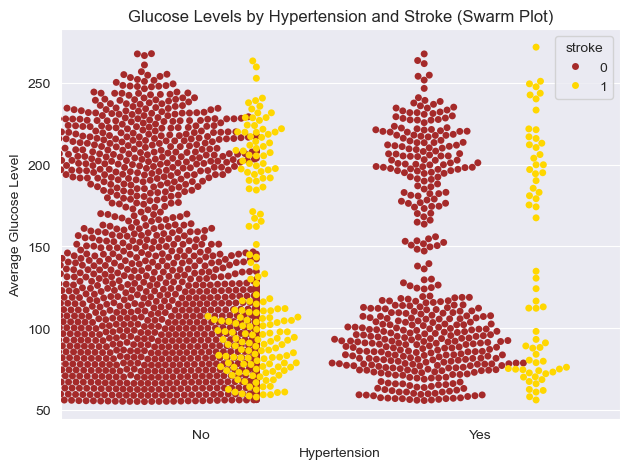

In [216]:


sns.swarmplot(data=df, x='hypertension', y='avg_glucose_level', hue='stroke', palette=custom_palette, dodge=True)
plt.title("Glucose Levels by Hypertension and Stroke (Swarm Plot)")

plt.xlabel("Hypertension")
plt.xticks([0, 1], ['No', 'Yes'])

plt.ylabel("Average Glucose Level")

plt.tight_layout()
plt.savefig("Hyptersion vs glucose_bivariate.svg")

plt.show()

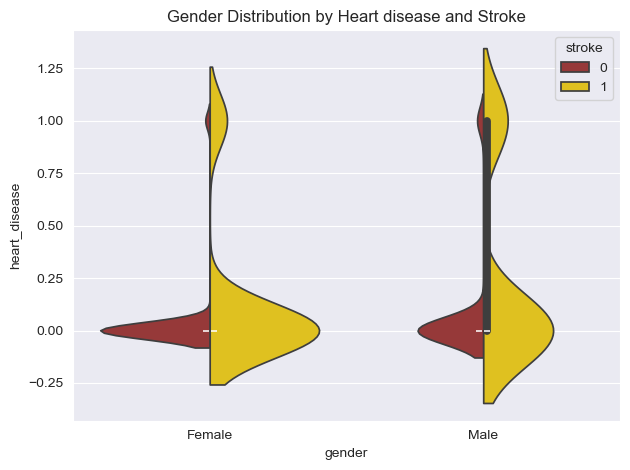

In [217]:
sns.violinplot(data=df, y='heart_disease', x='gender', hue='stroke', palette=custom_palette, split=True)
plt.title("Gender Distribution by Heart disease and Stroke")

plt.tight_layout()
plt.savefig("Heart disease  vs gender_bivariate.svg")

plt.show() 

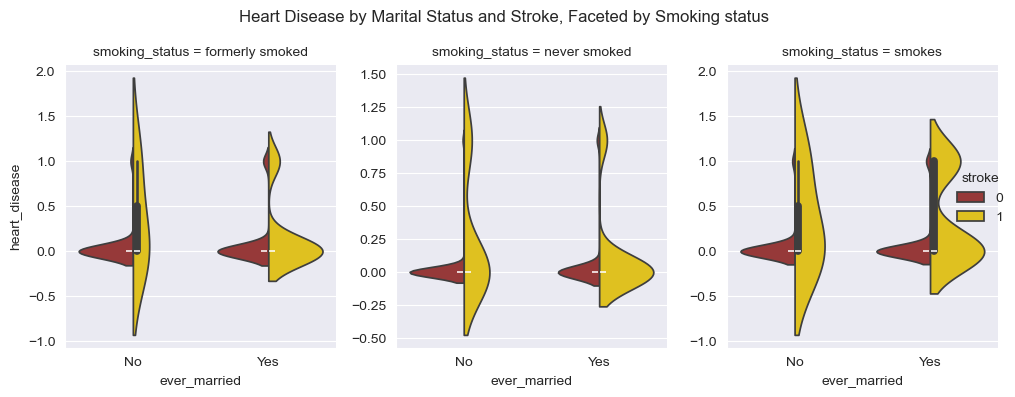

In [218]:


sns.catplot(data=df,
            y='heart_disease',
            col='smoking_status',
            hue='stroke',
            x='ever_married',
            kind='violin',
            palette=custom_palette,
            split=True,
            height=4,
            aspect=0.8,
            sharey=False) # Important: Allow independent y-axes

plt.suptitle("Heart Disease by Marital Status and Stroke, Faceted by Smoking status")


plt.tight_layout()
plt.savefig("heart _vs Marrital vs smoking _multivariate.svg")

plt.show()

#### <span style=' color:yellow'> Correlation Analysis </span>

In [220]:
df['gender'].value_counts()

gender
Female    2577
Male      1677
Name: count, dtype: int64

In [221]:
df['ever_married'].value_counts()

ever_married
Yes    3353
No      901
Name: count, dtype: int64

In [222]:
df['work_type'].value_counts()

work_type
Private          2791
Self-employed     807
Govt_job          651
Never_worked        5
children            0
Name: count, dtype: int64

In [223]:
df['Residence_type'].value_counts()

Residence_type
Urban    2169
Rural    2085
Name: count, dtype: int64

In [224]:
df['smoking_status'].value_counts()

smoking_status
never smoked       2598
formerly smoked     876
smokes              780
Name: count, dtype: int64

In [225]:
from sklearn.preprocessing import LabelEncoder

categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

encoder = LabelEncoder()
for col in categorical_features:
    df[col] = encoder.fit_transform(df[col])  

In [226]:
categorical_features

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [227]:
df['gender'].value_counts()

gender
0    2577
1    1677
Name: count, dtype: int64

In [228]:
df['ever_married'].value_counts()

ever_married
1    3353
0     901
Name: count, dtype: int64

In [229]:
df['work_type'].value_counts()

work_type
2    2791
3     807
0     651
1       5
Name: count, dtype: int64

In [230]:
df['Residence_type'].value_counts()

Residence_type
1    2169
0    2085
Name: count, dtype: int64

In [231]:
df['smoking_status'].value_counts()

smoking_status
1    2598
0     876
2     780
Name: count, dtype: int64

In [232]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67,0,1,1,2,1,228.69,36.600000,0,1
1,0,61,0,0,1,3,0,202.21,31.341304,1,1
2,1,80,0,1,1,2,0,105.92,32.500000,1,1
3,0,49,0,0,1,2,1,171.23,34.400000,2,1
4,0,79,1,0,1,3,0,174.12,24.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4249,0,80,1,0,1,2,1,83.75,28.281319,1,0
4250,0,81,0,0,1,3,1,125.20,40.000000,1,0
4251,0,35,0,0,1,3,0,82.99,30.600000,1,0
4252,1,51,0,0,1,2,0,166.29,25.600000,0,0


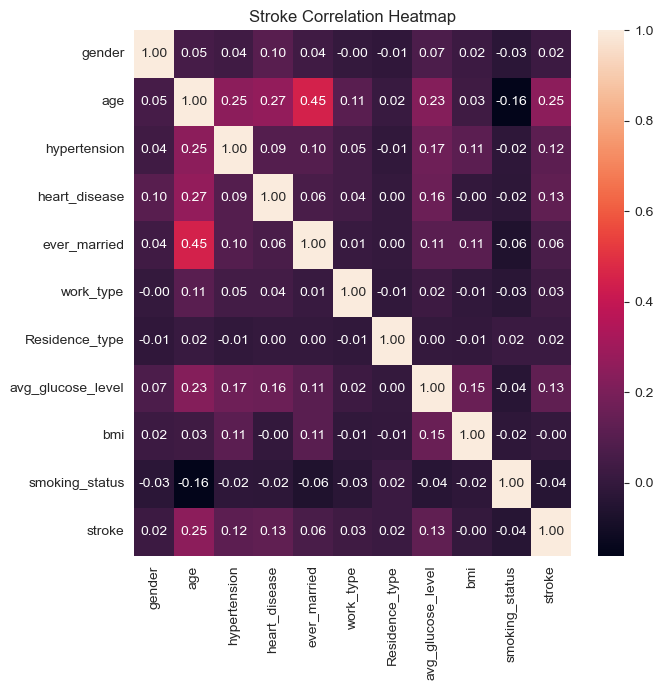

In [233]:
import seaborn as sns

plt.figure(figsize=(7,7))
cor = df.corr()
sns.heatmap(cor, annot=True, fmt='.2f')

plt.title('Stroke Correlation Heatmap')

plt.tight_layout()

plt.savefig("Original Stroke  Correlation Heatmap.svg")

plt.show()

This image shows a correlation heatmap for various factors related to stroke. The heatmap displays correlation coefficients between different variables, with values ranging from -1 to 1 (as indicated by the color bar on the right side).
Looking at the correlations with stroke (the rightmost column and bottom row):

Age has the strongest positive correlation with stroke (0.25), suggesting that older individuals have a higher likelihood of experiencing a stroke.
Other notable positive correlations with stroke include:

Average glucose level (0.13)
Hypertension (0.12)
Heart disease (0.13)
Ever married (0.06)


Smoking status shows a slight negative correlation (-0.04) with stroke, which is somewhat counterintuitive since smoking is typically considered a risk factor.
BMI shows a very weak negative correlation (-0.00) with stroke, suggesting minimal direct relationship.

Beyond stroke correlations, some interesting patterns in the data include:

Age and ever_married have a moderate positive correlation (0.45), which makes sense as older people are more likely to have been married.
Age also correlates positively with hypertension (0.25) and heart disease (0.27), reflecting the increased prevalence of these conditions in older populations.
Average glucose level shows positive correlations with age (0.23), hypertension (0.17), and heart disease (0.16), suggesting interrelationships between these health factors.
Residence type and work type show very weak correlations with most other variables, suggesting these demographic factors may have limited relationship with the health variables in this dataset.

The blue color scheme indicates the strength of correlations, with darker blue representing stronger positive correlations and lighter blue representing weaker or negative correlations.
This heatmap could be useful for identifying potential risk factors for stroke and understanding how different health and demographic variables interact with each other in relation to stroke risk.

### <span style=' color:yellow'> Correlation based Feature Selection (CFS) </span>

In [236]:
cor_with_target=cor['stroke']

cor_with_target

gender               0.021862
age                  0.250861
hypertension         0.116229
heart_disease        0.126854
ever_married         0.062278
work_type            0.031717
Residence_type       0.016209
avg_glucose_level    0.127790
bmi                 -0.001072
smoking_status      -0.039377
stroke               1.000000
Name: stroke, dtype: float64

In [237]:
k=9

top_eight_features = cor_with_target.abs().sort_values(ascending=False)[:k].index


In [238]:
top_eight_features  #residence type,bmi are dropped 

Index(['stroke', 'age', 'avg_glucose_level', 'heart_disease', 'hypertension',
       'ever_married', 'smoking_status', 'work_type', 'gender'],
      dtype='object')

In [239]:
df =df[top_eight_features]

In [240]:
df

,stroke,age,avg_glucose_level,heart_disease,hypertension,ever_married,smoking_status,work_type,gender
0,1,67,228.69,1,0,1,0,2,1
1,1,61,202.21,0,0,1,1,3,0
2,1,80,105.92,1,0,1,1,2,1
3,1,49,171.23,0,0,1,2,2,0
4,1,79,174.12,0,1,1,1,3,0
...,...,...,...,...,...,...,...,...,...
4249,0,80,83.75,0,1,1,1,2,0
4250,0,81,125.20,0,0,1,1,3,0
4251,0,35,82.99,0,0,1,1,3,0
4252,0,51,166.29,0,0,1,0,2,1


# <span style=' color:red'>FEATURE ENGINEERING</span> 

Top 8 features
 
'age', 
'avg_glucose_level',
'heart_disease',
'hypertension',
'ever_married',
'smoking_status', 
'work_type',
'gender'
      

### <span style=' color:yellow'>Polynomial transformation </span>

In [244]:
from sklearn.preprocessing import PolynomialFeatures

# Select numerical features for polynomial transformation
numerical_features = ['age', 'avg_glucose_level']

# Apply polynomial transformations
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df[numerical_features])




In [245]:
# Create a DataFrame for the polynomial features
poly_feature_names = poly.get_feature_names_out(numerical_features)
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)


In [246]:
poly_df

,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
0,67.0,228.69,4489.0,15322.23,52299.1161
1,61.0,202.21,3721.0,12334.81,40888.8841
2,80.0,105.92,6400.0,8473.60,11219.0464
3,49.0,171.23,2401.0,8390.27,29319.7129
4,79.0,174.12,6241.0,13755.48,30317.7744
...,...,...,...,...,...
4249,80.0,83.75,6400.0,6700.00,7014.0625
4250,81.0,125.20,6561.0,10141.20,15675.0400
4251,35.0,82.99,1225.0,2904.65,6887.3401
4252,51.0,166.29,2601.0,8480.79,27652.3641


In [247]:

# Drop original numerical features from the DataFrame
df_without_original_features = df[top_eight_features].drop(numerical_features,axis=1)

df_without_original_features

,stroke,heart_disease,hypertension,ever_married,smoking_status,work_type,gender
0,1,1,0,1,0,2,1
1,1,0,0,1,1,3,0
2,1,1,0,1,1,2,1
3,1,0,0,1,2,2,0
4,1,0,1,1,1,3,0
...,...,...,...,...,...,...,...
4249,0,0,1,1,1,2,0
4250,0,0,0,1,1,3,0
4251,0,0,0,1,1,3,0
4252,0,0,0,1,0,2,1


In [248]:
# Concatenate the polynomial features with the original DataFrame
df_with_poly = pd.concat([df_without_original_features, poly_df], axis=1)

In [249]:
df_with_poly 
#interaction term: age * avg_glucose_level

,stroke,heart_disease,hypertension,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
0,1,1,0,1,0,2,1,67.0,228.69,4489.0,15322.23,52299.1161
1,1,0,0,1,1,3,0,61.0,202.21,3721.0,12334.81,40888.8841
2,1,1,0,1,1,2,1,80.0,105.92,6400.0,8473.60,11219.0464
3,1,0,0,1,2,2,0,49.0,171.23,2401.0,8390.27,29319.7129
4,1,0,1,1,1,3,0,79.0,174.12,6241.0,13755.48,30317.7744
...,...,...,...,...,...,...,...,...,...,...,...,...
4249,0,0,1,1,1,2,0,80.0,83.75,6400.0,6700.00,7014.0625
4250,0,0,0,1,1,3,0,81.0,125.20,6561.0,10141.20,15675.0400
4251,0,0,0,1,1,3,0,35.0,82.99,1225.0,2904.65,6887.3401
4252,0,0,0,1,0,2,1,51.0,166.29,2601.0,8480.79,27652.3641


In [250]:
df_with_poly.isnull().any()


stroke                   False
heart_disease            False
hypertension             False
ever_married             False
smoking_status           False
work_type                False
gender                   False
age                      False
avg_glucose_level        False
age^2                    False
age avg_glucose_level    False
avg_glucose_level^2      False
dtype: bool

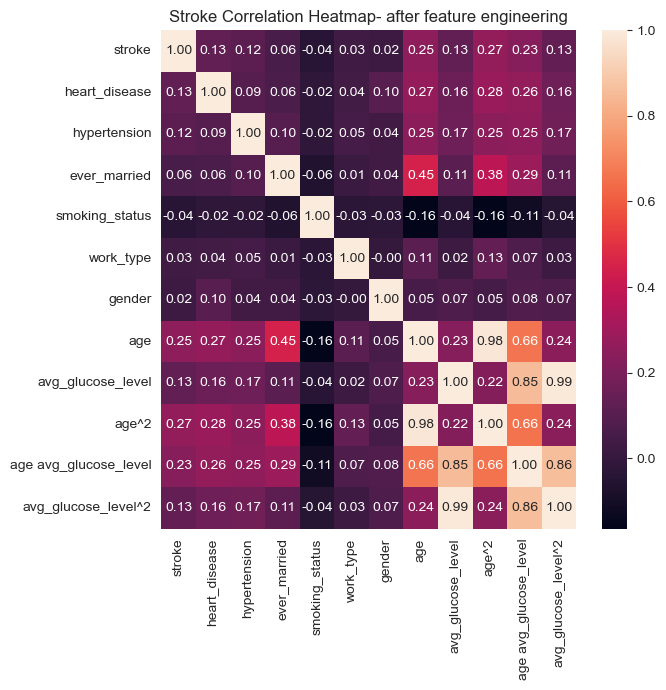

In [251]:
import seaborn as sns

plt.figure(figsize=(7,7))
cor = df_with_poly .corr()
sns.heatmap(cor, annot=True, fmt='.2f')

plt.title('Stroke Correlation Heatmap- after feature engineering')
plt.tight_layout()
plt.savefig(" Final Stroke correlatio heatmap.svg")

plt.show()

In [252]:
# Split data into features (X) and target (y)

X = df_with_poly.drop('stroke', axis=1)
y = df['stroke']



In [253]:
X

,heart_disease,hypertension,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
0,1,0,1,0,2,1,67.0,228.69,4489.0,15322.23,52299.1161
1,0,0,1,1,3,0,61.0,202.21,3721.0,12334.81,40888.8841
2,1,0,1,1,2,1,80.0,105.92,6400.0,8473.60,11219.0464
3,0,0,1,2,2,0,49.0,171.23,2401.0,8390.27,29319.7129
4,0,1,1,1,3,0,79.0,174.12,6241.0,13755.48,30317.7744
...,...,...,...,...,...,...,...,...,...,...,...
4249,0,1,1,1,2,0,80.0,83.75,6400.0,6700.00,7014.0625
4250,0,0,1,1,3,0,81.0,125.20,6561.0,10141.20,15675.0400
4251,0,0,1,1,3,0,35.0,82.99,1225.0,2904.65,6887.3401
4252,0,0,1,0,2,1,51.0,166.29,2601.0,8480.79,27652.3641


In [254]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4249    0
4250    0
4251    0
4252    0
4253    0
Name: stroke, Length: 4254, dtype: int64

In [255]:
X

,heart_disease,hypertension,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
0,1,0,1,0,2,1,67.0,228.69,4489.0,15322.23,52299.1161
1,0,0,1,1,3,0,61.0,202.21,3721.0,12334.81,40888.8841
2,1,0,1,1,2,1,80.0,105.92,6400.0,8473.60,11219.0464
3,0,0,1,2,2,0,49.0,171.23,2401.0,8390.27,29319.7129
4,0,1,1,1,3,0,79.0,174.12,6241.0,13755.48,30317.7744
...,...,...,...,...,...,...,...,...,...,...,...
4249,0,1,1,1,2,0,80.0,83.75,6400.0,6700.00,7014.0625
4250,0,0,1,1,3,0,81.0,125.20,6561.0,10141.20,15675.0400
4251,0,0,1,1,3,0,35.0,82.99,1225.0,2904.65,6887.3401
4252,0,0,1,0,2,1,51.0,166.29,2601.0,8480.79,27652.3641


In [256]:
X.shape

(4254, 11)

In [257]:
y.shape

(4254,)

In [258]:
#Splitting before SMOTE , to avoid data leakage

In [259]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [260]:
X_train.shape

(3403, 11)

In [261]:
X_test.shape

(851, 11)

In [262]:
y_train.shape

(3403,)

In [263]:
y_test.shape

(851,)

In [264]:
y.value_counts()

stroke
0    4007
1     247
Name: count, dtype: int64

In [265]:
X['gender'].value_counts()

gender
0    2577
1    1677
Name: count, dtype: int64

### <span style= "color:gold"> SMOTE </span>

Apply SMOTE to Only on training set to avoid data leakage. Do not apply it to the test set.

In [268]:
from imblearn.over_sampling import SMOTE


In [269]:
# Apply SMOTE to the selected training features
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [270]:
X_train_resampled

,heart_disease,hypertension,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
0,0,0,1,1,2,0,26.000000,73.290000,676.000000,1905.540000,5371.424100
1,0,0,1,1,2,1,38.000000,61.270000,1444.000000,2328.260000,3754.012900
2,1,0,1,0,3,1,78.000000,206.620000,6084.000000,16116.360000,42691.824400
3,0,0,1,1,2,0,74.000000,83.580000,5476.000000,6184.920000,6985.616400
4,1,0,1,1,2,0,79.000000,88.510000,6241.000000,6992.290000,7834.020100
...,...,...,...,...,...,...,...,...,...,...,...
6431,0,0,0,0,2,0,80.830003,99.218652,6533.800492,8020.047715,9844.474375
6432,0,0,1,1,2,0,73.687759,73.220721,5430.412788,5395.030823,5361.641469
6433,0,0,1,0,2,0,62.030831,203.127440,3850.884715,12602.887929,41263.181131
6434,0,0,1,1,2,0,46.342517,63.873175,2156.566643,2958.267289,4080.135515


In [271]:
y_train_resampled

0       0
1       0
2       0
3       0
4       0
       ..
6431    1
6432    1
6433    1
6434    1
6435    1
Name: stroke, Length: 6436, dtype: int64

In [272]:
X_train_resampled.shape


(6436, 11)

In [273]:
y_train_resampled.shape

(6436,)

In [274]:
y_train_resampled.value_counts()

stroke
0    3218
1    3218
Name: count, dtype: int64

In [275]:
X_train_resampled['gender'].value_counts()

gender
0    4534
1    1902
Name: count, dtype: int64

In [276]:
stroke_counts_after_smote =y_train_resampled.value_counts()
stroke_counts_after_smote

stroke
0    3218
1    3218
Name: count, dtype: int64

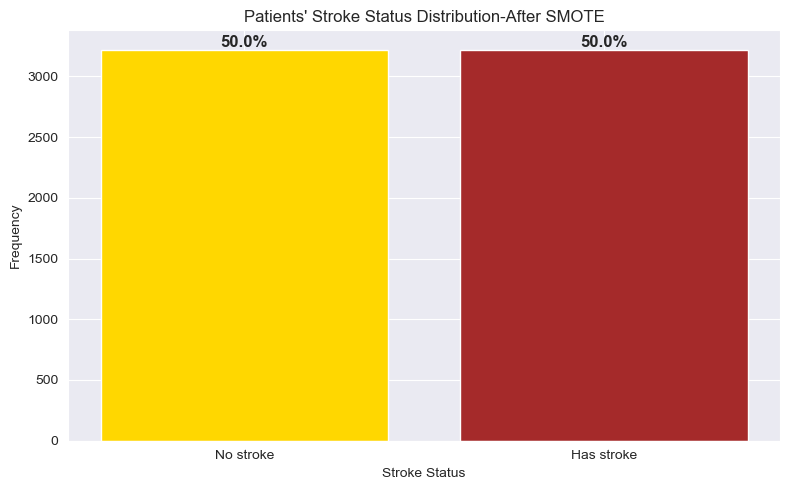

In [277]:
plt.figure(figsize=(8,5))

colors=['gold','brown']

bars=plt.bar(stroke_counts_after_smote.index,stroke_counts_after_smote,color=colors)

plt.title("Patients' Stroke Status Distribution-After SMOTE")
plt.xlabel('Stroke Status')
plt.ylabel('Frequency')

plt.xticks([0,1],labels=['No stroke','Has stroke'])





total_count = stroke_counts_after_smote.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(stroke_counts_after_smote.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

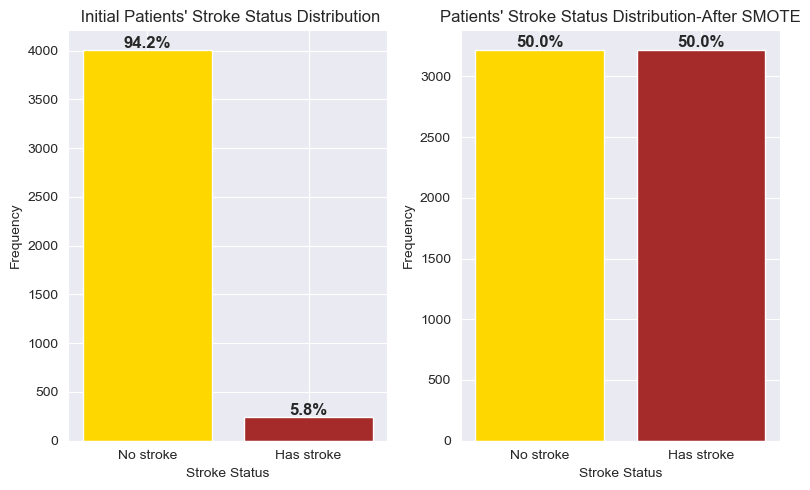

In [278]:
plt.figure(figsize=(8,5))

plt.subplot(1,2,1)
colors=['gold','brown']

bars=plt.bar(stroke_counts.index,stroke_counts,color=colors)

plt.title(" Initial Patients' Stroke Status Distribution")
plt.xlabel('Stroke Status')
plt.ylabel('Frequency')
plt.xticks([0,1],labels=['No stroke','Has stroke'])


total_count = stroke_counts.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(stroke_counts.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')
    

plt.subplot(1,2,2)


bars=plt.bar(stroke_counts_after_smote.index,stroke_counts_after_smote,color=colors)

plt.title("Patients' Stroke Status Distribution-After SMOTE")
plt.xlabel('Stroke Status')
plt.ylabel('Frequency')

plt.xticks([0,1],labels=['No stroke','Has stroke'])





total_count = stroke_counts_after_smote.sum()

# Add percentage labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,  
             height + 20,  
             f"{(stroke_counts_after_smote.iloc[i] / total_count) * 100:.1f}%",  
             ha='center', fontsize=12, fontweight='bold')

plt.savefig("Stroke- before and after SMOTE.svg")
plt.tight_layout()
plt.show()

In [279]:
X_test

,heart_disease,hypertension,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
184,0,0,1,0,2,1,63.0,137.30,3969.0,8649.90,18851.2900
1018,0,0,1,1,2,0,46.0,218.65,2116.0,10057.90,47807.8225
2507,0,0,1,2,2,0,39.0,102.51,1521.0,3997.89,10508.3001
3502,0,0,1,1,2,1,51.0,232.64,2601.0,11864.64,54121.3696
602,0,0,1,1,2,1,56.0,81.18,3136.0,4546.08,6590.1924
...,...,...,...,...,...,...,...,...,...,...,...
6,1,1,1,1,2,1,74.0,70.09,5476.0,5186.66,4912.6081
3685,0,0,1,1,2,1,73.0,101.58,5329.0,7415.34,10318.4964
439,0,0,0,1,2,1,25.0,96.17,625.0,2404.25,9248.6689
289,0,0,1,1,3,0,53.0,81.51,2809.0,4320.03,6643.8801


In [280]:
y_test

184     1
1018    0
2507    0
3502    0
602     0
       ..
6       1
3685    0
439     0
289     0
1255    0
Name: stroke, Length: 851, dtype: int64




## <span style=' color:red'>MODEL DEVP'T</span>

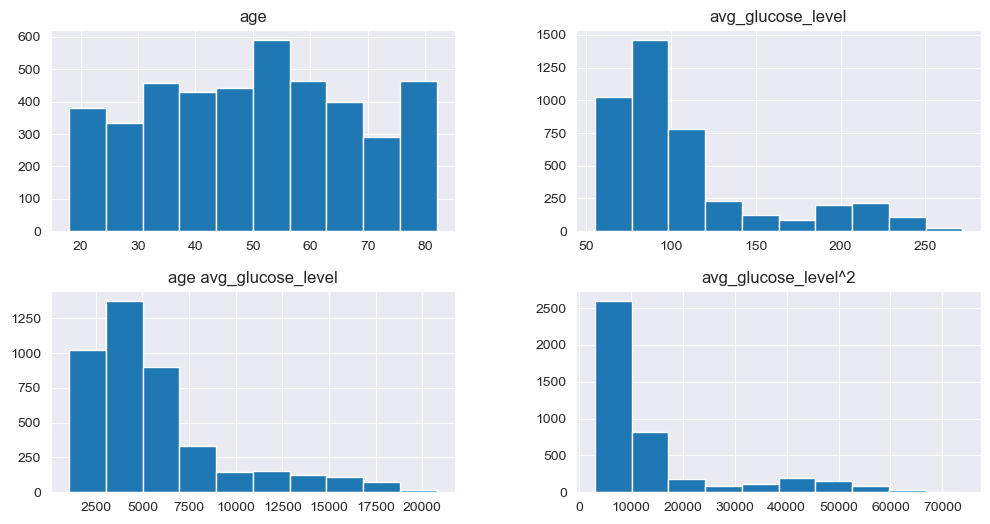

In [282]:
# Check feature distributions


features_to_check=["age","avg_glucose_level",	"age avg_glucose_level",	"avg_glucose_level^2" ]

df_with_poly[features_to_check].hist(figsize=(12, 6))
plt.savefig("non-normalized data.svg")

plt.show() 



In [283]:


from sklearn.preprocessing import PowerTransformer #vs log transformer

# Selecting features that need transformation
features_to_transform = ["age","avg_glucose_level",	"age avg_glucose_level",	"avg_glucose_level^2" ]

# Apply PowerTransformer (Yeo-Johnson)

pt = PowerTransformer(method='yeo-johnson')
df_with_poly[features_to_transform] = pt.fit_transform(df_with_poly[features_to_transform])



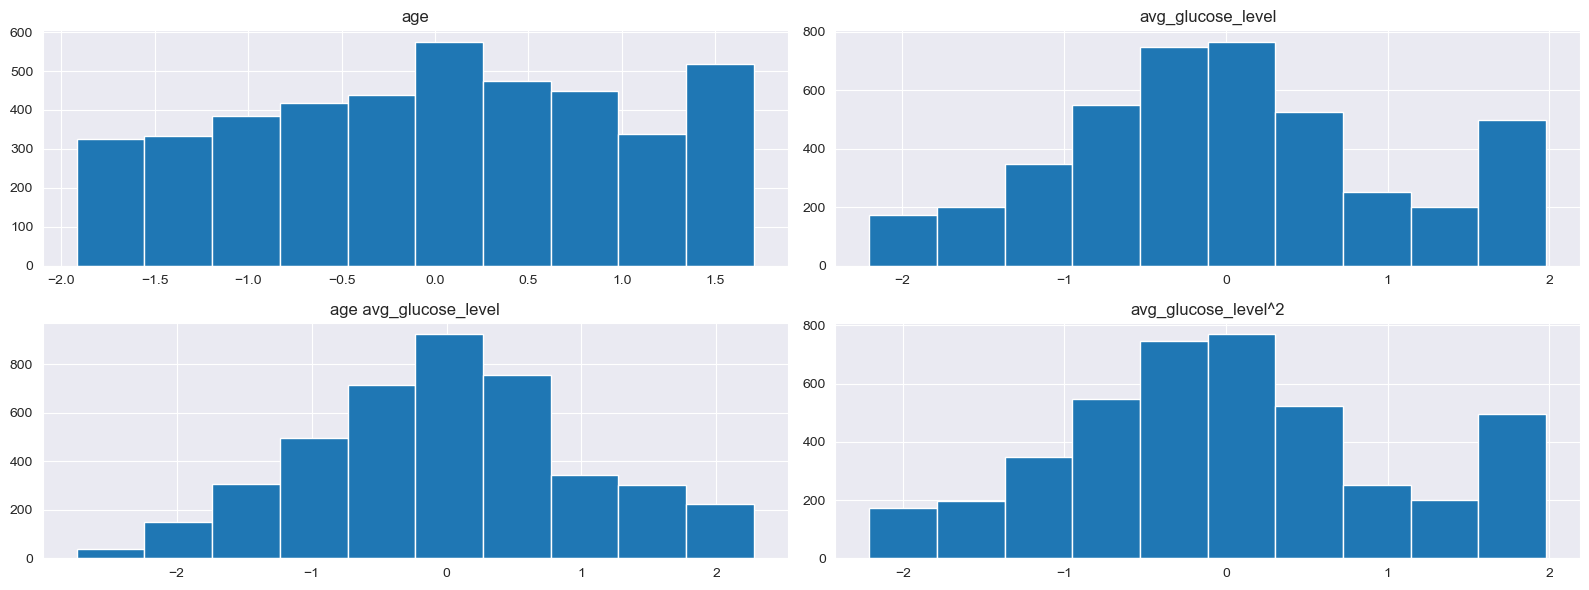

In [284]:

df_with_poly[features_to_transform].hist(figsize=(16, 6))

plt.tight_layout() 
plt.savefig("normalized data.svg")
plt.show()

In [285]:
#Noamlization scales the continous features on a scale of 0-1 or -1 to 1.
#Normlization is used on models that assume a normal/Gaussian ditribution,meaning data that s not already normannly distributed


#Logistic Regression assumes a normal distribution so i have to normalize the data and apply standardization next


from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test sets
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)



In [286]:
X_train

,heart_disease,hypertension,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
4184,0,0,1,1,2,0,26.0,73.29,676.0,1905.54,5371.4241
1123,0,0,1,1,2,1,38.0,61.27,1444.0,2328.26,3754.0129
3061,1,0,1,0,3,1,78.0,206.62,6084.0,16116.36,42691.8244
2609,0,0,1,1,2,0,74.0,83.58,5476.0,6184.92,6985.6164
4166,1,0,1,1,2,0,79.0,88.51,6241.0,6992.29,7834.0201
...,...,...,...,...,...,...,...,...,...,...,...
3444,0,0,1,1,3,1,66.0,55.23,4356.0,3645.18,3050.3529
466,0,0,1,1,2,1,64.0,97.08,4096.0,6213.12,9424.5264
3092,0,1,1,1,2,0,80.0,89.16,6400.0,7132.80,7949.5056
3772,0,0,1,2,2,0,32.0,92.75,1024.0,2968.00,8602.5625


In [287]:
X_train_resampled

,heart_disease,hypertension,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,age^2,age avg_glucose_level,avg_glucose_level^2
0,0,0,1,1,2,0,26.000000,73.290000,676.000000,1905.540000,5371.424100
1,0,0,1,1,2,1,38.000000,61.270000,1444.000000,2328.260000,3754.012900
2,1,0,1,0,3,1,78.000000,206.620000,6084.000000,16116.360000,42691.824400
3,0,0,1,1,2,0,74.000000,83.580000,5476.000000,6184.920000,6985.616400
4,1,0,1,1,2,0,79.000000,88.510000,6241.000000,6992.290000,7834.020100
...,...,...,...,...,...,...,...,...,...,...,...
6431,0,0,0,0,2,0,80.830003,99.218652,6533.800492,8020.047715,9844.474375
6432,0,0,1,1,2,0,73.687759,73.220721,5430.412788,5395.030823,5361.641469
6433,0,0,1,0,2,0,62.030831,203.127440,3850.884715,12602.887929,41263.181131
6434,0,0,1,1,2,0,46.342517,63.873175,2156.566643,2958.267289,4080.135515


In [288]:
X_train_scaled

array([[-0.23944792, -0.31202116,  0.53759149, ..., -1.61500838,
        -1.21952385, -0.71939079],
       [-0.23944792, -0.31202116,  0.53759149, ..., -1.21259996,
        -1.12077744, -0.82132612],
       [ 4.17627355, -0.31202116,  0.53759149, ...,  1.21861756,
         2.1000907 ,  1.63268116],
       ...,
       [-0.23944792, -0.31202116,  0.53759149, ...,  0.04853372,
         1.27935178,  1.54264269],
       [-0.23944792, -0.31202116,  0.53759149, ..., -0.83923692,
        -0.9736092 , -0.80077265],
       [-0.23944792, -0.31202116,  0.53759149, ..., -1.12886436,
        -0.88269849, -0.61645645]])

In [289]:
X_test.shape

(851, 11)

In [290]:
X_test_scaled.shape

(851, 11)

In [291]:
y_train.shape

(3403,)

In [292]:
y_train_resampled.shape

(6436,)

In [293]:
y_test.shape

(851,)

### <span style=' color:orange'>Logistic Regression</span>

In [548]:
X_train, X_test, y_train, y_test = train_test_split(X_train_scaled, y_train_resampled, test_size=0.2, random_state=42)

In [550]:
print(X_train_scaled.shape)

print(y_train_resampled.shape)

(6436, 11)
(6436,)


In [552]:
print(X_test.shape)

print(y_test.shape)

(1288, 11)
(1288,)


In [554]:
print(X_train.shape)

print(y_train.shape)

(5148, 11)
(5148,)


In [556]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score




In [558]:
log_reg = LogisticRegression(random_state=42)


log_reg.fit(X_train, y_train)



LogisticRegression(random_state=42)

In [559]:

y_pred =log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]  # Probabilities for AUC-ROC


In [562]:
# Evaluate model
print("\nLogistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Evaluation:
Accuracy: 0.7546583850931677
AUC-ROC Score: 0.8514613227496642
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.71      0.74       647
           1       0.73      0.80      0.77       641

    accuracy                           0.75      1288
   macro avg       0.76      0.75      0.75      1288
weighted avg       0.76      0.75      0.75      1288



###  <span style=' color:orange'> Hypertuning Logistic Regression</span>

In [565]:
from sklearn.model_selection import RandomizedSearchCV #GridSearch was taking too long

In [567]:

# Define parameter grid with compatible combinations
param_dist_logreg = [
    # For elasticnet penalty (requires saga solver and l1_ratio)
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # Add l1_ratio for elasticnet
    },
    # For l1 penalty with saga
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver': ['saga']
    },
    # For l2 penalty with saga
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['saga']
    },
    # For no penalty
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': [None],
        'solver': ['saga']
    },
    # For l1 and l2 with liblinear
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
]

# Initialize Logistic Regression model
logreg = LogisticRegression(random_state=42, max_iter=10000)

# Perform Randomized Search
random_search_logreg = RandomizedSearchCV(
    logreg, 
    param_distributions=param_dist_logreg,
    n_iter=10, 
    cv=5, 
    verbose=2, 
    n_jobs=-1
)

# Fit model
random_search_logreg.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=10000,
                                                random_state=42),
                   n_jobs=-1,
                   param_distributions=[{'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
                                         'penalty': ['elasticnet'],
                                         'solver': ['saga']},
                                        {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                         'penalty': ['l1'],
                                         'solver': ['saga']},
                                        {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                         'penalty': ['l2'],
                                         'solver': ['saga']},
                                        {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                         'penalty': [None],
                                         'solver': ['saga']},
                                        {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                         'penalty': ['l1', 'l2'],
                                         'solver': ['liblinear']}],
                   verbose=2)

In [568]:
# Get best model
best_logreg = random_search_logreg.best_estimator_

# Predictions
y_pred_logreg = best_logreg.predict(X_test)
y_proba_logreg = best_logreg.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_logreg))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.7538819875776398
AUC-ROC Score: 0.8514299768281303
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.70      0.74       647
           1       0.73      0.81      0.77       641

    accuracy                           0.75      1288
   macro avg       0.76      0.75      0.75      1288
weighted avg       0.76      0.75      0.75      1288



## <span style=' color:orange'>Random Forest Classifier</span>

In [572]:
from sklearn.ensemble import RandomForestClassifier # random Forest doesn't assume normal data distribution  so no stadardization is needed
 #No scaling is not necessary for random forests, (2)
#Random Forest is a tree-based model and hence does not require feature scaling.

In [574]:
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

In [576]:
rf = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [577]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]  # Probabilities for AUC-ROC

In [578]:
print("\nRandom Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Evaluation:
Accuracy: 0.9208074534161491
AUC-ROC Score: 0.9802315740233938
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       647
           1       0.90      0.94      0.92       641

    accuracy                           0.92      1288
   macro avg       0.92      0.92      0.92      1288
weighted avg       0.92      0.92      0.92      1288



###  <span style=' color:orange'> Hypertuning Random Forest</span>

In [580]:
from sklearn.model_selection import RandomizedSearchCV #GridSearch was taking too long

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search.fit(X_train, y_train)



Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   verbose=2)

In [581]:
random_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 20}

In [582]:
best_rf = random_search.best_estimator_


In [583]:


y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print("Final Model Accuracy:", accuracy)
print("AUC-ROC Score:", auc_roc)
print("Classification Report:\n", classification_report(y_test, y_pred))


Final Model Accuracy: 0.9239130434782609
AUC-ROC Score: 0.9807909781615376
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       647
           1       0.91      0.95      0.93       641

    accuracy                           0.92      1288
   macro avg       0.92      0.92      0.92      1288
weighted avg       0.92      0.92      0.92      1288



## <span style=' color:orange'>Support Vector Machine</span>

In [585]:
from sklearn.svm import SVC #needs scaled data

In [586]:
X_train, X_test, y_train, y_test = train_test_split(X_train_scaled, y_train_resampled, test_size=0.2, random_state=42)

In [587]:
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train, y_train)


SVC(probability=True, random_state=42)

In [591]:
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]


In [592]:
# Evaluate performance
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7966
AUC-ROC Score: 0.8886737540598997
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       647
           1       0.77      0.84      0.80       641

    accuracy                           0.80      1288
   macro avg       0.80      0.80      0.80      1288
weighted avg       0.80      0.80      0.80      1288



###   <span style=' color:orange'> Hypertuning SVM </span>

In [594]:
# # Define hyperparameter grid for SVM
# param_dist_svm = {
#     'C': [0.1, 1, 10, 100],  # Regularization parameter
#     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],  # Kernel types
#     # 'gamma': ['scale', 'auto']  # Kernel coefficient
# }

# # Initialize the SVM model
# svm = SVC(probability=True,random_state=42 )

# # Perform RandomizedSearchCV
# random_search_svm = RandomizedSearchCV(svm, param_distributions=param_dist_svm, 
#                                        n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search_svm.fit(X_train, y_train)

# # Print best parameters
# print("Best Parameters for SVM:", random_search_svm.best_params_)

#The above code took ages to run!! More than an hour!!!



from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

# Define a reduced hyperparameter grid
param_dist_svm = {
    'C': [0.1, 1, 10],  # Smaller search space
    'kernel': ['linear', 'rbf', 'poly'],  # Removed 'sigmoid'

}

# Initialize the SVM model (without probability to speed up)
svm = SVC(probability=True,random_state=42)

# Perform faster RandomizedSearchCV
random_search_svm = RandomizedSearchCV(
    svm,
    param_distributions=param_dist_svm,
    n_iter=6,  #
    cv=5,      
    verbose=1,
    n_jobs=-1
)

random_search_svm.fit(X_train, y_train)

# Print best parameters
print("Best Parameters for SVM:", random_search_svm.best_params_)



Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters for SVM: {'kernel': 'rbf', 'C': 1}


In [595]:
# Evaluate the tuned model
best_svm = random_search_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]





print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_svm))

print("Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.796583850931677
AUC-ROC Score: 0.8886737540598997
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79       647
           1       0.77      0.84      0.80       641

    accuracy                           0.80      1288
   macro avg       0.80      0.80      0.80      1288
weighted avg       0.80      0.80      0.80      1288



### <span style=' color:orange'> XGBoost</span>

In [597]:
!pip install xgboost


In [598]:
from xgboost import XGBClassifier

In [599]:
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

# Initialize XGBoost model
xgb_model = XGBClassifier(
    random_state=42,  
    eval_metric='logloss', 
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5
)


In [600]:
# Fit the model
xgb_model.fit(X_train, y_train)




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [601]:
# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]



In [602]:
# Evaluate performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_roc_xgb = roc_auc_score(y_test, y_proba_xgb)
classification_rep_xgb = classification_report(y_test, y_pred_xgb)



In [603]:
print("XGBoost Model Evaluation:")
print("Accuracy:", accuracy_xgb)
print("AUC-ROC Score:", auc_roc_xgb)
print("Classification Report:\n", classification_rep_xgb)

XGBoost Model Evaluation:
Accuracy: 0.8866459627329193
AUC-ROC Score: 0.9540034769860657
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.84      0.88       647
           1       0.85      0.93      0.89       641

    accuracy                           0.89      1288
   macro avg       0.89      0.89      0.89      1288
weighted avg       0.89      0.89      0.89      1288



### <span style=' color:orange'> Hypertuning XGBoost</span>

In [605]:

from sklearn.model_selection import RandomizedSearchCV

# Initialize XGBoost model
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Define parameter grid for XGBoost model
param_dist_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# Perform Randomized Search for XGBoost model
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=10,  # Number of parameter settings sampled
    scoring='roc_auc',  # Use AUC-ROC as the scoring metric
    cv=5,  # 5-fold cross-validation
    verbose=2,
    n_jobs=-1,  # Use all available CPU cores
    random_state=42
)

# Fit the model
random_search_xgb.fit(X_train, y_train)

# Print best parameters and score
print("Best Parameters:", random_search_xgb.best_params_)
print("Best AUC-ROC Score:", random_search_xgb.best_score_)

# Evaluate the best model
best_xgb_model = random_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test)
y_proba_best_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Evaluate performance
accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
print(f"Best XGBoost Model Accuracy: {accuracy_best_xgb:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_best_xgb))

print(classification_report(y_test, y_pred_best_xgb))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.3, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best AUC-ROC Score: 0.9820340767285579
Best XGBoost Model Accuracy: 0.9317
AUC-ROC Score: 0.9843306560701377
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       647
           1       0.92      0.94      0.93       641

    accuracy                           0.93      1288
   macro avg       0.93      0.93      0.93      1288
weighted avg       0.93      0.93      0.93      1288



## <span style=' color:orange'> K-Nearest Neighbors (KNN)</span>

In [607]:

from sklearn.neighbors import KNeighborsClassifier #scaling the data is an important preprocessing step for the KNN algorithm 
#because the algorithm is distance-base

In [608]:
X_train, X_test, y_train, y_test = train_test_split(X_train_scaled, y_train_resampled, test_size=0.2, random_state=42)

In [609]:
knn = KNeighborsClassifier(n_neighbors=7) # (without feature engineering but with CSF)
#1 gave 0.8495 accuracy and 0.8509 AUC
# 3 gave 0.8576 and 0.9043
#5 gave 0.8401 and 0.9136
#7 gave 0.8401 and 0,9154
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [610]:
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

In [611]:
# Evaluate performance
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8564
AUC-ROC Score: 0.9258246991394339
              precision    recall  f1-score   support

           0       0.92      0.78      0.84       647
           1       0.81      0.94      0.87       641

    accuracy                           0.86      1288
   macro avg       0.87      0.86      0.86      1288
weighted avg       0.87      0.86      0.86      1288



### <span style=' color:orange'> Hypertuning KNN</span>

In [613]:


# Define hyperparameter grid for KNN
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],  # Number of neighbors
    'weights': ['uniform', 'distance'],   # Weight function
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Distance metric
}

# Initialize the KNN model
knn = KNeighborsClassifier()

# Perform RandomizedSearchCV
random_search_knn = RandomizedSearchCV(knn, param_distributions=param_dist_knn, 
                                       n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search_knn.fit(X_train, y_train)

# Print best parameters
print("Best Parameters for KNN:", random_search_knn.best_params_)




Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for KNN: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}


In [614]:
# Evaluate the tuned model
best_knn = random_search_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)
y_proba_knn = best_knn.predict_proba(X_test)[:, 1]

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8858695652173914
AUC-ROC Score: 0.9373527645897181
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.83      0.88       647
           1       0.85      0.94      0.89       641

    accuracy                           0.89      1288
   macro avg       0.89      0.89      0.89      1288
weighted avg       0.89      0.89      0.89      1288




## <span style=' color:orange'> Decision Tree Classifier</span>



In [616]:
from sklearn.tree import DecisionTreeClassifier

In [617]:
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

In [618]:
dt=DecisionTreeClassifier( min_samples_split=10, min_samples_leaf=5,random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [619]:
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

In [620]:
# Evaluate performance
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_dt))

print(classification_report(y_test, y_pred_dt)) 

Decision Tree Accuracy: 0.8742
AUC-ROC Score: 0.9201836388756941
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       647
           1       0.85      0.90      0.88       641

    accuracy                           0.87      1288
   macro avg       0.88      0.87      0.87      1288
weighted avg       0.88      0.87      0.87      1288



### <span style=' color:orange'> Hypertuning dt</span>

In [622]:

# Define the hyperparameter grid for Decision Tree
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Perform RandomizedSearchCV
random_search_dt = RandomizedSearchCV(dt, param_distributions=param_dist_dt, 
                                      n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search_dt.fit(X_train, y_train)

# Print best parameters
print("Best Parameters for Decision Tree:", random_search_dt.best_params_)

# Evaluate the tuned model
best_dt = random_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)




Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for Decision Tree: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}


In [623]:

# Evaluate the tuned model
best_dt = random_search_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))



DT Accuracy: 0.8920807453416149
AUC-ROC Score: 0.8922122263561331
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89       647
           1       0.87      0.92      0.89       641

    accuracy                           0.89      1288
   macro avg       0.89      0.89      0.89      1288
weighted avg       0.89      0.89      0.89      1288



### <span style=' color:orange'> Gradient Boosting</span>


In [625]:
from sklearn.ensemble import GradientBoostingClassifier




In [626]:
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

In [627]:
# Train a Gradient Boosting model
gb = GradientBoostingClassifier(
    n_estimators=100,  # Number of boosting stages
    learning_rate=0.1,  # Learning rate for each stage
    max_depth=5,  # Maximum depth of each decision tree
    min_samples_split=10,  # Minimum samples required to split an internal node
    min_samples_leaf=5,  # Minimum samples required to be at a leaf node
    random_state=42
)

gb.fit(X_train, y_train)


GradientBoostingClassifier(max_depth=5, min_samples_leaf=5,
                           min_samples_split=10, random_state=42)

In [628]:
# Predict on the test set
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]




In [629]:
# Evaluate performance
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_gb))

print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9053
AUC-ROC Score: 0.9659788246243916
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       647
           1       0.88      0.94      0.91       641

    accuracy                           0.91      1288
   macro avg       0.91      0.91      0.91      1288
weighted avg       0.91      0.91      0.91      1288



 ###  <span style=' color:orange'> Hypertuning gb</span>

In [631]:

# Define hyperparameter distribution
param_distributions = {
    'n_estimators': np.arange(50, 250, 50),  # Range of number of estimators
    'learning_rate': [0.01, 0.05, 0.1, 0.5],  # Range of learning rates
    'max_depth': np.arange(3, 8),  # Range of maximum depths
    'min_samples_split': np.arange(5, 15),  # Range of minimum samples to split
    'min_samples_leaf': np.arange(5, 15)  # Range of minimum samples per leaf
}




In [632]:
# Perform random search
random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_distributions,
    cv=5,
    n_iter=10,  
    scoring='roc_auc',
    random_state=42
)



In [633]:
random_search_gb.fit(X_train, y_train)



RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.5],
                                        'max_depth': array([3, 4, 5, 6, 7]),
                                        'min_samples_leaf': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                                        'min_samples_split': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                                        'n_estimators': array([ 50, 100, 150, 200])},
                   random_state=42, scoring='roc_auc')

In [634]:
# Print best parameters and score
print("Best Parameters:", random_search_gb.best_params_)
print("Best AUC-ROC Score:", random_search_gb.best_score_)



Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 7, 'learning_rate': 0.5}
Best AUC-ROC Score: 0.9880741786673217


In [635]:
# Train a new model with the best parameters
best_gb = random_search_gb.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)
y_proba_best_gb = best_gb.predict_proba(X_test)[:, 1]




In [636]:
# Evaluate the best model
accuracy_best_gb = accuracy_score(y_test, y_pred_best_gb)
print(f"Best Gradient Boosting Accuracy: {accuracy_best_gb:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_best_gb))
print(classification_report(y_test, y_pred_best_gb))


Best Gradient Boosting Accuracy: 0.9464
AUC-ROC Score: 0.9889855254179254
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       647
           1       0.94      0.96      0.95       641

    accuracy                           0.95      1288
   macro avg       0.95      0.95      0.95      1288
weighted avg       0.95      0.95      0.95      1288



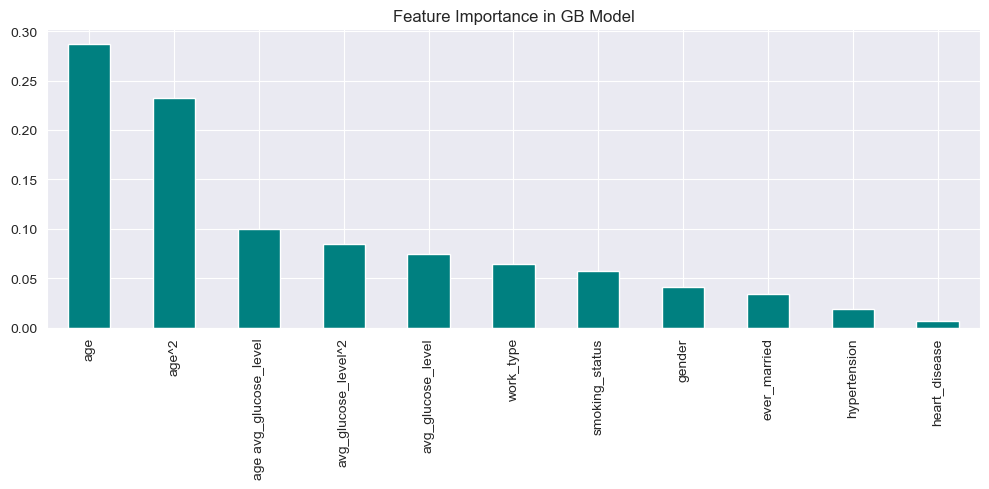

In [896]:
feature_importances = pd.Series(best_gb.feature_importances_, index=X_train.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), color='teal')
plt.title("Feature Importance in GB Model")
plt.tight_layout()
plt.savefig("Feature Importance in GB Model.svg")
plt.show()

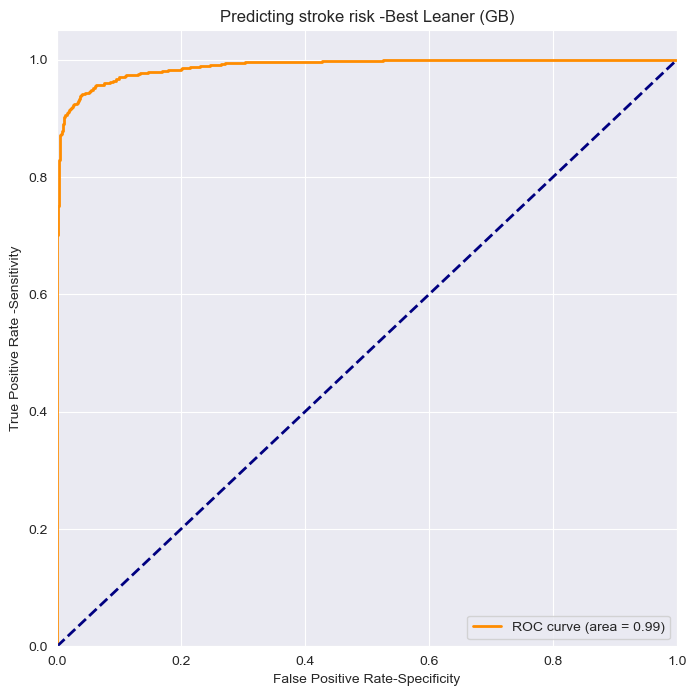

In [904]:
 #ROC CURVE
from sklearn.metrics import roc_curve, auc


# Compute area under the curve

fpr, tpr, _ = roc_curve(y_test, y_proba_best_gb)
roc_auc = auc(fpr, tpr)

#Set default figure size
plt.rcParams['figure.figsize'] = (8,8)

# Plot ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate-Specificity')
plt.ylabel('True Positive Rate -Sensitivity')
plt.title("Predicting stroke risk -Best Leaner (GB)")
plt.legend(loc="lower right")

plt.savefig("ROC Curve -GB.svg")
plt.show()


### <span style=' color:orange'>Quadratic Dicriminant ANalysis (QDA)</span>


In [640]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis




In [641]:
X_train, X_test, y_train, y_test = train_test_split(X_train_scaled, y_train_resampled, test_size=0.2, random_state=42)



In [642]:
# Train a QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)



QuadraticDiscriminantAnalysis()

In [643]:
# Predict on the test set
y_pred_qda = qda.predict(X_test)
y_proba_qda = qda.predict_proba(X_test)[:, 1]



In [644]:
# Evaluate performance
accuracy_qda = accuracy_score(y_test, y_pred_qda)
print(f"QDA Accuracy: {accuracy_qda:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_qda))

print(classification_report(y_test, y_pred_qda))

QDA Accuracy: 0.7477
AUC-ROC Score: 0.8514106870302632
              precision    recall  f1-score   support

           0       0.80      0.66      0.72       647
           1       0.71      0.84      0.77       641

    accuracy                           0.75      1288
   macro avg       0.76      0.75      0.75      1288
weighted avg       0.76      0.75      0.75      1288



###  <span style=' color:orange'> Hypertuning QDA</span>

In [646]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter distribution
param_distributions = {
    'reg_param': [0.0, 0.01, 0.1, 0.5]  # Regularization parameter
}

# Perform random search
random_search_qda = RandomizedSearchCV(
    estimator=QuadraticDiscriminantAnalysis(),
    param_distributions=param_distributions,
    cv=5,
    n_iter=5,  # Number of random combinations to try
    scoring='roc_auc',
    random_state=42
)

random_search_qda.fit(X_train, y_train)

# Print best parameters and score
print("Best Parameters:", random_search_qda.best_params_)
print("Best AUC-ROC Score:", random_search_qda.best_score_)

# Train a new model with the best parameters
best_qda = random_search_qda.best_estimator_
y_pred_best_qda = best_qda.predict(X_test)
y_proba_best_qda = best_qda.predict_proba(X_test)[:, 1]

# Evaluate the best model
accuracy_best_qda = accuracy_score(y_test, y_pred_best_qda)
print(f"Best QDA Accuracy: {accuracy_best_qda:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_best_qda))

print(classification_report(y_test, y_pred_best_qda))


D:\ANACONDA\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'reg_param': 0.01}
Best AUC-ROC Score: 0.8805752940753241
Best QDA Accuracy: 0.7601
AUC-ROC Score: 0.8536603597065058
              precision    recall  f1-score   support

           0       0.80      0.70      0.75       647
           1       0.73      0.82      0.77       641

    accuracy                           0.76      1288
   macro avg       0.76      0.76      0.76      1288
weighted avg       0.76      0.76      0.76      1288



### <span style=' color:orange'>Extra Trees</span>


In [648]:
from sklearn.ensemble import ExtraTreesClassifier
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)




In [649]:
# Train an Extra Trees Classifier model
etc = ExtraTreesClassifier(random_state=42)
etc.fit(X_train, y_train)




ExtraTreesClassifier(random_state=42)

In [650]:
# Predict on the test set
y_pred_etc = etc.predict(X_test)
y_proba_etc = etc.predict_proba(X_test)[:, 1]



In [651]:
# Evaluate performance
accuracy_etc = accuracy_score(y_test, y_pred_etc)
print(f"Extra Trees Classifier Accuracy: {accuracy_etc:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_etc))

print(classification_report(y_test, y_pred_etc))

Extra Trees Classifier Accuracy: 0.9208
AUC-ROC Score: 0.978763138160766
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       647
           1       0.90      0.94      0.92       641

    accuracy                           0.92      1288
   macro avg       0.92      0.92      0.92      1288
weighted avg       0.92      0.92      0.92      1288



###  <span style=' color:orange'> Hypertuning ETC</span>

In [653]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter distribution
param_distributions = {
    'n_estimators': [50, 100, 200, 500],  # Number of trees in the ensemble
    'criterion': ['gini', 'entropy', 'log_loss'],  # Criterion for splitting
    'max_depth': [None, 5, 10],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 5, 10],  # Minimum samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'],  # Maximum features to consider at each split
}



In [654]:
# Perform random search
random_search_etc = RandomizedSearchCV(
    estimator=ExtraTreesClassifier(random_state=42),
    param_distributions=param_distributions,
    cv=5,
    n_iter=10,  # Number of random combinations to try
    scoring='roc_auc',
    random_state=42
)

random_search_etc.fit(X_train, y_train)



RandomizedSearchCV(cv=5, estimator=ExtraTreesClassifier(random_state=42),
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [None, 5, 10],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 5, 10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 500]},
                   random_state=42, scoring='roc_auc')

In [655]:
# Print best parameters and score
print("Best Parameters:", random_search_etc.best_params_)
print("Best AUC-ROC Score:", random_search_etc.best_score_)



Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
Best AUC-ROC Score: 0.976104418452229


In [656]:
# Train a new model with the best parameters
best_etc = random_search_etc.best_estimator_
y_pred_best_etc = best_etc.predict(X_test)
y_proba_best_etc = best_etc.predict_proba(X_test)[:, 1]




In [657]:
# Evaluate the best model
accuracy_best_etc = accuracy_score(y_test, y_pred_best_etc)
print(f"Best Extra Trees Classifier Accuracy: {accuracy_best_etc:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_best_etc))

print(classification_report(y_test, y_pred_best_etc))

Best Extra Trees Classifier Accuracy: 0.9216
AUC-ROC Score: 0.975354872000135
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       647
           1       0.91      0.94      0.92       641

    accuracy                           0.92      1288
   macro avg       0.92      0.92      0.92      1288
weighted avg       0.92      0.92      0.92      1288



  ###  <span style=' color:orange'>  Cross validations for all 9 models</span>

In [720]:
from sklearn.model_selection import cross_val_score

In [722]:
#Decision Tree


# Perform 5-fold cross-validation
cv_scores = cross_val_score(best_dt, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


Cross-validation accuracy: 0.8988 ± 0.0099


In [724]:
#XGBoost


# Perform 5-fold cross-validation
cv_scores = cross_val_score(best_xgb_model, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Cross-validation accuracy: 0.9345 ± 0.0091


In [726]:
#Logistic Regression

cv_scores = cross_val_score(best_logreg, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


Cross-validation accuracy: 0.7224 ± 0.0132


In [727]:
#SVM
cv_scores = cross_val_score(best_svm, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


Cross-validation accuracy: 0.7317 ± 0.0136


In [728]:
#KNN
cv_scores = cross_val_score(best_knn, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


Cross-validation accuracy: 0.8458 ± 0.0073


In [729]:
#rRandom Forest
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


Cross-validation accuracy: 0.9254 ± 0.0127


In [730]:
#Gradient Boosting
cv_scores = cross_val_score(best_gb, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Cross-validation accuracy: 0.9501 ± 0.0108


In [731]:
#QDA
cv_scores = cross_val_score(best_qda, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Cross-validation accuracy: 0.7885 ± 0.0109


In [732]:
#Extra Trees
cv_scores = cross_val_score(best_etc, X_train, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Cross-validation accuracy: 0.9242 ± 0.0116


# <span style=' color:orange'>  BASE LEARNERS GRAPHS</span>

In [741]:
model_metrics = {
    "models": ["Logistic Regression", "Random Forest", "SVM", "KNN", "Decision Tree", "XGBoost", "Gradient Boosting", "QDA", "Extra Trees"],

    "no_feature_engineering": {
        "before_tuning": {
            "accuracy": {
                "Logistic Regression": 0.7379,
                "Random Forest": 0.8565,
                "SVM": 0.7535,
                "KNN": 0.8401,
                "Decision Tree": 0.8292
            },
            "auc_roc": {
                "Logistic Regression": 0.8358,
                "Random Forest": 0.9398,
                "SVM": 0.8356,
                "KNN": 0.9155,
                "Decision Tree": 0.8958
            }
        },
        "after_tuning": { 
             "accuracy": {
                "Logistic Regression": 0.7387,
                "Random Forest": 0.8603,
                "SVM": 0.7613,
                "KNN": 0.8424,
                "Decision Tree": 0.8333
            },
            "auc_roc": {
                "Logistic Regression": 0.8359,
                "Random Forest": 0.93910,
                "SVM": 0.8392,
                "KNN": 0.9327,
                "Decision Tree": 0.8572
            }
        }
    },


    "with_feature_engineering": {
        "before_tuning": {
            "accuracy": {
                "Logistic Regression": 0.7547,
                "Random Forest": 0.9208,
                "SVM": 0.7966,
                "KNN": 0.8564,
                "Decision Tree": 0.8742,
                "XGBoost": 0.8866,
                "Gradient Boosting": 0.9053,
                "QDA": 0.7477,
                "Extra Trees": 0.9208
            },
            "auc_roc": {
                "Logistic Regression": 0.8515,
                "Random Forest": 0.9802,
                "SVM": 0.8887,
                "KNN": 0.9258,
                "Decision Tree": 0.9202,
                "XGBoost": 0.9540,
                "Gradient Boosting": 0.9660,
                "QDA": 0.8514,
                "Extra Trees": 0.9788
            },
            "precision": {
                "Logistic Regression": 0.76,
                "Random Forest": 0.92,
                "SVM": 0.80,
                "KNN": 0.87,
                "Decision Tree": 0.88,
                "XGBoost": 0.89,
                "Gradient Boosting": 0.91,
                "QDA": 0.76,
                "Extra Trees": 0.92
            },
            "recall": {
                "Logistic Regression": 0.75,
                "Random Forest": 0.92,
                "SVM": 0.80,
                "KNN": 0.86,
                "Decision Tree": 0.87,
                "XGBoost": 0.89,
                "Gradient Boosting": 0.91,
                "QDA": 0.75,
                "Extra Trees": 0.92
            },
            "f1_score": {
                "Logistic Regression": 0.75,
                "Random Forest": 0.92,
                "SVM": 0.80,
                "KNN": 0.86,
                "Decision Tree": 0.87,
                "XGBoost": 0.89,
                "Gradient Boosting": 0.91,
                "QDA": 0.75,
                "Extra Trees": 0.92
            }
        },
        "after_tuning": {
            "accuracy": {
                "Logistic Regression": 0.7539,
                "Random Forest": 0.9239,
                "SVM": 0.7966,
                "KNN": 0.8859,
                "Decision Tree": 0.8921,
                "XGBoost": 0.9317,
                "Gradient Boosting": 0.9464,
                "QDA": 0.7601,
                "Extra Trees": 0.9216
            },
            "auc_roc": {
                "Logistic Regression": 0.8514,
                "Random Forest": 0.9808,
                "SVM": 0.8887,
                "KNN": 0.9374,
                "Decision Tree": 0.8922,
                "XGBoost": 0.9843,
                "Gradient Boosting": 0.9890,
                "QDA": 0.8537,
                "Extra Trees": 0.9754
            },
            "precision": {
                "Logistic Regression": 0.76,
                "Random Forest": 0.92,
                "SVM": 0.80,
                "KNN": 0.89,
                "Decision Tree": 0.89,
                "XGBoost": 0.93,
                "Gradient Boosting": 0.95,
                "QDA": 0.76,
                "Extra Trees": 0.92
            },
            "recall": {
                "Logistic Regression": 0.75,
                "Random Forest": 0.92,
                "SVM": 0.80,
                "KNN": 0.89,
                "Decision Tree": 0.89,
                "XGBoost": 0.93,
                "Gradient Boosting": 0.95,
                "QDA": 0.76,
                "Extra Trees": 0.92
            },
            "f1_score": {
                "Logistic Regression": 0.75,
                "Random Forest": 0.92,
                "SVM": 0.80,
                "KNN": 0.89,
                "Decision Tree": 0.89,
                "XGBoost": 0.93,
                "Gradient Boosting": 0.95,
                "QDA": 0.76,
                "Extra Trees": 0.92
            }
        }
    },

    
    "cross_validation": {
        "accuracy": {
            "Decision Tree": 0.8988,
            "XGBoost": 0.9345,
            "Logistic Regression": 0.7224,
            "SVM": 0.7317,
            "KNN": 0.8458,
            "Random Forest": 0.9254,
            "Gradient Boosting": 0.9501,
            "QDA": 0.7885,
            "Extra Trees": 0.9242
        }
    }
}

    


### <span style=' color:orange'> Model accuracies comparison_before and after hypertuning-NO FEATURE ENGINEERING</span>

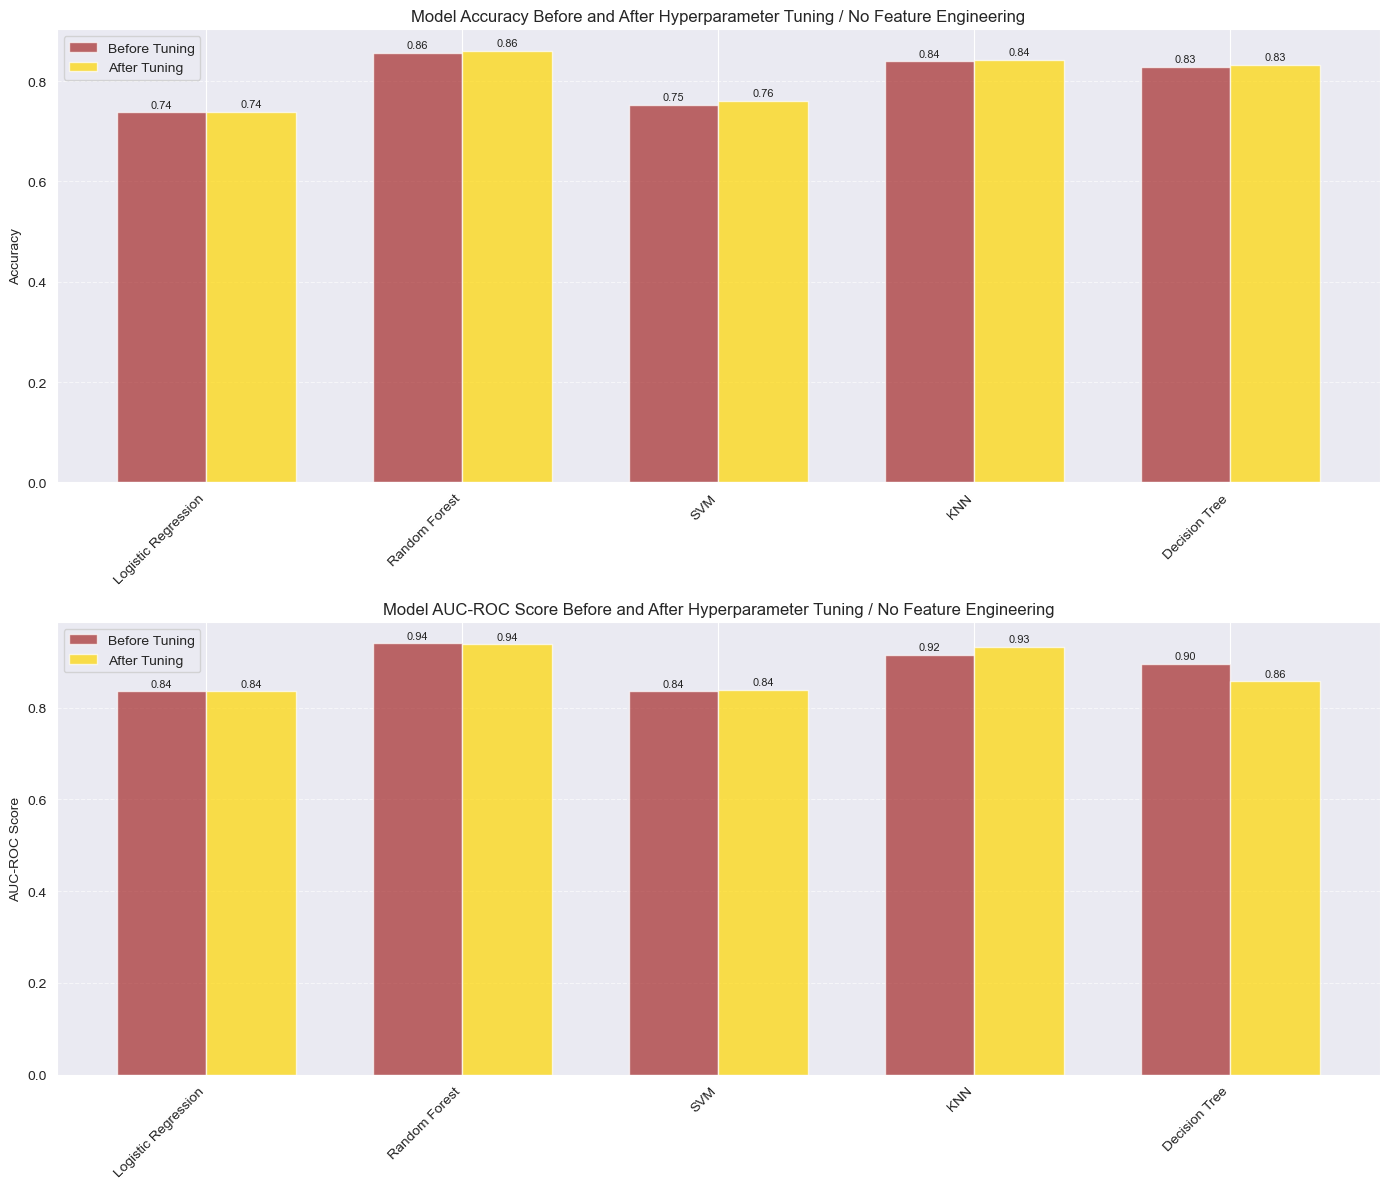

In [746]:


# Extract data for plotting
models = list(model_metrics["no_feature_engineering"]["before_tuning"]["accuracy"].keys())

accuracy_before = list(model_metrics["no_feature_engineering"]["before_tuning"]["accuracy"].values())
accuracy_after = list(model_metrics["no_feature_engineering"]["after_tuning"]["accuracy"].values())
auc_before = list(model_metrics["no_feature_engineering"]["before_tuning"]["auc_roc"].values())
auc_after = list(model_metrics["no_feature_engineering"]["after_tuning"]["auc_roc"].values())

# Bar width
bar_width = 0.35
x = np.arange(len(models))

# Plot Accuracy
fig, ax = plt.subplots(2, 1, figsize=(14, 12))
acc_bars1 = ax[0].bar(x - bar_width/2, accuracy_before, bar_width, label="Before Tuning", color='brown', alpha=0.7)
acc_bars2 = ax[0].bar(x + bar_width/2, accuracy_after, bar_width, label="After Tuning", color='gold', alpha=0.7)
ax[0].set_ylabel("Accuracy")
ax[0].set_title("Model Accuracy Before and After Hyperparameter Tuning / No Feature Engineering")
ax[0].set_xticks(x)
ax[0].set_xticklabels(models, rotation=45, ha="right")
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Add values on accuracy bars
for bar in acc_bars1 + acc_bars2:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.2f}", ha='center', va='bottom', fontsize=8)

# Plot AUC-ROC Score
auc_bars1 = ax[1].bar(x - bar_width/2, auc_before, bar_width, label="Before Tuning", color='brown', alpha=0.7)
auc_bars2 = ax[1].bar(x + bar_width/2, auc_after, bar_width, label="After Tuning", color='gold', alpha=0.7)
ax[1].set_ylabel("AUC-ROC Score")
ax[1].set_title("Model AUC-ROC Score Before and After Hyperparameter Tuning / No Feature Engineering")
ax[1].set_xticks(x)
ax[1].set_xticklabels(models, rotation=45, ha="right")
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

# Add values on AUC-ROC bars
for bar in auc_bars1 + auc_bars2:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.2f}", ha='center', va='bottom', fontsize=8)

# Save and show
plt.tight_layout()
plt.savefig("model_comparison_before_after_tuning_no_fe.svg", bbox_inches='tight')
plt.show()

### <span style=' color:orange'> Model metrics comparison before and after hypertuning-WITH FEATURE ENGINEERING</span>

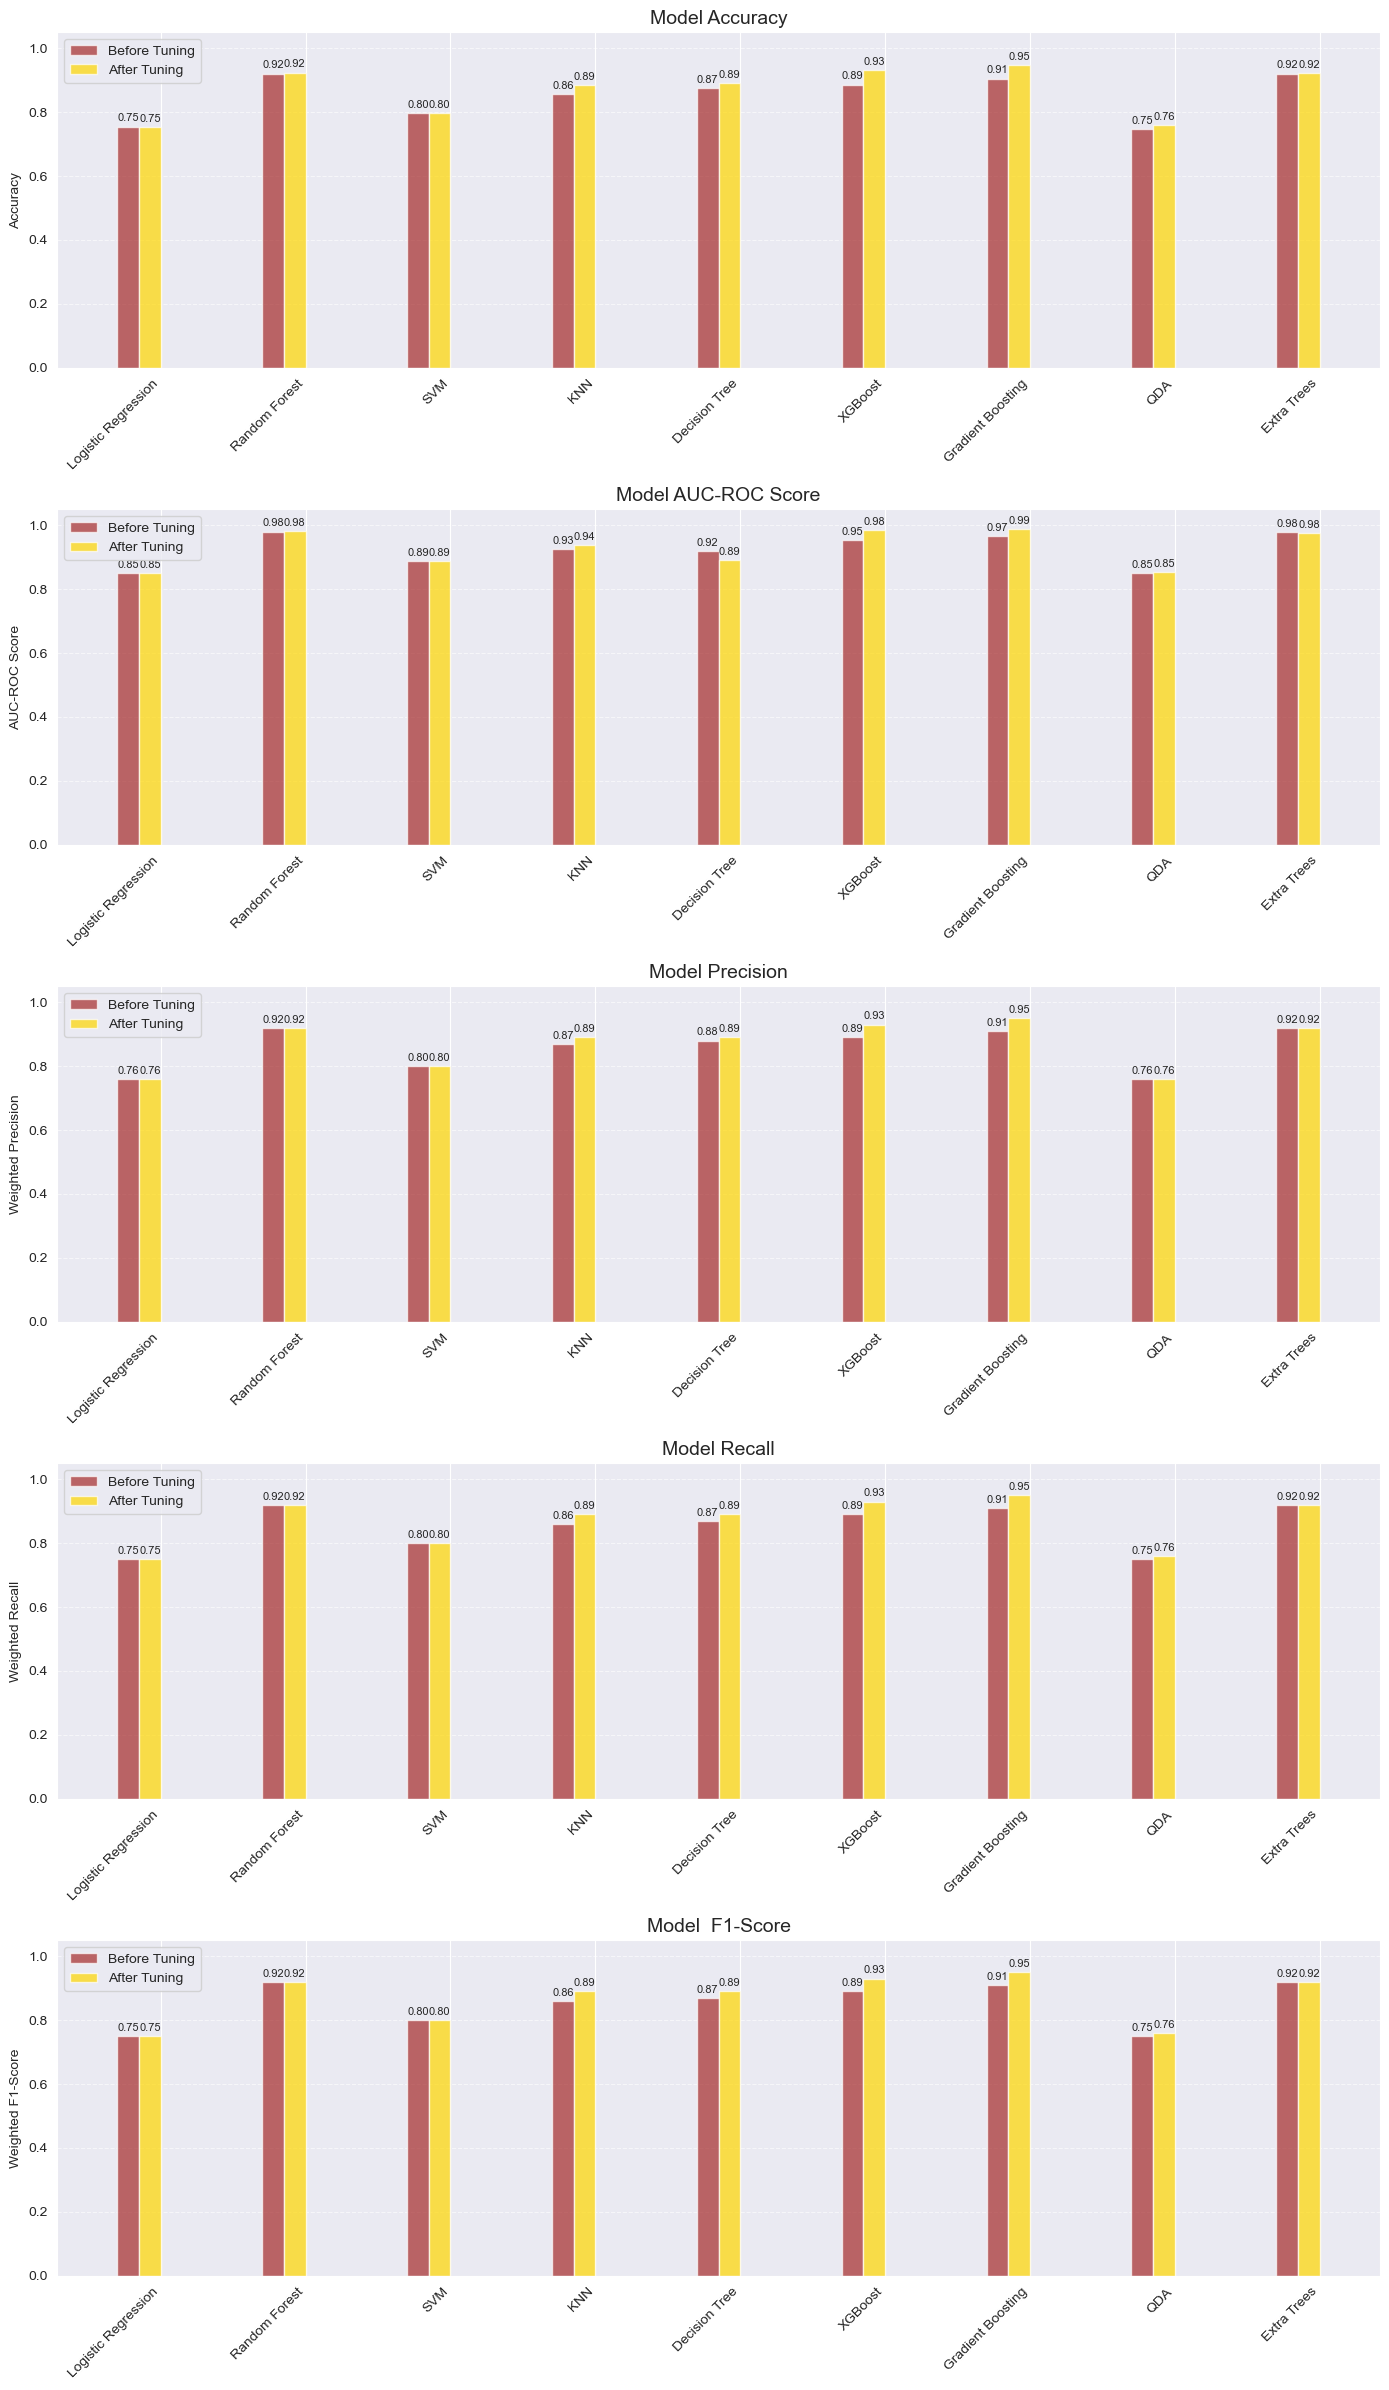

In [749]:
models = list(model_metrics["with_feature_engineering"]["before_tuning"]["accuracy"].keys())

accuracy_before = list(model_metrics["with_feature_engineering"]["before_tuning"]["accuracy"].values())
accuracy_after = list(model_metrics["with_feature_engineering"]["after_tuning"]["accuracy"].values())
auc_before = list(model_metrics["with_feature_engineering"]["before_tuning"]["auc_roc"].values())
auc_after = list(model_metrics["with_feature_engineering"]["after_tuning"]["auc_roc"].values())
precision_before = list(model_metrics["with_feature_engineering"]["before_tuning"]["precision"].values())
precision_after = list(model_metrics["with_feature_engineering"]["after_tuning"]["precision"].values())
recall_before = list(model_metrics["with_feature_engineering"]["before_tuning"]["recall"].values())
recall_after = list(model_metrics["with_feature_engineering"]["after_tuning"]["recall"].values())
f1_before = list(model_metrics["with_feature_engineering"]["before_tuning"]["f1_score"].values())
f1_after = list(model_metrics["with_feature_engineering"]["after_tuning"]["f1_score"].values())

# Bar width and x-axis positions
bar_width = 0.15
x = np.arange(len(models))

# Colors
color_before = 'brown'
color_after = 'gold'

# --- Combined Metrics Plot ---
fig, ax = plt.subplots(5, 1, figsize=(14, 24))

# Function to add bar labels
def add_bar_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Accuracy Plot
bars1 = ax[0].bar(x - 1.5*bar_width, accuracy_before, bar_width, label="Before Tuning", color=color_before, alpha=0.7)
bars2 = ax[0].bar(x - 0.5*bar_width, accuracy_after, bar_width, label="After Tuning", color=color_after, alpha=0.7)
ax[0].set_ylabel("Accuracy")
ax[0].set_title("Model Accuracy", fontsize=14)
ax[0].set_xticks(x)
ax[0].set_xticklabels(models, rotation=45, ha="right", fontsize=10)
ax[0].legend(fontsize=10)
ax[0].grid(axis='y', linestyle='--', alpha=0.6)
ax[0].set_ylim(0, 1.05)
add_bar_labels(ax[0], bars1 + bars2)

# AUC-ROC Plot
bars3 = ax[1].bar(x - 1.5*bar_width, auc_before, bar_width, label="Before Tuning", color=color_before, alpha=0.7)
bars4 = ax[1].bar(x - 0.5*bar_width, auc_after, bar_width, label="After Tuning", color=color_after, alpha=0.7)
ax[1].set_ylabel("AUC-ROC Score")
ax[1].set_title("Model AUC-ROC Score", fontsize=14)
ax[1].set_xticks(x)
ax[1].set_xticklabels(models, rotation=45, ha="right", fontsize=10)
ax[1].legend(fontsize=10)
ax[1].grid(axis='y', linestyle='--', alpha=0.6)
ax[1].set_ylim(0, 1.05)
add_bar_labels(ax[1], bars3 + bars4)

# Weighted Precision Plot
bars5 = ax[2].bar(x - 1.5*bar_width, precision_before, bar_width, label="Before Tuning", color=color_before, alpha=0.7)
bars6 = ax[2].bar(x - 0.5*bar_width, precision_after, bar_width, label="After Tuning", color=color_after, alpha=0.7)
ax[2].set_ylabel("Weighted Precision")
ax[2].set_title("Model Precision", fontsize=14)
ax[2].set_xticks(x)
ax[2].set_xticklabels(models, rotation=45, ha="right", fontsize=10)
ax[2].legend(fontsize=10)
ax[2].grid(axis='y', linestyle='--', alpha=0.6)
ax[2].set_ylim(0, 1.05)
add_bar_labels(ax[2], bars5 + bars6)

# Weighted Recall Plot
bars7 = ax[3].bar(x - 1.5*bar_width, recall_before, bar_width, label="Before Tuning", color=color_before, alpha=0.7)
bars8 = ax[3].bar(x - 0.5*bar_width, recall_after, bar_width, label="After Tuning", color=color_after, alpha=0.7)
ax[3].set_ylabel("Weighted Recall")
ax[3].set_title("Model Recall", fontsize=14)
ax[3].set_xticks(x)
ax[3].set_xticklabels(models, rotation=45, ha="right", fontsize=10)
ax[3].legend(fontsize=10)
ax[3].grid(axis='y', linestyle='--', alpha=0.6)
ax[3].set_ylim(0, 1.05)
add_bar_labels(ax[3], bars7 + bars8)

# Weighted F1-Score Plot
bars9 = ax[4].bar(x - 1.5*bar_width, f1_before, bar_width, label="Before Tuning", color=color_before, alpha=0.7)
bars10 = ax[4].bar(x - 0.5*bar_width, f1_after, bar_width, label="After Tuning", color=color_after, alpha=0.7)
ax[4].set_ylabel("Weighted F1-Score")
ax[4].set_title("Model  F1-Score", fontsize=14)
ax[4].set_xticks(x)
ax[4].set_xticklabels(models, rotation=45, ha="right", fontsize=10)
ax[4].legend(fontsize=10)
ax[4].grid(axis='y', linestyle='--', alpha=0.6)
ax[4].set_ylim(0, 1.05)
add_bar_labels(ax[4], bars9 + bars10)


plt.tight_layout()
plt.savefig("model_comparison_all_metrics_with_fe.svg", bbox_inches='tight')
plt.show()

### <span style=' color:orange'> Percentage accuracy improvement after hypertuning </span>


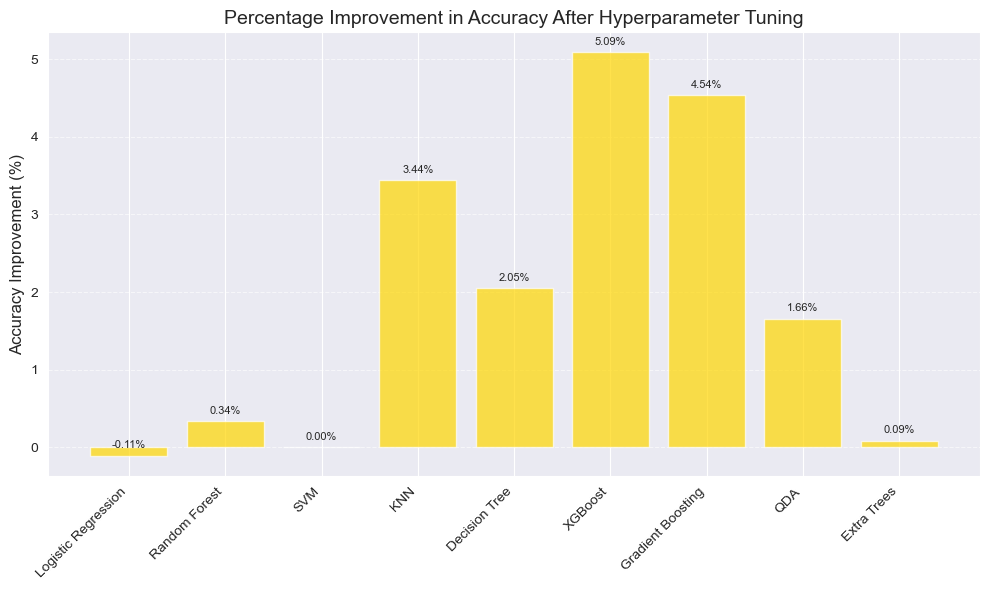

In [752]:

models = list(model_metrics["with_feature_engineering"]["before_tuning"]["accuracy"].keys())

# Extract accuracies before and after tuning
accuracy_before = np.array(list(model_metrics["with_feature_engineering"]["before_tuning"]["accuracy"].values()))
accuracy_after = np.array(list(model_metrics["with_feature_engineering"]["after_tuning"]["accuracy"].values()))

# Calculate percentage improvement
improvement = ((accuracy_after - accuracy_before) / accuracy_before) * 100

# ---  Visualization  ---
plt.figure(figsize=(10, 6))
plt.bar(models, improvement, color='gold', alpha=0.7)
plt.ylabel("Accuracy Improvement (%)", fontsize=12)
plt.title("Percentage Improvement in Accuracy After Hyperparameter Tuning", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add text labels for the improvement values
for i, val in enumerate(improvement):
    plt.text(i, val + 0.07, f"{val:.2f}%", ha='center', va='bottom', fontsize=8)  

plt.tight_layout()
plt.savefig("model_accuracy_improvement_percentage.svg", bbox_inches='tight')
plt.show()

### <span style=' color:orange'> Percentage accuracy improvement after FE </span>


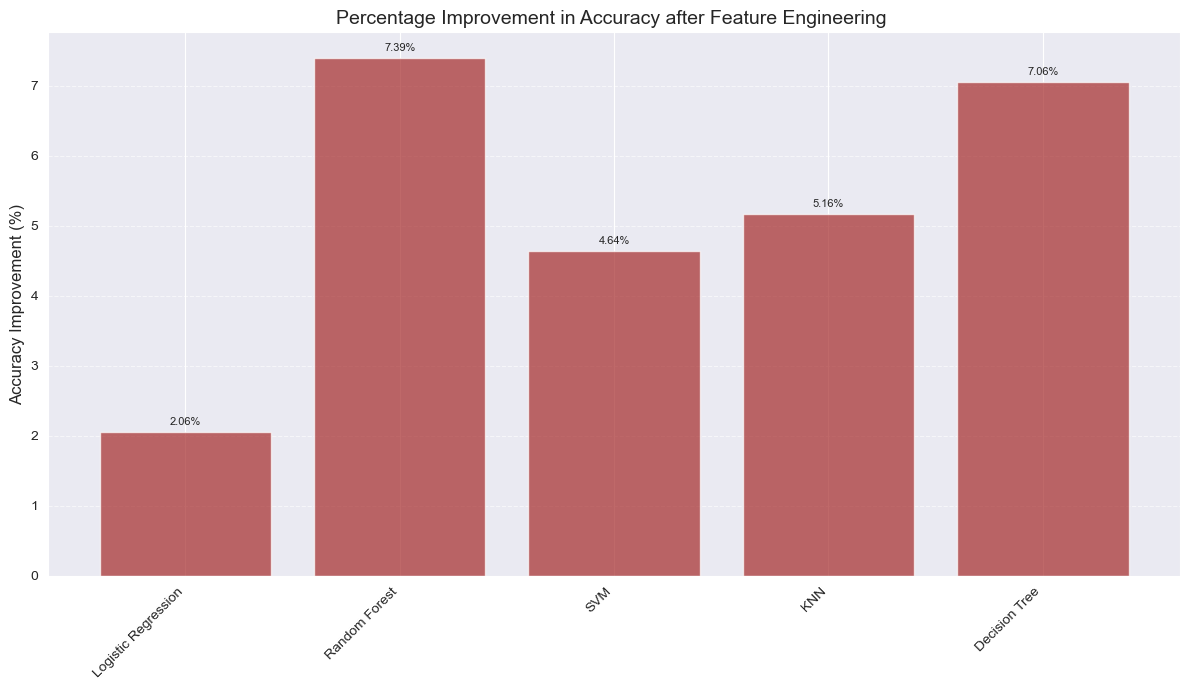

In [755]:
models = list(model_metrics["with_feature_engineering"]["before_tuning"]["accuracy"].keys())

# Extract accuracies after tuning for 'no_feature_engineering'
accuracy_before = np.array([model_metrics["no_feature_engineering"]["after_tuning"]["accuracy"].get(model, np.nan) for model in models])

# Extract accuracies after tuning for 'with_feature_engineering'
accuracy_after = np.array([model_metrics["with_feature_engineering"]["after_tuning"]["accuracy"].get(model, np.nan) for model in models])

# Calculate percentage improvement, handling potential NaNs
valid_indices = ~np.isnan(accuracy_before) & ~np.isnan(accuracy_after)
improvement = np.full(len(models), np.nan)  # Initialize with NaNs
improvement[valid_indices] = ((accuracy_after[valid_indices] - accuracy_before[valid_indices]) / accuracy_before[valid_indices]) * 100

# --- Visualization ---
plt.figure(figsize=(12, 7))
bars = plt.bar(models, improvement, color='brown', alpha=0.7)
plt.ylabel("Accuracy Improvement (%)", fontsize=12)
plt.title("Percentage Improvement in Accuracy after Feature Engineering ", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add text labels for the improvement values
for bar, val in zip(bars, improvement):
    if not np.isnan(val):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.07, f"{val:.2f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("model_accuracy_improvement_percentage_fe_vs_no_fe.svg", bbox_inches='tight')
plt.show()

### <span style=' color:orange'> CV Accuracy Comparison </span>


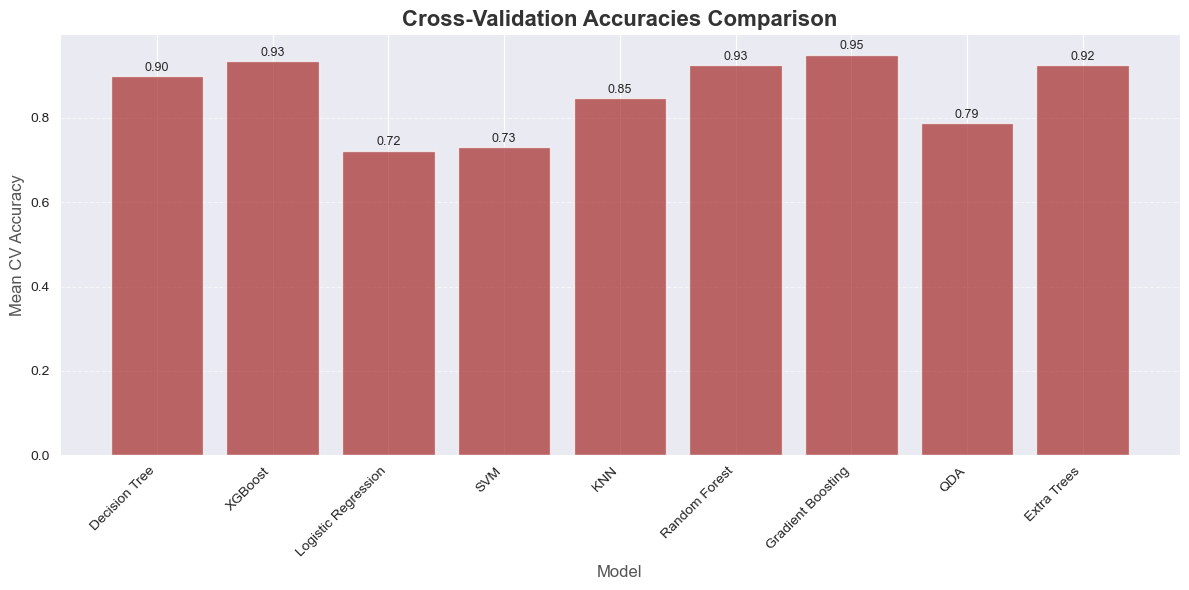

In [762]:

model_names = list(model_metrics["cross_validation"]["accuracy"].keys())
cv_accuracy = np.array(list(model_metrics["cross_validation"]["accuracy"].values()))

# Color for the bars
bar_color = 'brown'

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, cv_accuracy, color=bar_color, alpha=0.7)

# Add the value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, f"{yval:.2f}", ha='center', va='bottom', fontsize=9)

# Set title and labels
plt.title('Cross-Validation Accuracies Comparison', fontsize=16, fontweight='bold', color='#333333')
plt.ylabel('Mean CV Accuracy', fontsize=12, color='#555555')
plt.xlabel('Model', fontsize=12, color='#555555')
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig("cross_validation_accuracy_comparison_corrected.svg", bbox_inches='tight')

# Show plot
plt.show()

# <span style=' color:red'>Ensemble Learning</span>

### <span style=' color:red'> Ensemble 1: Stacking -Using Top 6 models</span>

✅ Top 6 Models (Highest Accuracy)
Gradient Boosting – 0.9464

XGBoost – 0.9317

Random Forest – 0.9231

Extra Trees Classifier – 0.9216

Decision Tree – 0.8921

K-Nearest Neighbors (KNN) – 0.8797


🚨 Last 6 Models (Lowest Accuracy)
K-Nearest Neighbors (KNN) – 0.8797

Support Vector Machine (SVM) – 0.8253

Quadratic Discriminant Analysis (QDA) – 0.7601

Logistic Regression – 0.7531

(Remaining 2 not applicable — list is 9 models total

In [767]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression


In [769]:
#When selecting a model for the meta-estimator in stacking, you should consider several criteria:

#Diversity: Choose a model that is diverse from the base models. For example, if your base models are mostly tree-based (e.g., decision trees, random forests), using a non-tree model like logistic regression or SVM as the meta-estimator can be beneficial.

#Simplicity: A simple model is often preferred as the meta-estimator because it is less prone to overfitting. Logistic regression is commonly used due to its simplicity and ability to handle binary classification problems effectively.

### <span style=' color:red'> Ensemble 1: Stacking -Top 6 Models</span>

In [776]:
# ✅ Top 6 Models (Highest Accuracy)

#Gradient Boosting – 0.9464

# XGBoost – 0.9317

# Random Forest – 0.9231

# Extra Trees Classifier – 0.9216

# Decision Tree – 0.8921

# K-Nearest Neighbors (KNN) – 0.8797


# Define the top models
models_top = [
    ('best_gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('best_etc', ExtraTreesClassifier(random_state=42)),
    ('best_rf', RandomForestClassifier(random_state=42)),
    ('best_dt', DecisionTreeClassifier(random_state=42)),
    ('best_xgb_model', XGBClassifier(random_state=42) ),
    ('best_knn', KNeighborsClassifier() )

]

In [778]:
# Define the stacking model with logistic regression as the meta-estimator

stacking_model = StackingClassifier(
    estimators=models_top,
    final_estimator=LogisticRegression(max_iter=10000),
    cv=30
)


In [780]:
# Train the stacking model
stacking_model.fit(X_train, y_train)



StackingClassifier(cv=30,
                   estimators=[('best_gb',
                                GradientBoostingClassifier(random_state=42)),
                               ('best_etc',
                                ExtraTreesClassifier(random_state=42)),
                               ('best_rf',
                                RandomForestClassifier(random_state=42)),
                               ('best_dt',
                                DecisionTreeClassifier(random_state=42)),
                               ('best_xgb_model',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              col...
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('best_knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression(max_iter=10000))

In [781]:
# Predict on the test set
y_pred_stacking = stacking_model.predict(X_test)
y_proba_stacking = stacking_model.predict_proba(X_test)[:, 1]



In [786]:
# Evaluate performance
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
print(f"Stacking Top Ensemble Accuracy: {accuracy_stacking:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_stacking))

print(classification_report(y_test, y_pred_stacking))

Stacking Top Ensemble Accuracy: 0.9317
AUC-ROC Score: 0.9857520730504645
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       647
           1       0.92      0.95      0.93       641

    accuracy                           0.93      1288
   macro avg       0.93      0.93      0.93      1288
weighted avg       0.93      0.93      0.93      1288



### <span style=' color:red'> Ensemble 1: Stacking -Using Last 6 models</span>

<!-- ✅ Top 6 Models (Highest Accuracy)
Gradient Boosting – 0.9464

XGBoost – 0.9317

Random Forest – 0.9231

Extra Trees Classifier – 0.9216

Decision Tree – 0.8921

K-Nearest Neighbors (KNN) – 0.8797


🚨 Last 6 Models (Lowest Accuracy)
K-Nearest Neighbors (KNN) – 0.8797

Support Vector Machine (SVM) – 0.8253

Quadratic Discriminant Analysis (QDA) – 0.7601

Logistic Regression – 0.7531 -->

In [793]:


# Define the last 6 models
models_last = [
    ('best_logreg', LogisticRegression(max_iter=10000, random_state=42)),
    ('best_qda', QuadraticDiscriminantAnalysis()),
    ('best_svm', SVC(probability=True, random_state=42)),
    ('best_knn', KNeighborsClassifier()),
    ('best_dt', DecisionTreeClassifier(random_state=42)),
    ('best_etc', ExtraTreesClassifier(random_state=42))
    
]

# Define the stacking model with logistic regression as the meta-estimator
stacking_model = StackingClassifier(
    estimators=models_last,
    final_estimator=LogisticRegression(max_iter=10000),
    cv=5
)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Predict on the test set
y_pred_stacking = stacking_model.predict(X_test)
y_proba_stacking = stacking_model.predict_proba(X_test)[:, 1]

# Evaluate performance
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
print(f"Stacking Last Ensemble Accuracy: {accuracy_stacking:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_stacking))

print(classification_report(y_test, y_pred_stacking))


D:\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Stacking Last Ensemble Accuracy: 0.9224
AUC-ROC Score: 0.9789861764486036
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       647
           1       0.91      0.93      0.92       641

    accuracy                           0.92      1288
   macro avg       0.92      0.92      0.92      1288
weighted avg       0.92      0.92      0.92      1288



### <span style=' color:red'> Ensemble 1: Stacking -Using Random models</span>

In [796]:
# Define all models
models_random= [
    
    ('best_qda', QuadraticDiscriminantAnalysis()),
    ('best_svm', SVC(probability=True, random_state=42)),
    ('best_knn', KNeighborsClassifier()),
    ('best_dt', DecisionTreeClassifier(random_state=42)),
    ('best_gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('best_rf', RandomForestClassifier(random_state=42)),

]




In [798]:
# Define the stacking model with logistic regression as the meta-estimator

stacking_model = StackingClassifier(
    estimators=models_random,
    final_estimator=LogisticRegression(max_iter=10000),
    cv=5
)

# Train the stacking model
best_stacking_model=stacking_model.fit(X_train, y_train)

# Predict on the test set
y_pred_stacking = best_stacking_model.predict(X_test)
y_proba_stacking = best_stacking_model.predict_proba(X_test)[:, 1]

# Evaluate performance
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
print(f"Stacking  Random Ensemble Accuracy: {accuracy_stacking:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_stacking))

print(classification_report(y_test, y_pred_stacking))


Stacking  Random Ensemble Accuracy: 0.9325
AUC-ROC Score: 0.9804015653670969
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       647
           1       0.92      0.95      0.93       641

    accuracy                           0.93      1288
   macro avg       0.93      0.93      0.93      1288
weighted avg       0.93      0.93      0.93      1288



### <span style=' color:orange'>  Stacking Vs Best Single Model ???</span>

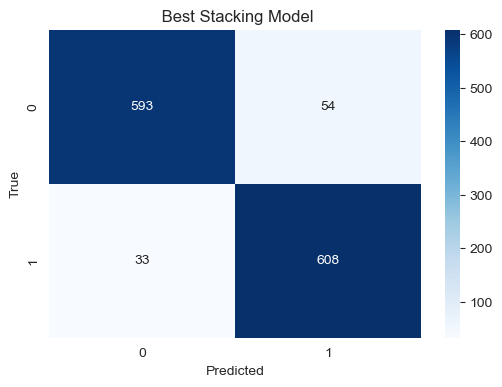

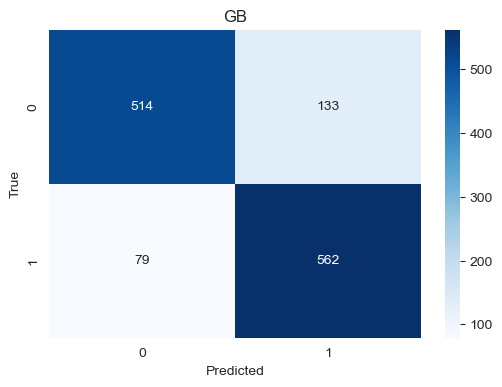

In [801]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# Stacking model predictions
y_pred_stacking = best_stacking_model.predict(X_test)
plot_confusion_matrix(y_test, y_pred_stacking, " Best Stacking Model")

# Base model predictions (example for Extreme Gradient Boosting)
y_pred_gb = stacking_model.named_estimators_['best_gb'].predict(X_test)
plot_confusion_matrix(y_test, y_pred_gb, "GB")


In [803]:
#Stacking is preferable beacuse it has fewer false negatives

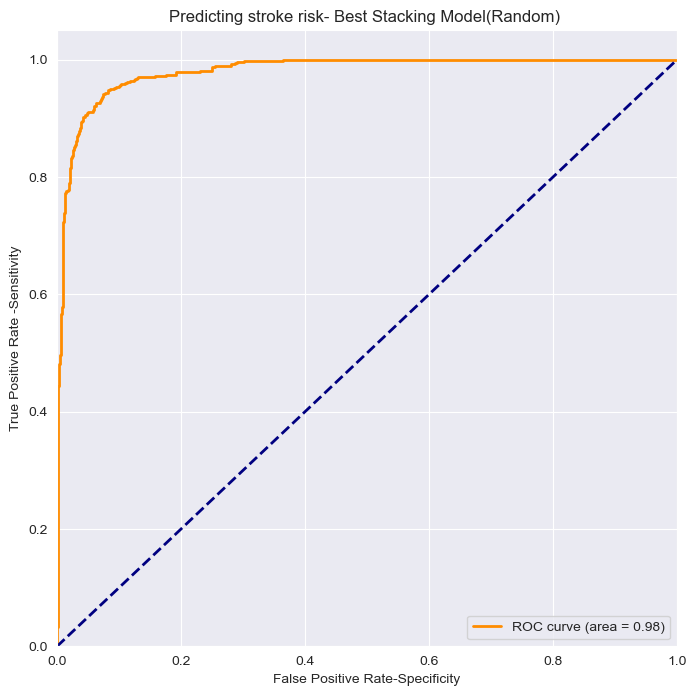

In [902]:
from sklearn.metrics import roc_curve, auc


# Compute area under the curve

fpr, tpr, _ = roc_curve(y_test, y_proba_stacking)
roc_auc = auc(fpr, tpr)

#Set default figure size
plt.rcParams['figure.figsize'] = (8,8)

# Plot ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate-Specificity')
plt.ylabel('True Positive Rate -Sensitivity')
plt.title("Predicting stroke risk- Best Stacking Model(Random) ")
plt.legend(loc="lower right")

plt.savefig("ROC Curve -Best Stacking.svg")
plt.show()


### <span style=' color:red'> Ensemble 2: Soft Voting -Random Models</span>

In [808]:
from sklearn.ensemble import VotingClassifier


# Define the voting ensemble
voting_model = VotingClassifier(
    estimators=models_random,
    voting='soft' # Use soft voting for probabilistic predictions
    
)

# Train the voting model
voting_model.fit(X_train, y_train)

# Predict on the test set
y_pred_voting = voting_model.predict(X_test)
y_proba_voting = voting_model.predict_proba(X_test)[:, 1]

# Evaluate performance
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Voting Random  Ensemble Accuracy: {accuracy_voting:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_voting))

print(classification_report(y_test, y_pred_voting))


Voting Random  Ensemble Accuracy: 0.8804
AUC-ROC Score: 0.956298962932242
              precision    recall  f1-score   support

           0       0.94      0.82      0.87       647
           1       0.84      0.95      0.89       641

    accuracy                           0.88      1288
   macro avg       0.89      0.88      0.88      1288
weighted avg       0.89      0.88      0.88      1288



### <span style=' color:red'> Ensemble 2: Soft Voting -Last Models</span>

In [810]:



# Define the voting ensemble
voting_model = VotingClassifier(
    estimators=models_last,
    voting='soft' # Use soft voting for probabilistic predictions
    
)

# Train the voting model
voting_model.fit(X_train, y_train)

# Predict on the test set
y_pred_voting = voting_model.predict(X_test)
y_proba_voting = voting_model.predict_proba(X_test)[:, 1]

# Evaluate performance
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Voting  Last Ensemble Accuracy: {accuracy_voting:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_voting))

print(classification_report(y_test, y_pred_voting))


D:\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Voting  Last Ensemble Accuracy: 0.8742
AUC-ROC Score: 0.9519298237153597
              precision    recall  f1-score   support

           0       0.93      0.81      0.87       647
           1       0.83      0.94      0.88       641

    accuracy                           0.87      1288
   macro avg       0.88      0.87      0.87      1288
weighted avg       0.88      0.87      0.87      1288



### <span style=' color:red'> Ensemble 2: Soft Voting -Top Models</span>

In [812]:

# Define the voting ensemble
voting_model = VotingClassifier(
    estimators=models_top,
    voting='soft' # Use soft voting for probabilistic predictions
    
)

# Train the voting model
voting_model.fit(X_train, y_train)

# Predict on the test set
y_pred_voting = voting_model.predict(X_test)
y_proba_voting = voting_model.predict_proba(X_test)[:, 1]

# Evaluate performance
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Voting Top Ensemble Accuracy: {accuracy_voting:.4f}")
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_voting))

print(classification_report(y_test, y_pred_voting))


Voting Top Ensemble Accuracy: 0.9208
AUC-ROC Score: 0.9794587764963458
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       647
           1       0.89      0.96      0.92       641

    accuracy                           0.92      1288
   macro avg       0.92      0.92      0.92      1288
weighted avg       0.92      0.92      0.92      1288



### <span style=' color:red'> Ensemble 3: Hard Voting -random Models</span>

In [815]:

# Define the voting ensemble with hard voting
hard_voting_model = VotingClassifier(
    estimators=models_random,
    voting='hard'
)

# Train the hard voting model
hard_voting_model.fit(X_train, y_train)

# Predict on the test set
y_pred_hard_voting = hard_voting_model.predict(X_test)

# Evaluate performance
accuracy_hard_voting = accuracy_score(y_test, y_pred_hard_voting)
print(f"Hard Voting Ensemble Accuracy: {accuracy_hard_voting:.4f}")

# Note: Hard voting does not provide probabilities, so AUC-ROC cannot be calculated directly
print(classification_report(y_test, y_pred_hard_voting))


Hard Voting Ensemble Accuracy: 0.8766
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       647
           1       0.86      0.90      0.88       641

    accuracy                           0.88      1288
   macro avg       0.88      0.88      0.88      1288
weighted avg       0.88      0.88      0.88      1288



### <span style=' color:red'> Ensemble 3: Hard Voting -Top Models</span>

In [818]:
# Define the voting ensemble with hard voting
hard_voting_model = VotingClassifier(
    estimators=models_top,
    voting='hard'
)

# Train the hard voting model
hard_voting_model.fit(X_train, y_train)

# Predict on the test set
y_pred_hard_voting = hard_voting_model.predict(X_test)

# Evaluate performance
accuracy_hard_voting = accuracy_score(y_test, y_pred_hard_voting)
print(f"Hard Voting Ensemble Accuracy: {accuracy_hard_voting:.4f}")

# Note: Hard voting does not provide probabilities, so AUC-ROC cannot be calculated directly
print(classification_report(y_test, y_pred_hard_voting))


Hard Voting Ensemble Accuracy: 0.9286
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       647
           1       0.91      0.95      0.93       641

    accuracy                           0.93      1288
   macro avg       0.93      0.93      0.93      1288
weighted avg       0.93      0.93      0.93      1288



### <span style=' color:red'> Ensemble 3: Hard Voting -Last  Models</span>

In [821]:
# Define the voting ensemble with hard voting
hard_voting_model = VotingClassifier(
    estimators=models_last,
    voting='hard'
)

# Train the hard voting model
hard_voting_model.fit(X_train, y_train)

# Predict on the test set
y_pred_hard_voting = hard_voting_model.predict(X_test)

# Evaluate performance
accuracy_hard_voting = accuracy_score(y_test, y_pred_hard_voting)
print(f"Hard Voting Ensemble Accuracy: {accuracy_hard_voting:.4f}")

# Note: Hard voting does not provide probabilities, so AUC-ROC cannot be calculated directly
print(classification_report(y_test, y_pred_hard_voting))


D:\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Hard Voting Ensemble Accuracy: 0.8525
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       647
           1       0.83      0.88      0.86       641

    accuracy                           0.85      1288
   macro avg       0.85      0.85      0.85      1288
weighted avg       0.85      0.85      0.85      1288



### <span style=' color:gold'>Metric Table for ALL models  - start crosscheking values from here </span>

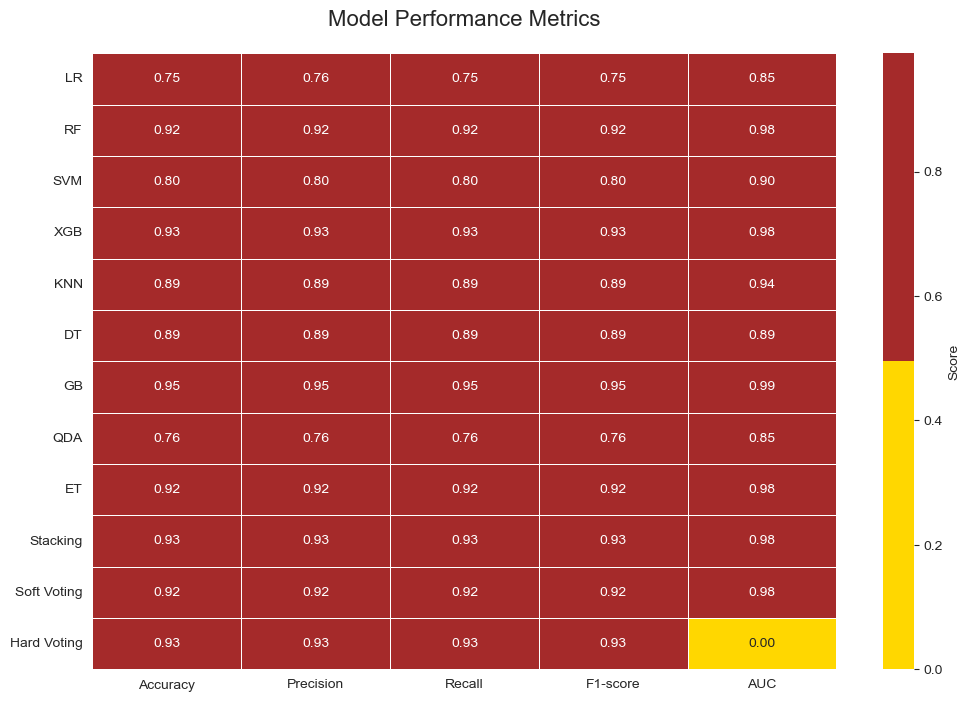

In [831]:


# Model names, including ensembles
models = ['LR', 'RF', 'SVM', 'XGB', 'KNN', 'DT', 'GB', 'QDA', 'ET', 'Stacking', 'Soft Voting', 'Hard Voting']


metrics = {
    'Accuracy': [0.75, 0.92, 0.80, 0.932, 0.89, 0.89, 0.95, 0.76, 0.92, 0.93, 0.92, 0.93],
    'Precision': [0.76, 0.92, 0.80, 0.93, 0.89, 0.89, 0.95, 0.76, 0.92, 0.93, 0.92, 0.93],
    'Recall': [0.75, 0.92, 0.80, 0.93, 0.89, 0.89, 0.95, 0.76, 0.92, 0.93, 0.92, 0.93],
    'F1-score': [0.75, 0.92, 0.80, 0.93, 0.89, 0.89, 0.95, 0.76, 0.92, 0.93, 0.92, 0.93],
    'AUC': [0.85, 0.98, 0.90, 0.98, 0.94, 0.89, 0.99, 0.85, 0.98, 0.98, 0.98, 0.00]
}

# Create DataFrame
df = pd.DataFrame(metrics, index=models)

# Set figure size
plt.figure(figsize=(12, 8))

# Create heatmap
sns.heatmap(df, annot=True, cmap=colors, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Score'})

# Title and labels
plt.title('Model Performance Metrics', fontsize=16, pad=20)
plt.yticks(rotation=0)  # Keep model names horizontal

# Save the figure
plt.savefig('all_models_vs_metrics_heatmap.svg', bbox_inches='tight', dpi=300)

plt.show()



### <span style=' color:gold'> RADAR CHART for base learners</span>

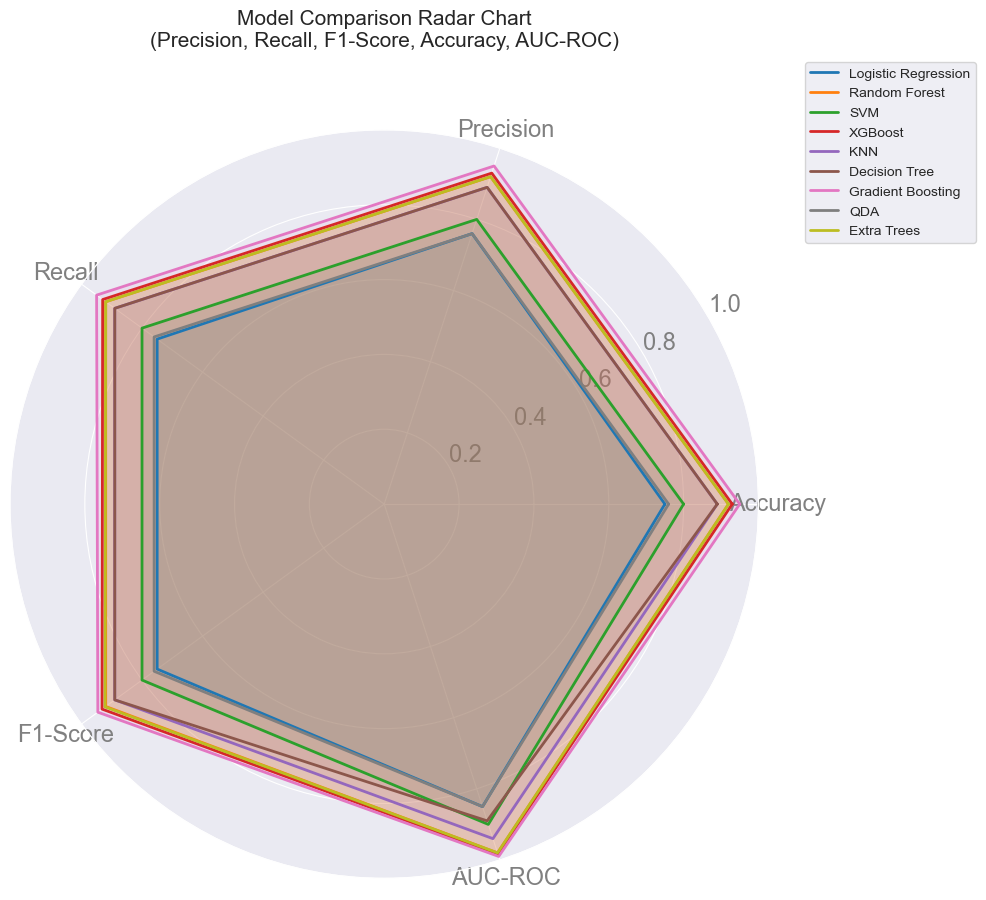

In [949]:


models = [
    'Logistic Regression', 'Random Forest', 'SVM', 'XGBoost', 'KNN',
    'Decision Tree', 'Gradient Boosting', 'QDA', 'Extra Trees'
]



metrics = ['Accuracy','Precision', 'Recall', 'F1-Score', 'AUC-ROC']

# Each sublist corresponds to a model's metrics in the order above
values = [
    [0.75, 0.76, 0.75, 0.75, 0.85],  # Logistic Regression (weighted avg + accuracy + AUC)
    [0.92, 0.92, 0.92, 0.92, 0.98],  # Random Forest
    [0.80, 0.80, 0.80, 0.80, 0.90],  # SVM
    [0.93, 0.93, 0.93, 0.932, 0.984],  # XGBoost 
    [0.89, 0.89, 0.89, 0.89, 0.94],  # KNN
    [0.89, 0.89, 0.89, 0.89, 0.89],  # Decision Tree
    [0.95, 0.95, 0.95, 0.946, 0.99],  # Gradient Boosting (best accuracy)
    [0.76, 0.76, 0.76, 0.760, 0.85],  # QDA
    [0.92, 0.92, 0.92, 0.922, 0.98],  # Extra Trees
]

# Number of variables
num_vars = len(metrics)

# Compute angle for each axis in the plot (in radians)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Draw one axe per variable + add labels
plt.xticks(angles[:-1], metrics, color='grey', size=17)

# Draw ylabels
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2","0.4","0.6","0.8","1.0"], color="grey", size=17)
plt.ylim(0, 1)

# Plot each model
for i, model_values in enumerate(values):
    # Complete the loop for radar chart
    vals = model_values + model_values[:1]
    ax.plot(angles, vals, linewidth=2, linestyle='solid', label=models[i])
    ax.fill(angles, vals, alpha=0.1)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.title('Model Comparison Radar Chart\n(Precision, Recall, F1-Score, Accuracy, AUC-ROC)', size=15, y=1.1)
plt.tight_layout()
plt.savefig('Radar Chart.svg')
plt.show()


### <span style=' color:gold'> Make it best base vs best ensemble </span>

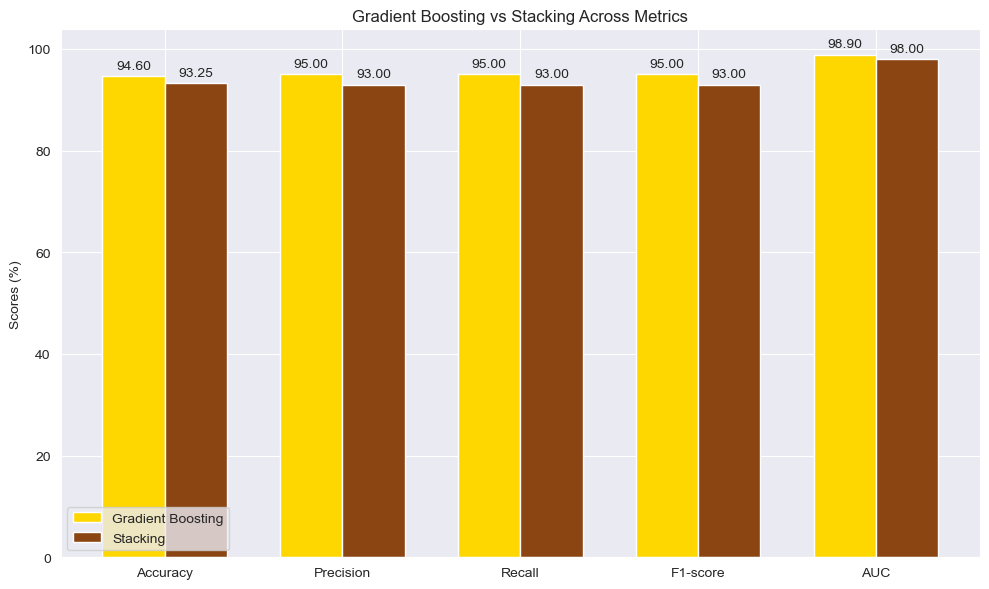

In [839]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['Gradient Boosting', 'Stacking']

# Metrics (GB, Stacking)
metrics = {
    'Accuracy': [94.60, 93.25],
    'Precision': [95.00, 93.00],
    'Recall': [95.00, 93.00],
    'F1-score': [95.00, 93.00],
    'AUC': [98.9, 98.0]
}

# Metric names
metric_names = list(metrics.keys())

# Values
gb_values = [metrics[m][0] for m in metric_names]
stacking_values = [metrics[m][1] for m in metric_names]

# X positions
x = np.arange(len(metric_names))
width = 0.35  # width of bars

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
bars1 = ax.bar(x - width/2, gb_values, width, label='Gradient Boosting', color='#FFD700')  # gold
bars2 = ax.bar(x + width/2, stacking_values, width, label='Stacking', color='#8B4513')     # brown

# Add labels, title, and ticks
ax.set_ylabel('Scores (%)')
ax.set_title('Gradient Boosting vs Stacking Across Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig("gb_vs_stacking_grouped.svg", bbox_inches='tight', dpi=300)

# Show plot
plt.show()


### <span style=' color:gold'>Stacking Vs Voting </span>

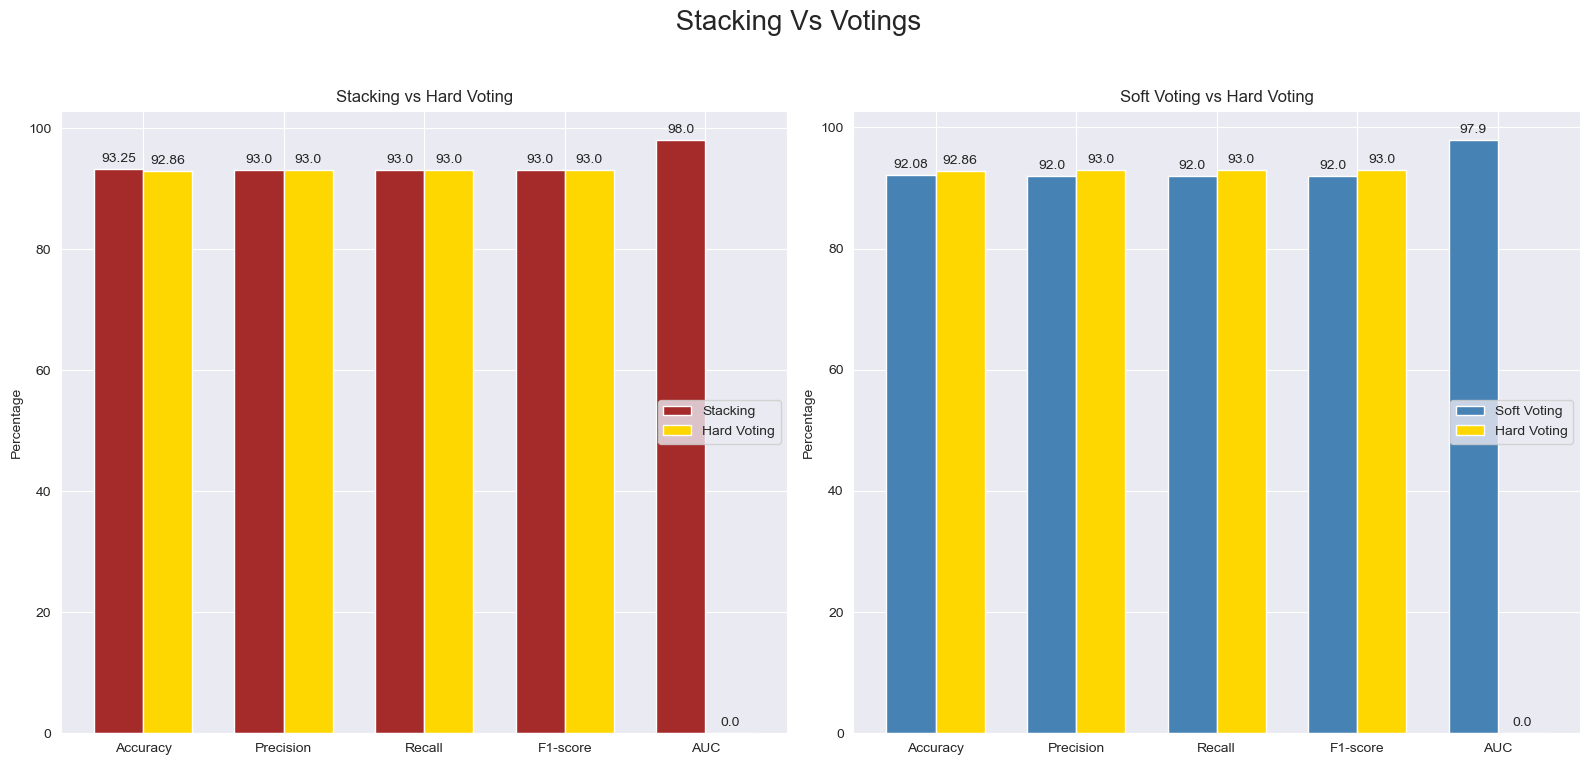

In [860]:


# Define model names
model_pairs = [
    ('Stacking', 'Hard Voting'),
    ('Soft Voting', 'Hard Voting')
]

# Define metrics for each model
metrics = {
    'Stacking': {'Accuracy': 93.25, 'Precision': 93.00, 'Recall': 93.00, 'F1-score': 93.00, 'AUC': 98.0},
    'Soft Voting': {'Accuracy': 92.08, 'Precision': 92.00, 'Recall': 92.00, 'F1-score': 92.00, 'AUC': 97.9},
    'Hard Voting': {'Accuracy': 92.86, 'Precision': 93.00, 'Recall': 93.00, 'F1-score': 93.00, 'AUC': 0.00}
}

# Define colors for the models
model_colors = {
    'Stacking': 'brown',
    'Soft Voting': 'steelblue',
    'Hard Voting': 'gold'
}

# Metric names
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Loop through each model pair and create a bar chart
for idx, (model1, model2) in enumerate(model_pairs):
    # Metric values for the models
    model1_values = [metrics[model1][metric] for metric in metric_names]
    model2_values = [metrics[model2][metric] for metric in metric_names]

    # X-axis locations for the bars
    x = np.arange(len(metric_names))
    width = 0.35

    # Plot bars for each model
    rects1 = axes[idx].bar(x - width/2, model1_values, width, label=model1, color=model_colors[model1])
    rects2 = axes[idx].bar(x + width/2, model2_values, width, label=model2, color=model_colors[model2])

    # Add labels on top of the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            axes[idx].annotate('{}'.format(height),
                                xy=(rect.get_x() + rect.get_width() / 2, height),
                                xytext=(0, 3),  # 3 points vertical offset
                                textcoords="offset points",
                                ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    # Customize the chart
    axes[idx].set_ylabel('Percentage')
    axes[idx].set_title(f'{model1} vs {model2}')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metric_names)
    axes[idx].legend(loc='best')

# Add a title to the entire figure
fig.suptitle(' Stacking Vs Votings', fontsize=20)

# Adjust layout to prevent labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the plot
plt.savefig("stacking vs votings.svg")

# Show the plot
plt.show()


### <span style=' color:gold'> Ensemble technigues- all selections</span> 

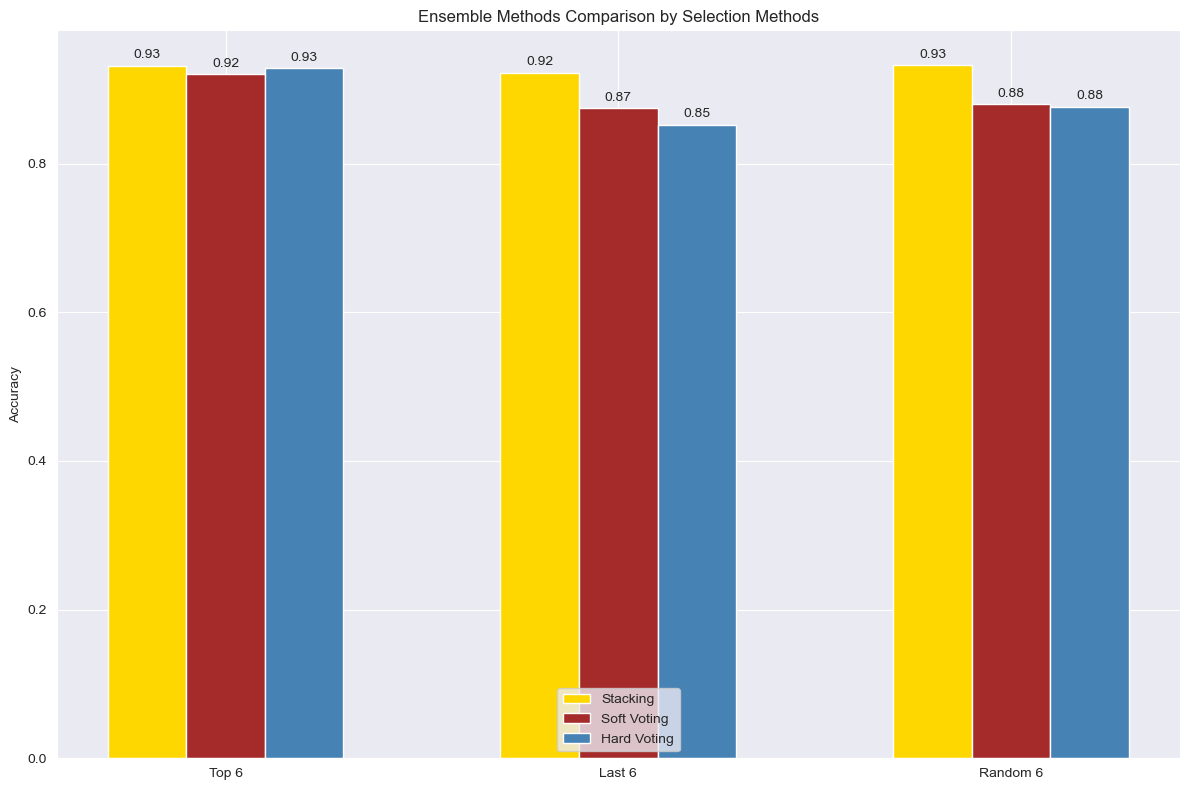

In [875]:
import matplotlib.pyplot as plt
import numpy as np

# Define the data
ensemble_types = ['Stacking', 'Soft Voting', 'Hard Voting']
selection_methods = ['Top 6', 'Last 6', 'Random 6']

# Data for each model
data = {
    'Stacking': {'Top 6': 0.9317, 'Last 6': 0.9224, 'Random 6': 0.9325},
    'Soft Voting': {'Top 6': 0.9208, 'Last 6': 0.8742, 'Random 6': 0.8804},
    'Hard Voting': {'Top 6': 0.9286, 'Last 6': 0.8525, 'Random 6': 0.8766}
}

# Positions for the bars
x = np.arange(len(selection_methods))
width = 0.2

# Define colors: gold, brown, blue
colors = ['gold', 'brown', 'steelblue']

# Create the figure and axes object
fig, ax = plt.subplots(figsize=(12, 8))

# Loop through each model and plot
rects = []
for i, (ensemble_type, color) in enumerate(zip(ensemble_types, colors)):
    values = [data[ensemble_type][method] for method in selection_methods]
    position = x + (i - len(ensemble_types)/2 + 0.5) * width
    rects.append(ax.bar(position, values, width, label=ensemble_type, color=color))

# Add labels, title, and ticks
ax.set_ylabel('Accuracy')
ax.set_title('Ensemble Methods Comparison by Selection Methods')
ax.set_xticks(x)
ax.set_xticklabels(selection_methods)
ax.legend(loc='lower center')

# Function to add labels on top of bars
def autolabel(rect_group):
    for rect in rect_group:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Add labels for each bar group
for rect_group in rects:
    autolabel(rect_group)

# Tight layout
fig.tight_layout()

# Save figure
plt.savefig("ensemble_comparisons_all_selections.svg", dpi=300, bbox_inches='tight')

# Show plot
plt.show()


# <span style=' color:red'> XAI on the GB Model</span>

In [826]:
! pip install shap lime


In [879]:
import shap
import lime
import lime.lime_tabular


## <span style=' color:red'> XAI -1-SHap</span>

In [906]:

# Create a SHAP explainer 
explainer = shap.TreeExplainer(best_gb)


In [908]:
# Sample a subset of your test data for efficiency
sample_size = 100
sample_indices = np.random.choice(X_test.shape[0], min(sample_size, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_indices]


In [910]:
# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)



In [912]:
# Calculate the mean absolute SHAP value for each feature manually

feature_importance = []
for i, col in enumerate(X_train.columns):
    # Get absolute SHAP values for this feature and calculate mean
    mean_shap = np.abs(shap_values[:, i]).mean()
    feature_importance.append((col, mean_shap))

# Convert to DataFrame
importance_df = pd.DataFrame(feature_importance, columns=['Feature', 'SHAP_Importance'])
importance_df = importance_df.sort_values('SHAP_Importance', ascending=False)



In [914]:
# Print the top 10 features
print("Top features by SHAP importance:")
print(importance_df)



Top features by SHAP importance:
                  Feature  SHAP_Importance
8                   age^2         7.393079
6                     age         3.717504
9   age avg_glucose_level         2.091189
7       avg_glucose_level         1.720264
10    avg_glucose_level^2         1.238717
3          smoking_status         1.217766
5                  gender         0.980993
2            ever_married         0.711037
4               work_type         0.700801
1            hypertension         0.351758
0           heart_disease         0.108352


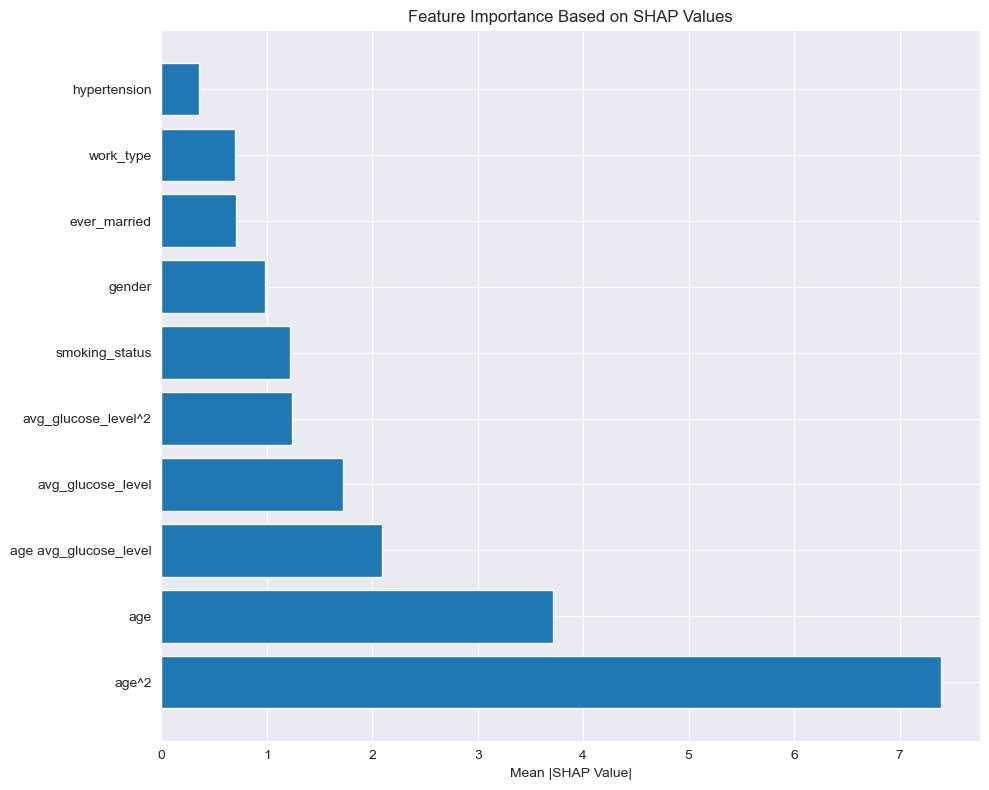

In [916]:
# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:10], importance_df['SHAP_Importance'][:10])
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance Based on SHAP Values')


plt.tight_layout()
plt.savefig('shap_importance_manual.svg')

plt.show()



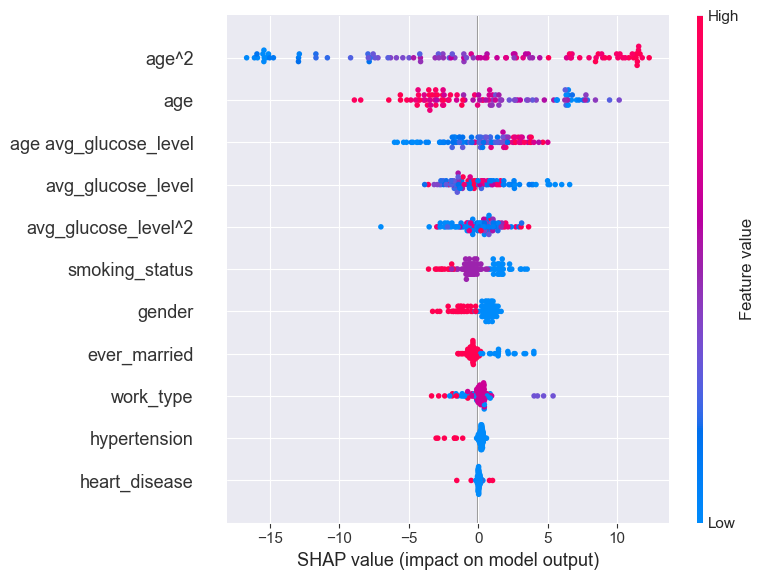

In [930]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.gcf().savefig("Beeswarm plot-shap.svg")


 ### <span style=' color:red'>Permutation Feature Importance</span>

In [933]:

from sklearn.inspection import permutation_importance

# Calculate permutation importance
# This shuffles each feature column and measures the drop in performance

result = permutation_importance(
    best_gb,  # Your trained model
    X_test,  # Test features
    y_test,  # Test target
    n_repeats=10,  # Number of times to repeat the shuffling
    random_state=42,  # For reproducibility
    scoring='roc_auc',  # Metric to use (AUC-ROC)
    n_jobs=-1  # Use all available cores
)



In [934]:
# Convert results to a DataFrame and sort by importance
perm_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': result.importances_mean,  # Average importance across repeats
    'Std_Dev': result.importances_std  # Standard deviation of importance
}).sort_values('Importance', ascending=False)

# Print the results
print("Permutation Feature Importance (higher = more important):")
print(perm_importance_df)



Permutation Feature Importance (higher = more important):
                  Feature  Importance   Std_Dev
8                   age^2    0.521746  0.010993
6                     age    0.144576  0.004703
7       avg_glucose_level    0.041639  0.002566
10    avg_glucose_level^2    0.034033  0.003425
9   age avg_glucose_level    0.032163  0.003025
4               work_type    0.010346  0.001895
3          smoking_status    0.009943  0.001171
2            ever_married    0.008111  0.001461
5                  gender    0.007431  0.001145
1            hypertension    0.001621  0.000603
0           heart_disease    0.000605  0.000382


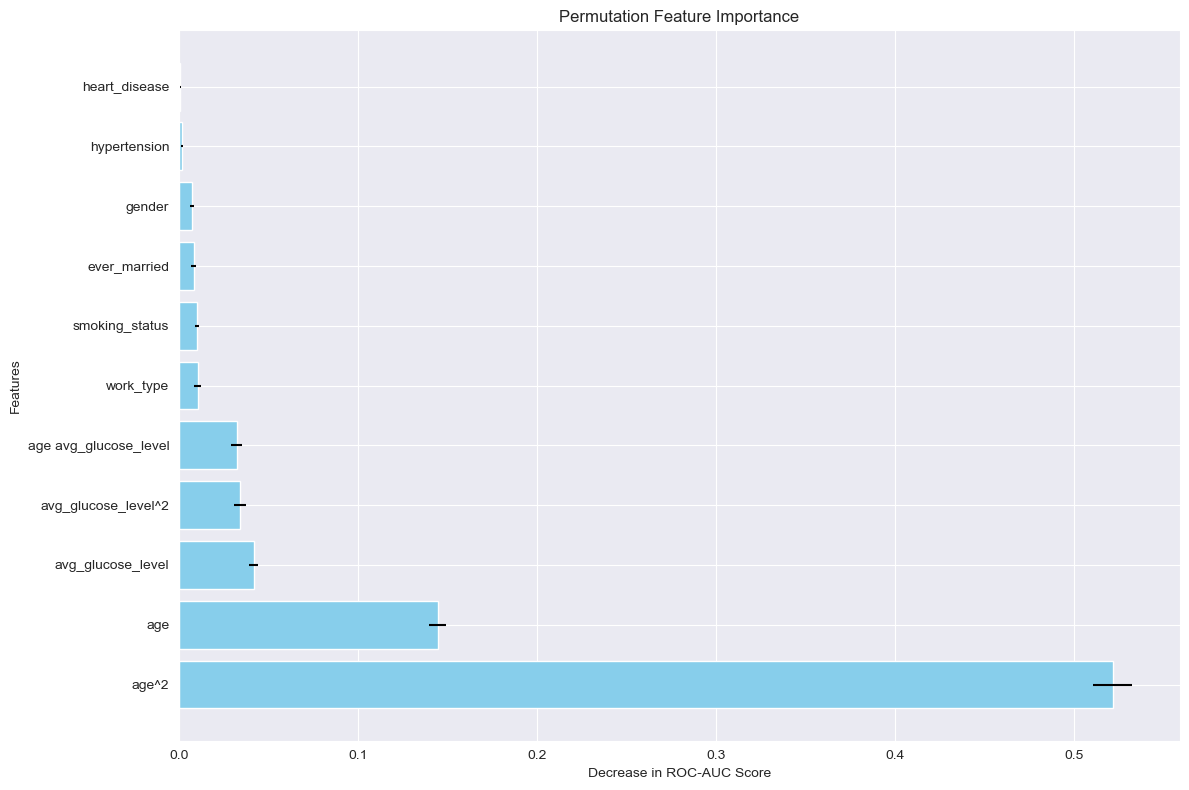

In [935]:
# Visualize the results
plt.figure(figsize=(12, 8))
plt.barh(
    y=np.arange(len(perm_importance_df)),  # Position on y-axis
    width=perm_importance_df['Importance'],  # Bar width (importance)
    xerr=perm_importance_df['Std_Dev'],  # Error bars
    align='center',
    color='skyblue',
    ecolor='black'
)
plt.yticks(np.arange(len(perm_importance_df)), perm_importance_df['Feature'])
plt.xlabel('Decrease in ROC-AUC Score')
plt.ylabel('Features')
plt.title('Permutation Feature Importance')

plt.tight_layout()
plt.savefig('permutation_importance.svg')
plt.show()



 ### <span style=' color:red'>LIME</span>

D:\ANACONDA\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


<Figure size 1000x600 with 0 Axes>

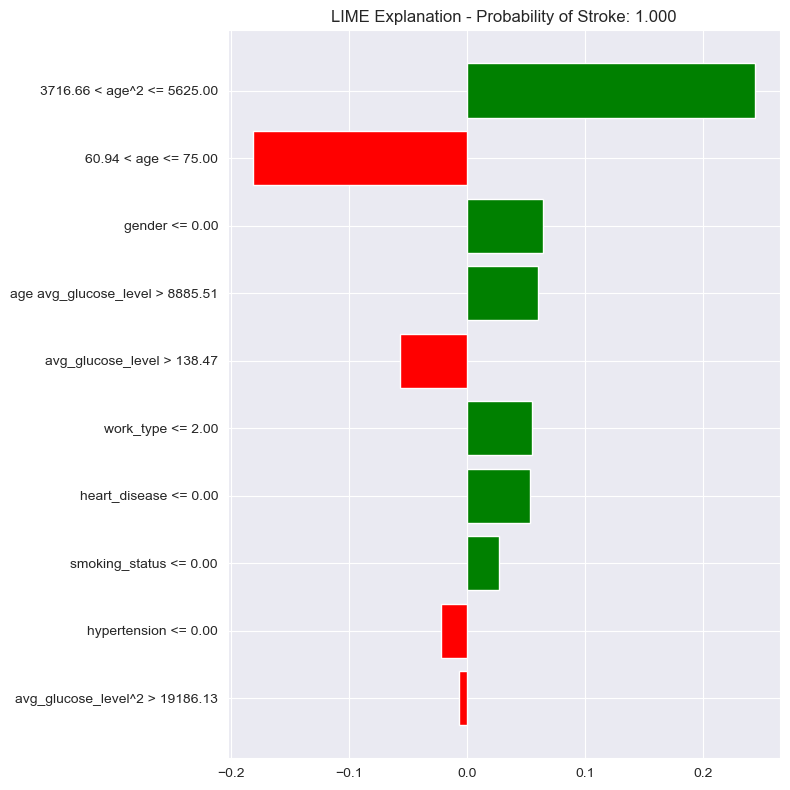

LIME Explanation for case with actual value: 1
Predicted probability of stroke: 1.000

Features contributing to this prediction:
  3716.66 < age^2 <= 5625.00: 0.2443
  60.94 < age <= 75.00: -0.1819
  gender <= 0.00: 0.0648
  age avg_glucose_level > 8885.51: 0.0604
  avg_glucose_level > 138.47: -0.0568
  work_type <= 2.00: 0.0554
  heart_disease <= 0.00: 0.0533
  smoking_status <= 0.00: 0.0271
  hypertension <= 0.00: -0.0220
  avg_glucose_level^2 > 19186.13: -0.0065


In [939]:


# Create the LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Stroke', 'Stroke'],
    mode='classification',
    random_state=42
)

# Choose a single example to explain (let's pick one with a positive prediction)

y_proba = best_gb.predict_proba(X_test)[:, 1]
positive_idx = np.where((y_test == 1) & (y_proba > 0.7))[0]
if len(positive_idx) > 0:
    idx_to_explain = positive_idx[0]
else:
    # If no confident positive examples, pick the highest probability one
    idx_to_explain = np.argmax(y_proba)

# Generate the explanation
exp = lime_explainer.explain_instance(
    X_test.iloc[idx_to_explain].values,
    best_gb.predict_proba,
    num_features=10
)

# Show the explanation as a plot
plt.figure(figsize=(10, 6))
exp.as_pyplot_figure()
plt.title(f"LIME Explanation - Probability of Stroke: {y_proba[idx_to_explain]:.3f}")
plt.tight_layout()
plt.savefig('lime_explanation.png')
plt.show()

# Print the textual explanation
print(f"LIME Explanation for case with actual value: {y_test.iloc[idx_to_explain]}")
print(f"Predicted probability of stroke: {y_proba[idx_to_explain]:.3f}")
print("\nFeatures contributing to this prediction:")
for feature, weight in exp.as_list():
    print(f"  {feature}: {weight:.4f}")

In [941]:
exp.show_in_notebook()

NEXT: 
1.Visuals to text interpretaion for doctors
2.RL for stroke management and prevention tips
3. UIX

                                   

D:\ANACONDA\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


<Figure size 1000x600 with 0 Axes>

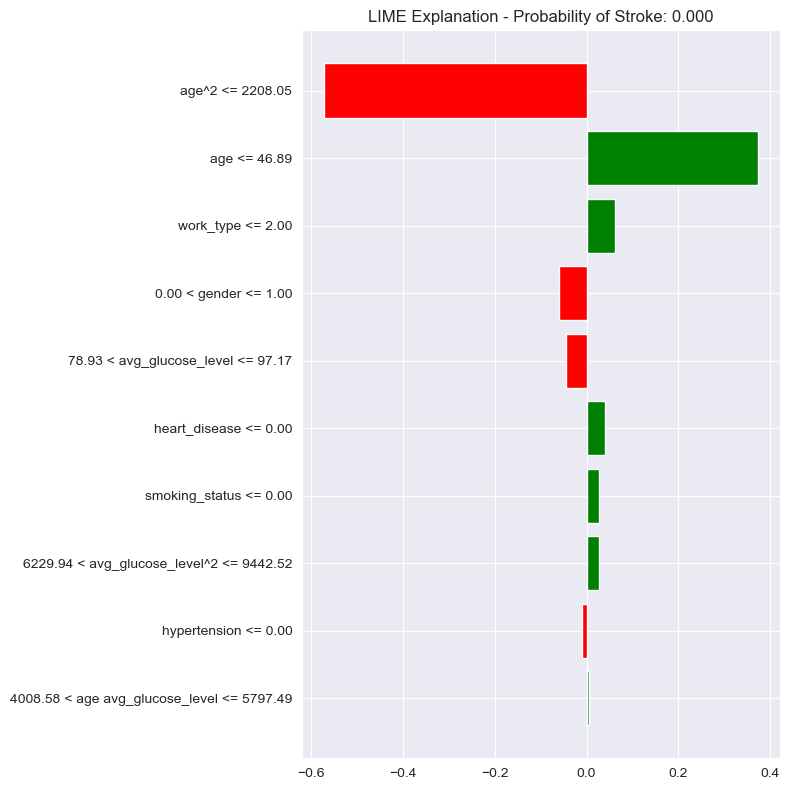

LIME Explanation for case with actual value: 0
Predicted probability of stroke: 0.000

Features contributing to this prediction:
  age^2 <= 2208.05: -0.5724
  age <= 46.89: 0.3743
  work_type <= 2.00: 0.0620
  0.00 < gender <= 1.00: -0.0607
  78.93 < avg_glucose_level <= 97.17: -0.0446
  heart_disease <= 0.00: 0.0407
  smoking_status <= 0.00: 0.0266
  6229.94 < avg_glucose_level^2 <= 9442.52: 0.0263
  hypertension <= 0.00: -0.0100
  4008.58 < age avg_glucose_level <= 5797.49: 0.0058


In [943]:
# Create the LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Stroke', 'Stroke'],
    mode='classification',
    random_state=42
)

# Get predicted probabilities
y_proba = best_gb.predict_proba(X_test)[:, 1]


negative_idx = np.where((y_test == 0) & (y_proba < 0.3))[0]

if len(negative_idx) > 0:
    idx_to_explain = negative_idx[0]
else:
    # If no such example, pick the one with the lowest probability of stroke
    idx_to_explain = np.argmin(y_proba)




# Generate the explanation
exp = lime_explainer.explain_instance(
    X_test.iloc[idx_to_explain].values,
    best_gb.predict_proba,
    num_features=10
)

# Show the explanation as a plot
plt.figure(figsize=(10, 6))
exp.as_pyplot_figure()
plt.title(f"LIME Explanation - Probability of Stroke: {y_proba[idx_to_explain]:.3f}")
plt.tight_layout()
plt.savefig('lime_explanation.png')
plt.show()

# Print the textual explanation
print(f"LIME Explanation for case with actual value: {y_test.iloc[idx_to_explain]}")
print(f"Predicted probability of stroke: {y_proba[idx_to_explain]:.3f}")
print("\nFeatures contributing to this prediction:")
for feature, weight in exp.as_list():
    print(f"  {feature}: {weight:.4f}")


In [945]:
exp.show_in_notebook()

In [947]:
import pickle

# Save the best base model
filename = 'best_gb_model.pkl'
pickle.dump(best_gb, open(filename, 'wb'))

print(f"Model saved to {filename}")


Model saved to best_gb_model.pkl
